## Setup and Imports

In [2]:
%load_ext autoreload
%autoreload 2

import pickle as pkl
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import matplotlib.pyplot as plt
# set font to helvetica for the manuscript
import matplotlib as mpl
from matplotlib import pyplot
# use custom file with helvetica as default
import matplotlib.font_manager as fm
font_path = "/wynton/home/capra/ychen39/.local/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttf"
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'Helvetica'
from matplotlib import rcParams
rcParams['font.family'] = 'Helvetica'
import seaborn as sns
sns.set_theme(font='Helvetica')
import pyranges as pr
import os
import pybedtools
BEDTOOLSDIR = '/wynton/home/cbi/shared/software/CBI/bedtools2-2.31.1/bin'
pybedtools.helpers.set_bedtools_path(path=f'{BEDTOOLSDIR}')
import re
from upsetplot import UpSet, from_indicators, plot
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from collections import defaultdict
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu
import pickle

# change parent directory to use tools
os.chdir(Path.cwd().parent)
from introgression_tools import tools


## WYNTON
HOMEDIR='/wynton/home/capra/ychen39/'
# RAWBEDDIR='/wynton/group/capra/projects/introgression_methods/data'

## LOCAL
#HOMEDIR='/Users/yaenchen/Library/CloudStorage/Box-Box/wynton_backup/'

# renaming dict
rename_dict = {'argweaverd': 'ARGweaver-D', 'archaicseeker': 'ArchaicSeeker2', 'archie': 'ArchIE',
                                   'sprime': 'Sprime', 'sarge': 'SARGE', 'vernot_2016':'S*', 'sankararaman_2014': 'CRF14',
                                 'sankararaman_2016_1':'CRF16 (1)', 'sankararaman_2016_2':'CRF16 (2)', 'skov_2020':'hmmix20',
                                 'steinruecken_2018':'DICAL-ADMIX', 'vernot_2016_extendedLD': 'S* (extended LD)', 
                                 'vernot_2016_medianextendedLD': 'S* (median extended LD)', 'ibdmix24':'IBDMix', 'iasi_2024':'admixfrog', 'skov_2018':'hmmix18',
                                 'CRF16_1':'CRF16 (1)', 'CRF16_2':'CRF16 (2)', 'hmmix23_X':'hmmix23 (X)'} # added after reviews

rename_dict_dir = {'hubisz_2020': 'ARGweaver-D', 'yuan_2021': 'ArchaicSeeker2', 'durvasula_2019': 'ArchIE',
                                   'browning_2018_updated_filtering': 'Sprime', 'schaefer_2021': 'SARGE', 'vernot_2016':'S*', 'sankararaman_2014': 'CRF14',
                                 'sankararaman_2016_1':'CRF16 (1)', 'sankararaman_2016_2':'CRF16 (2)', 'skov_2020':'hmmix20',
                                 'steinruecken_2018':'DICAL-ADMIX', 'li_2024':'IBDMix', 'iasi_2024':'admixfrog', 'skov_2018':'hmmix18', 'skov_2023_X':'hmmix23 (X)'} # added after reviews

methods_dirs = ['yuan_2021', 'durvasula_2019', 'steinruecken_2018', 'skov_2020', 'schaefer_2021', 
                'hubisz_2020', 'browning_2018_updated_filtering', 'vernot_2016', 'sankararaman_2014', 'sankararaman_2016_1', 'sankararaman_2016_2',
                'li_2024', 'iasi_2024', 'skov_2018', 'skov_2023_X'] # added after reviews

coverage_dict = {'ArchaicSeeker2': 57.132940046221684,
 'ArchIE': 29.446900170900914,
 'DICAL-ADMIX': 37.39871540013432,
 'hmmix20': 32.86026995142938,
 'SARGE': 39.828983126022784,
 'ARGweaver-D': 5.066391930399892,
 'Sprime': 22.02837221134294,
 'S*': 50.0849954588206,
 'CRF14': 40.17533130557398,
 'CRF16 (1)': 55.689019592244094,
 'CRF16 (2)': 40.70395835901203,
 'IBDMix': 61.394433555065916,
 'admixfrog': 51.964340302063675,
 'hmmix18': 58.91628426891676} # computed below

 # conda env: jupyter

plt.rcParams["axes.grid"] = False

%matplotlib inline

## Version info

In [89]:
from importlib.metadata import version
version('matplotlib')

'3.9.2'

In [8]:
import sys
print(sys.version)


3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]


In [30]:
import matplotlib.font_manager as fm
print([f.name for f in fm.fontManager.ttflist if "Helvetica" in f.name])

['Helvetica', 'Helvetica', 'Helvetica']


This is the final document for figure generation!

All main results will be focused on autosomes, with X chromosome analysis presented separately (in the Supplement)

## Basic descriptive stats:

#### Calculate coverage

In [ ]:
# get bed file of the hg19 genome
!awk 'BEGIN {OFS="\t"} {print $1, "0", $2}' {HOMEDIR}/introgression_methods/data/sorted_hg19.fa.fai > {HOMEDIR}/introgression_methods/data/human_hg19.bed
# subtract gaps
!{BEDTOOLSDIR}/bedtools subtract -a {HOMEDIR}/introgression_methods/data/human_hg19.bed -b {HOMEDIR}/introgression_methods/data/hg19_gaps.txt > /wynton/home/capra/ychen39/introgression_methods/data/human_hg19_gaps_removed.bed

In [147]:
# coverage of the genome
hg19_no_gaps=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr.bed', sep='\t', names=['chrom', 'start', 'end'])
hg19_no_gaps = hg19_no_gaps[hg19_no_gaps['chrom'].isin([f'chr{i}' for i in range(1,22)])]
hg19_no_gaps['length']=hg19_no_gaps.end-hg19_no_gaps.start
genome_length=np.sum(hg19_no_gaps.length)

boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
boolean_overlap = boolean_overlap[boolean_overlap['chrom'].isin([f'{i}' for i in range(1,22)])]
print(boolean_overlap.length.sum(), " bases", boolean_overlap.length.sum()/genome_length*100, "%")

2240223121  bases 84.54680609877454 %


In [150]:
# compute coverage across methods
coverage_dict = {} # empty dictionary to hold values

# how much of the genome is covered by the filtered regions?
#except skov_2023_X
for method in methods_dirs:
    if method=='skov_2023_X':
        continue
    print(method)
    df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', sep='\t', names=['chrom', 'start', 'end', 'score'])
    df['length']=df.end-df.start
    coverage = tools.bed_overall_proportion(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', 
                       f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes.bed',
                       f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/introgression_coverage.bed',
                       autosomes=True)# add length data
    method_name = rename_dict_dir[f'{method}']
    # add lengths to a dictionary
    coverage_dict[method_name]=coverage*100

coverage_dict

yuan_2021
durvasula_2019
steinruecken_2018
skov_2020
schaefer_2021
hubisz_2020
browning_2018_updated_filtering
vernot_2016
sankararaman_2014
sankararaman_2016_1
sankararaman_2016_2
li_2024
iasi_2024
skov_2018


{'ArchaicSeeker2': 57.132940046221684,
 'ArchIE': 29.446900170900914,
 'DICAL-ADMIX': 37.39871540013432,
 'hmmix20': 32.86026995142938,
 'SARGE': 39.828983126022784,
 'ARGweaver-D': 5.066391930399892,
 'Sprime': 22.02837221134294,
 'S*': 50.0849954588206,
 'CRF14': 40.17533130557398,
 'CRF16 (1)': 55.689019592244094,
 'CRF16 (2)': 40.70395835901203,
 'IBDMix': 61.394433555065916,
 'admixfrog': 51.964340302063675,
 'hmmix18': 58.91628426891676}

In [149]:
coverage_dict

{'ArchaicSeeker2': 57.132940046221684,
 'ArchIE': 29.446900170900914,
 'DICAL-ADMIX': 37.39871540013432,
 'hmmix20': 32.86026995142938,
 'SARGE': 39.828983126022784,
 'ARGweaver-D': 5.066391930399892,
 'Sprime': 22.02837221134294,
 'S*': 50.0849954588206,
 'CRF14': 40.17533130557398,
 'CRF16 (1)': 55.689019592244094,
 'CRF16 (2)': 40.70395835901203,
 'IBDMix': 61.394433555065916,
 'admixfrog': 51.964340302063675,
 'hmmix18': 58.91628426891676}

### X chromosome depletion: % of introgression in X chr vs. autosomes per method (with X introgression inference)

In [114]:
# compute coverage across methods for x and autosomes
x_introgression = {} 
autosome_introgression = {}

# get x and autosomes denominator (base pairs)
hg19_no_gaps=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed.bed', sep='\t', names=['chrom', 'start', 'end'])
hg19_no_gaps = hg19_no_gaps[hg19_no_gaps['chrom'].isin([f'chr{i}' for i in range(1,22)] + ['chrX'])]
hg19_no_gaps['length']=hg19_no_gaps.end-hg19_no_gaps.start
x_length = np.sum(hg19_no_gaps[hg19_no_gaps['chrom']=='chrX'].length)
auto_length = np.sum(hg19_no_gaps[hg19_no_gaps['chrom']!='chrX'].length)

for method in methods_dirs:
    df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', sep='\t', names=['chrom', 'start', 'end', 'score'])
    df['length']=df.end-df.start
    # subset df
    if 'chrX' in df['chrom'].unique():
        x_only = df[df['chrom']=='chrX']
        auto_only = df[df['chrom']!='chrX']
        # compute bps in each
        x_coverage = np.sum(x_only.length)
        auto_coverage = np.sum(auto_only.length)
        # rename method
        method_name = rename_dict_dir[f'{method}']
        # add lengths to a dictionary
        x_introgression[method_name]=x_coverage / x_length
        autosome_introgression[method_name]=auto_coverage / auto_length

# get overall coverage in X chromosome
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
# drop argweaverd
boolean_overlap = boolean_overlap.drop(columns=['argweaverd'])
boolean_overlap = boolean_overlap[boolean_overlap['chrom'].isin(['X'])]
print(boolean_overlap.length.sum(), " bases", boolean_overlap.length.sum()/x_length*100, "%")

43686164  bases 28.91198020708858 %


In [113]:
# drop columns with all false
boolean_overlap.loc[:, (boolean_overlap != 0).any(axis=0)]

,chrom,start,end,argweaverd,sankararaman_2014,sankararaman_2016_1,sankararaman_2016_2,hmmix20,steinruecken_2018,hmmix23_X,length
443146,X,2326851,2773521,False,False,True,True,False,False,False,446670
443147,X,2773521,2784585,False,False,True,False,False,False,False,11064
443148,X,2784585,2785417,False,False,True,False,False,False,False,832
443149,X,2785417,2785428,False,False,True,False,False,False,False,11
443150,X,2785428,2788480,False,False,True,False,False,False,False,3052
...,...,...,...,...,...,...,...,...,...,...,...
445196,X,151253000,151269450,False,False,True,False,False,False,False,16450
445197,X,151303393,151378761,False,False,True,False,False,False,False,75368
445198,X,151378761,151416268,False,False,True,False,False,False,False,37507
445199,X,151416268,151419334,False,False,True,False,False,False,False,3066


In [115]:
x_introgression

{'DICAL-ADMIX': 0.11701809708713191,
 'hmmix20': 0.051714341760215846,
 'ARGweaver-D': 0.007543128893764524,
 'CRF14': 0.10934429362803155,
 'CRF16 (1)': 0.22492411676038793,
 'CRF16 (2)': 0.15068804510056086,
 'hmmix23 (X)': 0.17920515979556925}

In [116]:
autosome_introgression


{'DICAL-ADMIX': 0.3795386667392509,
 'hmmix20': 0.3325845657830415,
 'ARGweaver-D': 0.05114866844453357,
 'CRF14': 0.4155247168096745,
 'CRF16 (1)': 0.5751753105144148,
 'CRF16 (2)': 0.4223277539209154,
 'hmmix23 (X)': 0.0}

## Lengths distribution across methods

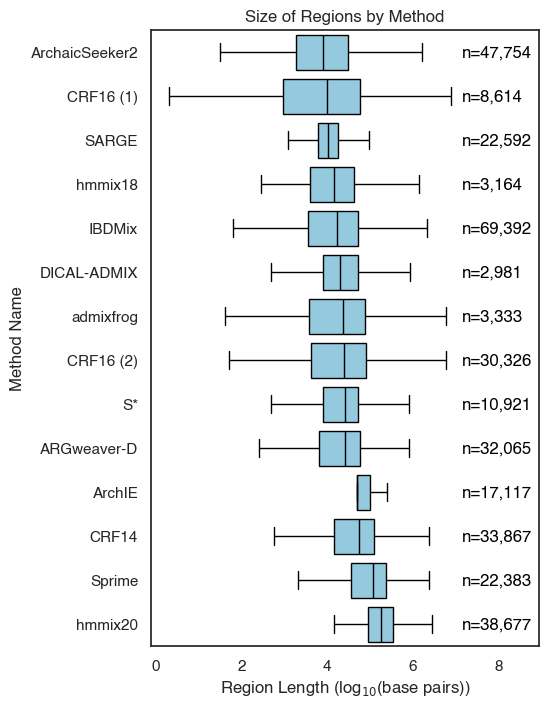

In [ ]:
# create box plot, first make dictionary with method name and lengths across the genome of introgression deserts 
lengths_dict = {}
num_regions_dict = {}

# use Helvetica in Seaborn
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14})

for method in methods_dirs:
    # get corresponding method name
    method_name = rename_dict_dir[method]
    df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', sep='\t', names=['chrom', 'start', 'end'])
    # remove X chrom
    df = df[~df['chrom'].isin(['chrX'])]
    # add length data
    df['length'] = df['end'] - df['start']
    # add lengths to a dictionary
    lengths_dict[f'{method_name}']=np.log10(df['length'])
    num_regions_dict[f'{method_name}']=len(df)

flattened_data = [(key, value) for key, values in lengths_dict.items() for value in values]
lengths_df = pd.DataFrame(flattened_data)
lengths_df.rename(columns={0:'Method Name', 1:'Log10Length'}, inplace=True)
median_order = lengths_df.groupby('Method Name')['Log10Length'].median().sort_values(ascending=True).index
# box plot
plt.figure(figsize=(5,8))
plt.rcParams['font.size'] = 14
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14,'figure.figsize':(6,8)})
sns.boxplot(data=lengths_df, x='Log10Length', 
               y='Method Name', 
               showfliers=False, 
               color='skyblue', 
               boxprops=dict(edgecolor='black'), 
               whiskerprops=dict(color='black'), 
               capprops=dict(color='black'), 
               medianprops=dict(color='black'), 
               order=median_order)

plt.title('Size of Regions by Method')
plt.xlabel(r'Region Length (log$_{10}$(base pairs))')

# Overlay a strip plot with jitter - took this out per Tony's comments
# sns.stripplot(data=lengths_df, x='Log10Length', y='Method Name', jitter=True, color='grey', size=2)

# Add text annotations for the number of regions
for i, method in enumerate(lengths_df['Method Name'].unique()):
    num_regions = num_regions_dict[method]
    plt.text(lengths_df['Log10Length'].max() + 0.2, i, f"n={num_regions:,}", 
             ha='left', va='center', fontsize=12, color='black')

# Adjust plot limits
plt.xlim(left=lengths_df['Log10Length'].min() - 0.1, right=lengths_df['Log10Length'].max() + 2)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/FigBPCountsB.svg', bbox_inches='tight')  

plt.show()

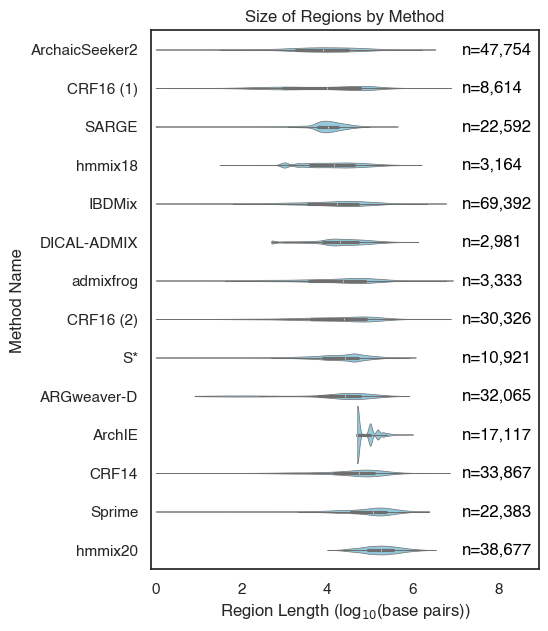

In [121]:
# create violin plot, first make dictionary with method name and lengths across the genome of introgression deserts 
lengths_dict = {}
num_regions_dict = {}

# use Helvetica in Seaborn
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14})

for method in methods_dirs:
    # get corresponding method name
    method_name = rename_dict_dir[method]
    df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', sep='\t', names=['chrom', 'start', 'end'])
    # add length data
    df['length'] = df['end'] - df['start']
    # remove X chrom
    df = df[~df['chrom'].isin(['chrX'])]
    # add lengths to a dictionary
    lengths_dict[f'{method_name}']=np.log10(df['length'])
    num_regions_dict[f'{method_name}']=len(df)

flattened_data = [(key, value) for key, values in lengths_dict.items() for value in values]
lengths_df = pd.DataFrame(flattened_data)
lengths_df.rename(columns={0:'Method Name', 1:'Log10Length'}, inplace=True)
median_order = lengths_df.groupby('Method Name')['Log10Length'].median().sort_values(ascending=True).index
# box plot
plt.figure(figsize=(5,7))
plt.rcParams['font.size'] = 14
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14,'figure.figsize':(6,8)})
sns.violinplot(
    data=lengths_df,
    x='Log10Length',
    y='Method Name',
    order=median_order,
    color='skyblue',
    linewidth=0.5,
    width=1.5,
    cut=0               # prevent extending beyond data range
)
plt.title('Size of Regions by Method')
plt.xlabel(r'Region Length (log$_{10}$(base pairs))')

# Overlay a strip plot with jitter - took this out per Tony's comments
# sns.stripplot(data=lengths_df, x='Log10Length', y='Method Name', jitter=True, color='grey', size=2)

# Add text annotations for the number of regions
for i, method in enumerate(lengths_df['Method Name'].unique()):
    num_regions = num_regions_dict[method]
    plt.text(lengths_df['Log10Length'].max() + 0.2, i, f"n={num_regions:,}", 
             ha='left', va='center', fontsize=12, color='black')

# Adjust plot limits
plt.xlim(left=lengths_df['Log10Length'].min() - 0.1, right=lengths_df['Log10Length'].max() + 2)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/FigBPCountsViolin.svg', bbox_inches='tight')  

plt.show()

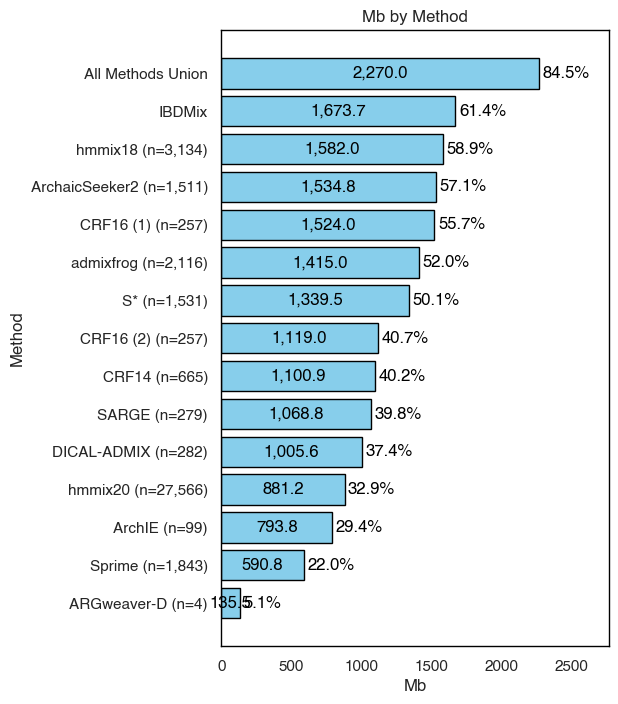

In [152]:
# overlap file with all 12 methods
overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/all_methods.bed', sep='\t', low_memory=False)

overlap = overlap.rename(columns=rename_dict)
overlap.drop(columns=['hmmix23_X'], inplace=True)

overlap = overlap[~overlap['chrom'].isin(['X'])]

bp_count = overlap.drop(['chrom', 'start', 'end', 'length'], axis=1)

for column in bp_count.columns:
    bp_count.loc[bp_count[column].notnull(), column] = overlap['length']

bp_count_sum = pd.DataFrame(bp_count.sum()).reset_index()
bp_count_sum.columns=['Algorithm', 'Base Pairs']

bps_dict = pd.Series(bp_count_sum['Base Pairs'].values, index=bp_count_sum['Algorithm']).to_dict()

# manually add union of all methods
bps_dict['All Methods Union'] = overlap.length.sum()
coverage_dict['All Methods Union'] = 84.54680609877454

# sort keys by descending value
sorted_keys = sorted(bps_dict, key=lambda k: bps_dict[k])
# get the bp counts (divided by 1 million, coverages, and num regions
bp_counts = [bps_dict[k]/1000000 for k in sorted_keys]
coverage_percentages = [coverage_dict[k] for k in sorted_keys]

# add method names and the # people the maps are based on
rename_dict_dir_n = {'ARGweaver-D': 'ARGweaver-D (n=4)', 'ArchaicSeeker2': 'ArchaicSeeker2 (n=1,511)', 'ArchIE': 'ArchIE (n=99)',
                                   'Sprime': 'Sprime (n=1,843)', 'SARGE': 'SARGE (n=279)', 'S*':'S* (n=1,531)', 
                                   'CRF14': 'CRF14 (n=665)',
                                 'CRF16 (1)':'CRF16 (1) (n=257)', 'CRF16 (2)':'CRF16 (2) (n=257)', 'Skov20':'Skov20 (n=27,566)',
                                 'DICAL-ADMIX':'DICAL-ADMIX (n=282)', 'IBDMix24':'IBDMix24 (n=2,504)', 'admixfrog':'admixfrog (n=2,116)', 'hmmix18':'hmmix18 (n=3,134)', 'hmmix20':'hmmix20 (n=27,566)'}

sorted_keys = [rename_dict_dir_n.get(item, item) for item in sorted_keys]

# bar plot
fig, ax = plt.subplots(figsize=(5, 8))
plt.rcParams['font.size'] = 14
bars = ax.barh(sorted_keys, bp_counts, color="skyblue", edgecolor="black")

# put millions of base pair counts inside bars
for bar, inside in zip(bars, bp_counts):
    # except argweaverd since it's too small, move that one out of the bar with line pointing to it

    ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, f"{inside:,.1f}",
            ha='center', va='center', fontsize=12, color="black")

# put coverage percentages outside bars
for bar, outside in zip(bars, coverage_percentages):
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height()/2, f"{outside:.1f}%",
            ha='left', va='center', fontsize=12, color="black")
    
plt.title('Mb by Method')
plt.ylabel('Method')
plt.xlabel('Mb')
# Adjust plot limits
plt.xlim(0, right=np.max(bp_counts) + 500)

# remove background
plt.gca().set_facecolor("none") 
plt.gcf().patch.set_facecolor("none")

# add borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/Fig1A.svg', bbox_inches='tight')  

plt.show()



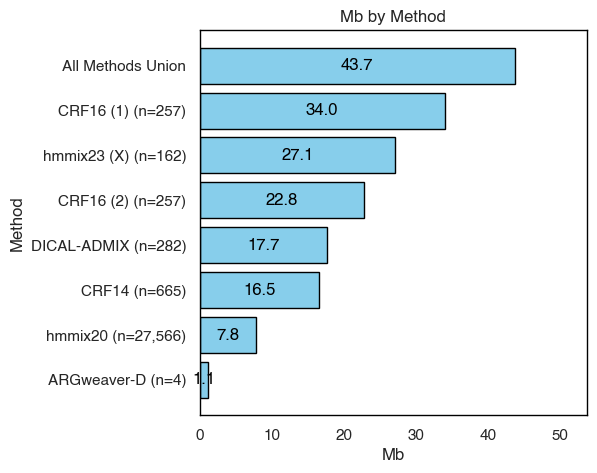

In [ ]:
# overlap file with all 12 methods
overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/all_methods.bed', sep='\t', low_memory=False)

overlap = overlap.rename(columns=rename_dict)

overlap = overlap[overlap['chrom'].isin(['X'])]

bp_count = overlap.drop(['chrom', 'start', 'end', 'length'], axis=1)

# drop bp count where column is all NaN
bp_count = bp_count.loc[:, bp_count.notnull().any(axis=0)]

for column in bp_count.columns:
    bp_count.loc[bp_count[column].notnull(), column] = overlap['length']

bp_count_sum = pd.DataFrame(bp_count.sum()).reset_index()
bp_count_sum.columns=['Algorithm', 'Base Pairs']

bps_dict = pd.Series(bp_count_sum['Base Pairs'].values, index=bp_count_sum['Algorithm']).to_dict()

# manually add union of all methods
bps_dict['All Methods Union'] = overlap.length.sum()
coverage_dict['All Methods Union'] = 80.64083315461824

# sort keys by descending value
sorted_keys = sorted(bps_dict, key=lambda k: bps_dict[k])
# get the bp counts (divided by 1 million, coverages, and num regions
bp_counts = [bps_dict[k]/1000000 for k in sorted_keys]

# add method names and the # people the maps are based on
rename_dict_dir_n = {'ARGweaver-D': 'ARGweaver-D (n=4)', 'ArchaicSeeker2': 'ArchaicSeeker2 (n=1,511)', 'ArchIE': 'ArchIE (n=99)',
                                   'Sprime': 'Sprime (n=1,843)', 'SARGE': 'SARGE (n=279)', 'S*':'S* (n=1,531)', 
                                   'CRF14': 'CRF14 (n=665)',
                                 'CRF16 (1)':'CRF16 (1) (n=257)', 'CRF16 (2)':'CRF16 (2) (n=257)', 'Skov20':'Skov20 (n=27,566)',
                                 'DICAL-ADMIX':'DICAL-ADMIX (n=282)', 'IBDMix24':'IBDMix24 (n=2,504)', 'admixfrog':'admixfrog (n=2,116)', 
                                 'hmmix18':'hmmix18 (n=3,134)', 'hmmix20':'hmmix20 (n=27,566)', 'hmmix23_X':'hmmix23 (X) (n=162)'}

sorted_keys = [rename_dict_dir_n.get(item, item) for item in sorted_keys]

# bar plot
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 14
bars = ax.barh(sorted_keys, bp_counts, color="skyblue", edgecolor="black")

# put millions of base pair counts inside bars
for bar, inside in zip(bars, bp_counts):
    # except argweaverd since it's too small, move that one out of the bar with line pointing to it

    ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, f"{inside:,.1f}",
            ha='center', va='center', fontsize=12, color="black")
    
plt.title('Mb by Method')
plt.ylabel('Method')
plt.xlabel('Mb')
# Adjust plot limits
plt.xlim(0, right=np.max(bp_counts) + 10)

# remove background
plt.gca().set_facecolor("none") 
plt.gcf().patch.set_facecolor("none")

# add borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/Fig1A_X.svg', bbox_inches='tight')  

plt.show()



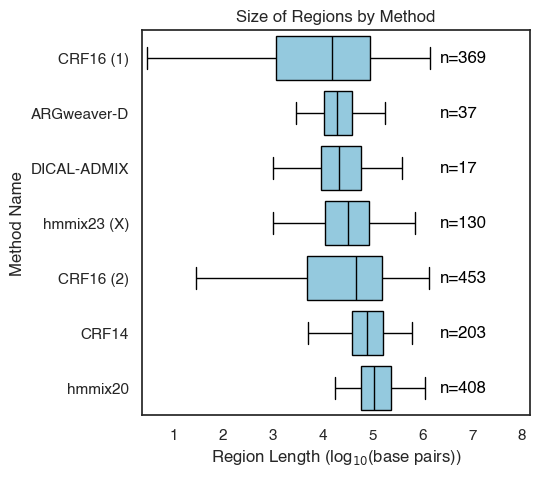

In [154]:
# create box plot, first make dictionary with method name and lengths across the genome of introgression deserts 
lengths_dict = {}
num_regions_dict = {}

# use Helvetica in Seaborn
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14})

for method in methods_dirs:
    # get corresponding method name
    method_name = rename_dict_dir[method]
    df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged_chr_prefix.bg', sep='\t', names=['chrom', 'start', 'end'])
    # remove X chrom
    df = df[df['chrom'].isin(['chrX'])]
    # add length data
    df['length'] = df['end'] - df['start']
    # add lengths to a dictionary
    lengths_dict[f'{method_name}']=np.log10(df['length'])
    num_regions_dict[f'{method_name}']=len(df)

flattened_data = [(key, value) for key, values in lengths_dict.items() for value in values]
lengths_df = pd.DataFrame(flattened_data)
lengths_df.rename(columns={0:'Method Name', 1:'Log10Length'}, inplace=True)
median_order = lengths_df.groupby('Method Name')['Log10Length'].median().sort_values(ascending=True).index
# box plot
plt.figure(figsize=(5,5))
plt.rcParams['font.size'] = 14
sns.set_theme(style="white", rc={"font.family": "Helvetica", "font.size": 14,'figure.figsize':(6,8)})
sns.boxplot(data=lengths_df, x='Log10Length', 
               y='Method Name', 
               showfliers=False, 
               color='skyblue', 
               boxprops=dict(edgecolor='black'), 
               whiskerprops=dict(color='black'), 
               capprops=dict(color='black'), 
               medianprops=dict(color='black'), 
               order=median_order)

plt.title('Size of Regions by Method')
plt.xlabel(r'Region Length (log$_{10}$(base pairs))')

# Overlay a strip plot with jitter - took this out per Tony's comments
# sns.stripplot(data=lengths_df, x='Log10Length', y='Method Name', jitter=True, color='grey', size=2)

# Add text annotations for the number of regions
for i, method in enumerate(lengths_df['Method Name'].unique()):
    num_regions = num_regions_dict[method]
    plt.text(lengths_df['Log10Length'].max() + 0.2, i, f"n={num_regions:,}", 
             ha='left', va='center', fontsize=12, color='black')

# Adjust plot limits
plt.xlim(left=lengths_df['Log10Length'].min() - 0.1, right=lengths_df['Log10Length'].max() + 2)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/FigBPCountsB_X.svg', bbox_inches='tight')  

plt.show()

## Unique BP (per method, upset plot)

### Unique BP per method - Whole Maps

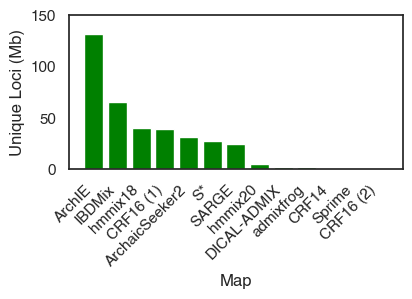

% num unique base pairs/total number of introgressed base pairs 16.37307535891937


In [160]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaver = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver.bed', sep='\t', low_memory=False)
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.rename(columns=rename_dict)
# drop hmmix23_X
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.drop(columns=['hmmix23_X'])

# drop x chrom 
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver[~boolean_overlap_no_argweaver['chrom'].isin(['X'])]

# bar plot of unique values
# List to store the sum of lengths
length_sums = []

# List of columns except 'length'

to_remove = ['chrom', 'start', 'end', 'length']
columns = list(boolean_overlap_no_argweaver.columns)
columns=[name for name in columns if name not in to_remove]

total_sums = 0

for col in columns:
    # Create a filter for the current column being True and all others False
    filter_condition = (boolean_overlap_no_argweaver[col] == True)
    for other_col in columns:
        if other_col != col:
            filter_condition &= (boolean_overlap_no_argweaver[other_col] == False)
    
    # Sum the 'length' column where the condition is met
    length_sum = boolean_overlap_no_argweaver[filter_condition]['length'].sum()/1000000
    # save the unique length values
    length_sums.append((col, length_sum))
    total_sums += boolean_overlap_no_argweaver[filter_condition]['length'].sum()

# Sort the sums in descending order
length_sums.sort(key=lambda x: x[1], reverse=True)

# Separate the sorted column names and their sums
sorted_columns, sorted_sums = zip(*length_sums)

# Create a bar plot
plt.figure(figsize=(4.3, 2))
plt.bar(sorted_columns, sorted_sums, color='green')
plt.ylim(0, 150)
plt.xlabel('Map')
plt.ylabel('Unique Loci (Mb)')
plt.xticks(rotation=45, ha='right')
#plt.subplots_adjust(bottom=0.15)
pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/unique_base_pairs_plot_no_argweaver.svg', bbox_inches='tight')  

plt.show()

# print % num unique base pairs/total number of introgressed base pairs
print('% num unique base pairs/total number of introgressed base pairs', total_sums/boolean_overlap_no_argweaver.length.sum()*100)

### Unique BP per method - Top 793.9 Mb

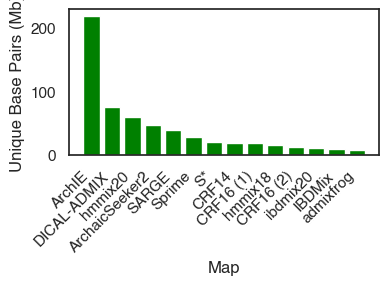

In [163]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_size_matched = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores.bed', sep='\t', low_memory=False)
# List of columns to exclude to make boolean
exclude_columns = ['chrom', 'start', 'end', 'length']
# drop x chrom 
boolean_overlap_size_matched = boolean_overlap_size_matched[~boolean_overlap_size_matched['chrom'].isin(['X'])]
# replace 0 as NA
boolean_overlap_size_matched.replace(0, np.nan, inplace=True)
# convert values to boolean values (true or false)
boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)] = boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)].apply(lambda x: pd.notna(x))
# calculate length
boolean_overlap_size_matched['length'] = boolean_overlap_size_matched['end'] - boolean_overlap_size_matched['start']
# rename algorithms
boolean_overlap_size_matched = boolean_overlap_size_matched.rename(columns=rename_dict)

# bar plot of unique values
# List to store the sum of lengths
length_sums = []

# List of columns except 'length'
to_remove = ['chrom', 'start', 'end', 'length']
columns = list(boolean_overlap_size_matched.columns)
columns=[name for name in columns if name not in to_remove]

total_sums = 0

for col in columns:
    # Create a filter for the current column being True and all others False
    filter_condition = (boolean_overlap_size_matched[col] == True)
    for other_col in columns:
        if other_col != col:
            filter_condition &= (boolean_overlap_size_matched[other_col] == False)
    
    # Sum the 'length' column where the condition is met
    length_sum = boolean_overlap_size_matched[filter_condition]['length'].sum()/1000000
    # save the unique length values
    length_sums.append((col, length_sum))
    total_sums += boolean_overlap_size_matched[filter_condition]['length'].sum()

# Sort the sums in descending order
length_sums.sort(key=lambda x: x[1], reverse=True)

# Separate the sorted column names and their sums
sorted_columns, sorted_sums = zip(*length_sums)

# Create a bar plot
plt.figure(figsize=(4,2))
plt.bar(sorted_columns, sorted_sums, color='green')
plt.xlabel('Map')
plt.ylabel('Unique Base Pairs (Mb)')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.15)
plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/unique_base_pairs_sizematched.svg', bbox_inches='tight')  

plt.show()

### Upset Plot -- Whole Maps

<Figure size 1800x100 with 0 Axes>

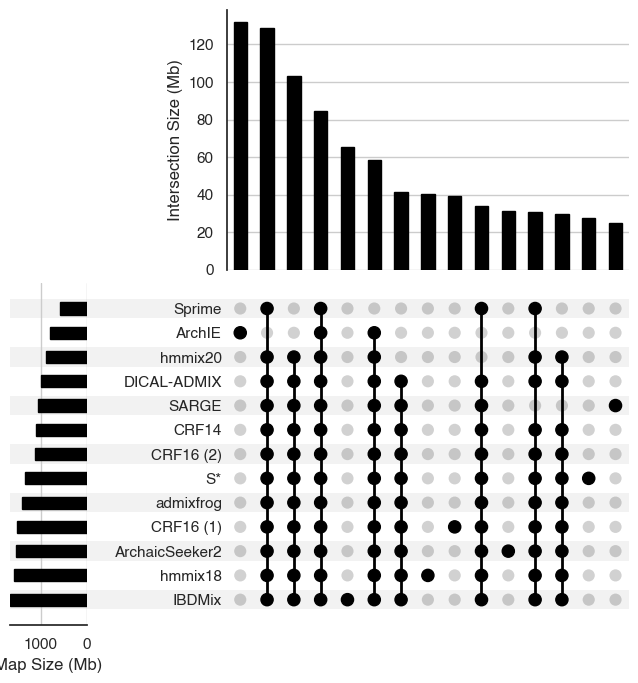

In [192]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaver = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver.bed', sep='\t', low_memory=False)
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.rename(columns=rename_dict)
# drop X chrom and hmmix23_X
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver[~boolean_overlap_no_argweaver['chrom'].isin(['X'])]
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.drop(columns=['hmmix23_X'])
# add length in Mb column
boolean_overlap_no_argweaver['mb_length'] = boolean_overlap_no_argweaver['length']/1000000

plt.figure(figsize=(18, 1))

upset_plot = plot(from_indicators(['IBDMix', 'ArchaicSeeker2', 'ArchIE', 'Sprime', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX'], data=boolean_overlap_no_argweaver), sort_by='cardinality', sum_over="mb_length", subset_size="sum",
                    min_subset_size=23, totals_plot_elements=3, intersection_plot_elements=10, element_size = 25)
                    # min_subset_size: at least 12 Mb in the intersection size
                    # total_plot_elements: make the set sizes bigger
                    # intersection_plot_elements: make intersection plot bigger
                    # element_size: change element size

upset_plot["intersections"].set_ylabel("Intersection Size (Mb)")
upset_plot["totals"].set_xlabel("Map Size (Mb)")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/upsetplot_bp_longerdim.svg')  

<Figure size 1800x100 with 0 Axes>

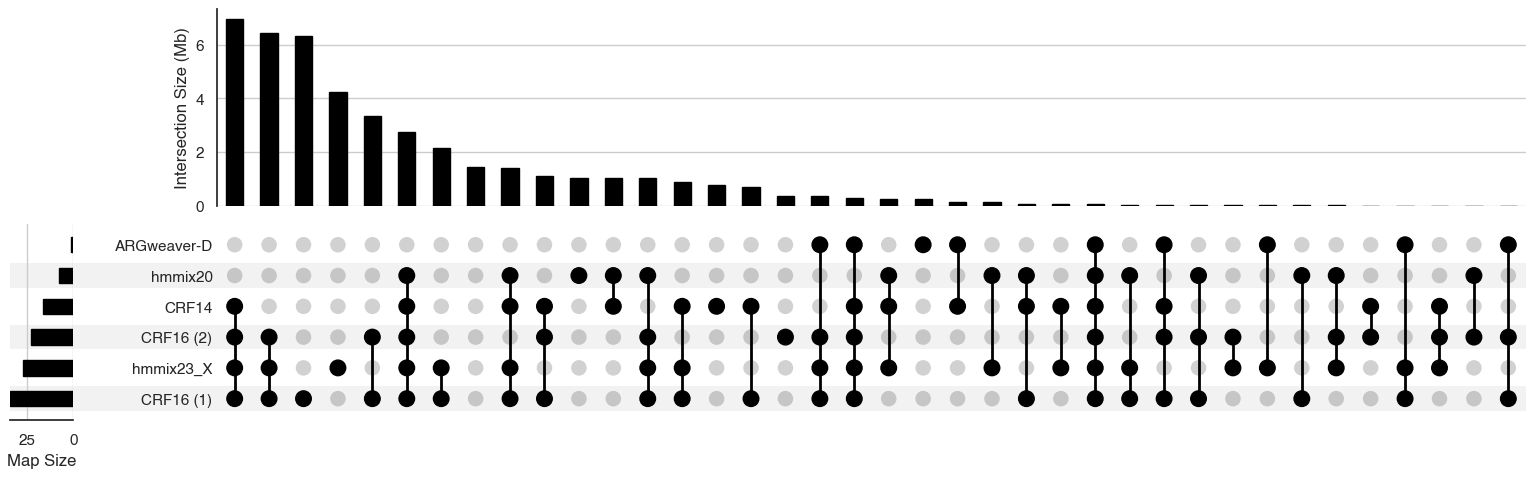

In [ ]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaver = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.rename(columns=rename_dict)
# drop X chrom and hmmix23_X
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver[boolean_overlap_no_argweaver['chrom'].isin(['X'])]
# add length in Mb column
boolean_overlap_no_argweaver['mb_length'] = boolean_overlap_no_argweaver['length']/1000000

plt.figure(figsize=(18, 1))

upset_plot = plot(from_indicators(['CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'ARGweaver-D',
                     'hmmix23_X'], data=boolean_overlap_no_argweaver), sort_by='cardinality', sum_over="mb_length", subset_size="sum")
                    # min_subset_size: at least 12 Mb in the intersection size
                    # total_plot_elements: make the set sizes bigger
                    # intersection_plot_elements: make intersection plot bigger
                    # element_size: change element size

upset_plot["intersections"].set_ylabel("Intersection Size (Mb)")
upset_plot["totals"].set_xlabel("Map Size (Mb)")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/upsetplot_bp_longerdim_X.svg') 

In [174]:
# Mb supported only by archie
archie_only = boolean_overlap_no_argweaver[(boolean_overlap_no_argweaver['ArchIE'] == True) &
                                            (boolean_overlap_no_argweaver[['IBDMix', 'ArchaicSeeker2', 'Sprime', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX']].sum(axis=1) == 0) & (boolean_overlap_no_argweaver['chrom'] != 'X')]
print("Mb supported only by ArchIE:", archie_only.length.sum()/1000000)

Mb supported only by ArchIE: 131.798731


In [175]:
# get Mb where all methods support except archIE
all_but_archie = boolean_overlap_no_argweaver[(boolean_overlap_no_argweaver['ArchIE'] == False) &
                                            (boolean_overlap_no_argweaver[['IBDMix', 'ArchaicSeeker2', 'Sprime', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX']].sum(axis=1) == 12) & (boolean_overlap_no_argweaver['chrom'] != 'X')]
print("Mb supported by all methods except ArchIE:", all_but_archie.length.sum()/1000000)

Mb supported by all methods except ArchIE: 128.972469


In [176]:
# get Mb where all methods support

all_methods = boolean_overlap_no_argweaver[(boolean_overlap_no_argweaver[['IBDMix', 'ArchaicSeeker2', 'ArchIE', 'Sprime', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX']].sum(axis=1) == 13) & (boolean_overlap_no_argweaver['chrom'] != 'X')]

print("Mb supported by all methods:", all_methods.length.sum()/1000000)

Mb supported by all methods: 84.760566


In [40]:
# get number of Mb where all methods support except archie and sprime

all_but_archie_sprime = boolean_overlap_no_argweaver[(boolean_overlap_no_argweaver['ArchIE'] == False) &
                                            (boolean_overlap_no_argweaver['Sprime'] == False) &
                                            (boolean_overlap_no_argweaver[['IBDMix', 'ArchaicSeeker2', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX']].sum(axis=1) == 11)]
print("Mb supported by all methods except ArchIE and Sprime:", all_but_archie_sprime.length.sum()/1000000)

Mb supported by all methods except ArchIE and Sprime: 103.238781


In [180]:
# get number of Mb where all methods except archie support
boolean_overlap_no_argweaver['methods_support_no_archie'] = boolean_overlap_no_argweaver[['IBDMix', 'ArchaicSeeker2', 'Sprime', 'S*', 
                     'CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'hmmix18', 'admixfrog',
                     'SARGE', 'DICAL-ADMIX']].sum(axis=1)
boolean_overlap_all_methods_no_archie = boolean_overlap_no_argweaver[boolean_overlap_no_argweaver['methods_support_no_archie'] == 12]  
# get Mb supported by all methods except archie
boolean_overlap_all_methods_no_archie.mb_length.sum()

213.733035

### Upset Plot -- top 793.9 Mb

Text(0.5, 0, 'Introgression Map Size')

<Figure size 2500x200 with 0 Axes>

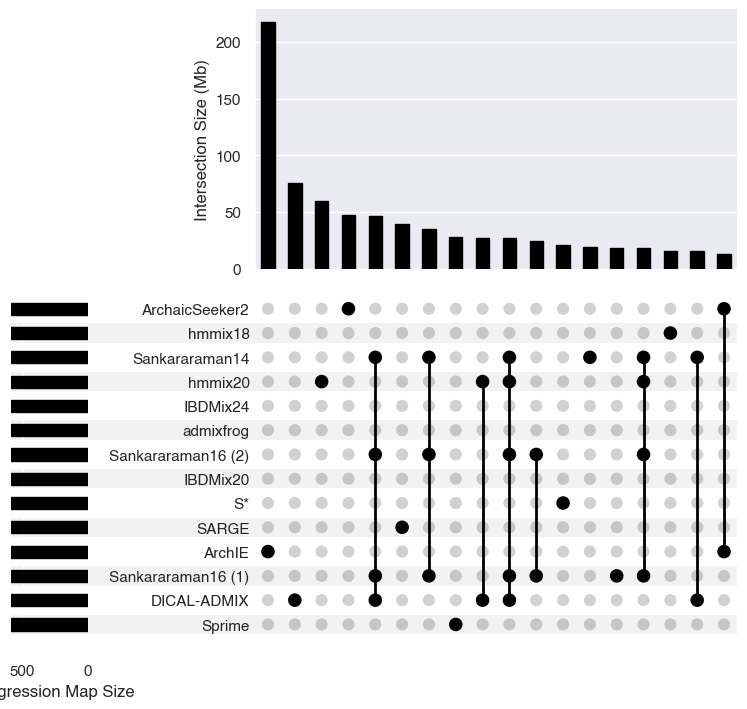

In [42]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_size_matched = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_updated.bed', sep='\t', low_memory=False)
# List of columns to exclude to make boolean
exclude_columns = ['chrom', 'start', 'end', 'length']
# replace 0 as NA
boolean_overlap_size_matched.replace(0, np.nan, inplace=True)
# convert values to boolean values (true or false)
boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)] = boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)].apply(lambda x: pd.notna(x))
# calculate length
boolean_overlap_size_matched['length'] = boolean_overlap_size_matched['end'] - boolean_overlap_size_matched['start']
# rename algorithms
boolean_overlap_size_matched = boolean_overlap_size_matched.rename(columns=rename_dict)

boolean_overlap_size_matched['mb_length'] = boolean_overlap_size_matched['length']/1000000

plt.figure(figsize=(25, 2))

upset_plot = plot(from_indicators(['IBDMix20', 'ArchaicSeeker2', 'ArchIE', 'Sprime', 'S*', 
                     'Sankararaman14', 'Sankararaman16 (1)', 'Sankararaman16 (2)', 'hmmix20', 'hmmix18', 'admixfrog', 'IBDMix24',
                     'SARGE', 'DICAL-ADMIX'], data=boolean_overlap_size_matched), sort_by='cardinality', sum_over="mb_length", subset_size="sum",
                    min_subset_size=13, totals_plot_elements=3, intersection_plot_elements=10, element_size = 25)
                    # min_subset_size: at least 13 Mb in the intersection size
                    # total_plot_elements: make the set sizes bigger
                    # intersection_plot_elements: make intersection plot bigger
                    # element_size: change element size

upset_plot["intersections"].set_ylabel("Intersection Size (Mb)")
upset_plot["totals"].set_xlabel("Introgression Map Size")


#pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/upsetplot_bp_sizematched.svg')  

### Num methods supporting each BP -- whole map

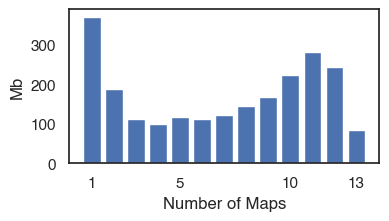

In [181]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaver = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver.bed', sep='\t', low_memory=False)
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver[~boolean_overlap_no_argweaver['chrom'].isin(['X'])]
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.rename(columns=rename_dict)

# Calculate the number of True values in each column
true_counts = boolean_overlap_no_argweaver.select_dtypes(include='bool').sum(axis=1)

# Group by the number of True values and sum the lengths
sum_lengths = boolean_overlap_no_argweaver.groupby(true_counts)['length'].sum()/1000000

# Plot the results
plt.figure(figsize=(4,2))
plt.bar(sum_lengths.index, sum_lengths.values)
plt.xlabel('Number of Maps')
plt.ylabel('Mb')
#plt.title('Number of Base Pairs Supported By Map Count')
plt.xticks([1,5,10,13])
plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/base_pairs_supported_by_num_algorithms_no_argweaver.svg', bbox_inches='tight')  
plt.show()

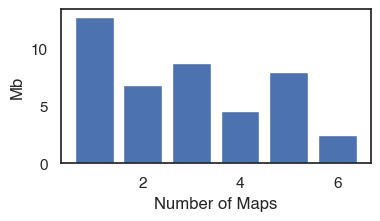

In [183]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaver = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver.bed', sep='\t', low_memory=False)
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver[boolean_overlap_no_argweaver['chrom'].isin(['X'])]
boolean_overlap_no_argweaver = boolean_overlap_no_argweaver.rename(columns=rename_dict)

# Calculate the number of True values in each column
true_counts = boolean_overlap_no_argweaver.select_dtypes(include='bool').sum(axis=1)

# Group by the number of True values and sum the lengths
sum_lengths = boolean_overlap_no_argweaver.groupby(true_counts)['length'].sum()/1000000

# Plot the results
plt.figure(figsize=(4,2))
plt.bar(sum_lengths.index, sum_lengths.values)
plt.xlabel('Number of Maps')
plt.ylabel('Mb')
#plt.title('Number of Base Pairs Supported By Map Count')
plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/base_pairs_supported_by_num_algorithms_no_argweaver_X.svg', bbox_inches='tight')  

### Num methods supporting each BP -- no ArchIE/ARGWeaver, whole map

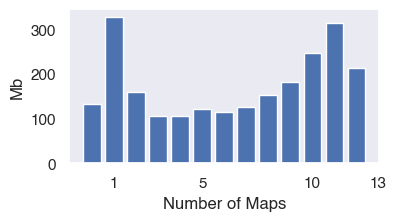

In [62]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_no_argweaverarchie = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver.bed', sep='\t', low_memory=False)
# drop archie column
boolean_overlap_no_argweaverarchie = boolean_overlap_no_argweaverarchie.drop(columns=['archie'])
boolean_overlap_no_argweaverarchie = boolean_overlap_no_argweaverarchie.rename(columns=rename_dict)

# Calculate the number of True values in each column
true_counts = boolean_overlap_no_argweaverarchie.select_dtypes(include='bool').sum(axis=1)

# Group by the number of True values and sum the lengths
sum_lengths = boolean_overlap_no_argweaverarchie.groupby(true_counts)['length'].sum()/1000000

# Plot the results
plt.figure(figsize=(4,2))
plt.bar(sum_lengths.index, sum_lengths.values)
plt.xlabel('Number of Maps')
plt.ylabel('Mb')
#plt.title('Number of Base Pairs Supported By Map Count')
plt.xticks([1,5,10,13])
#plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/base_pairs_supported_by_num_algorithms_no_argweaver.svg', bbox_inches='tight')  
plt.show()

### Num methods supporting each BP -- top 793.9 Mb

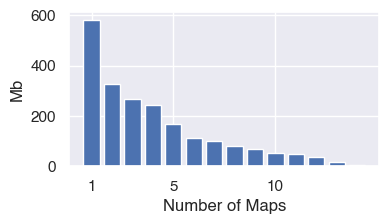

In [47]:
# read in df (generated in 0_wynton_cleaning.ipynb)
boolean_overlap_size_matched = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_updated.bed', sep='\t', low_memory=False)
# List of columns to exclude to make boolean
exclude_columns = ['chrom', 'start', 'end', 'length']
# replace 0 as NA
boolean_overlap_size_matched.replace(0, np.nan, inplace=True)
# convert values to boolean values (true or false)
boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)] = boolean_overlap_size_matched[boolean_overlap_size_matched.columns.difference(exclude_columns)].apply(lambda x: pd.notna(x))
# calculate length
boolean_overlap_size_matched['length'] = boolean_overlap_size_matched['end'] - boolean_overlap_size_matched['start']
# rename algorithms
boolean_overlap_size_matched = boolean_overlap_size_matched.rename(columns=rename_dict)

# Calculate the number of True values in each column
true_counts = boolean_overlap_size_matched.select_dtypes(include='bool').sum(axis=1)

# Group by the number of True values and sum the lengths
sum_lengths = boolean_overlap_size_matched.groupby(true_counts)['length'].sum()/1000000

# Plot the results
plt.figure(figsize=(4,2))
plt.bar(sum_lengths.index, sum_lengths.values)
plt.xlabel('Number of Maps')
plt.ylabel('Mb')
#plt.title('Number of Base Pairs Supported By Map Count')
plt.xticks([1,5,10])
#plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/base_pairs_support_sizematched.svg', bbox_inches='tight')  
plt.show()

## Plot of distance to next introgressed sequence lengths for individual-level data

In [11]:

ibdmix_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/individual_nean_chen2020_frag.bed', sep='\t', low_memory=False)
archaicseeker2_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/individual_nean_yuan2021_frag.bed', sep='\t', low_memory=False)
archaicseeker2_individual['ID'] = archaicseeker2_individual['ID'].str.split('_').str[0]
archie_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/individual_nean_durvasula2019_frag.bed', sep='\t', low_memory=False)
dicaladmix_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/individual_introgressed_steinruecken2018_frag.bed', sep='\t', low_memory=False)
dicaladmix_individual['Chromosome'] = dicaladmix_individual['Chromosome'].str.replace('chr', '')
sankararaman_2014_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/1kgids_individual_neanderthal_introgressed_fragments_pops.bed', sep='\t', low_memory=False)
vernot_2016_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/neanderthal_introgressed_haplotypes_individual.bed', sep='\t', low_memory=False)
admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
ibdmix_2024_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/individual_ibdmix_2024_introgressed_frag.bg', sep='\t', low_memory=False)
hmmix18_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/individual_nean_skov2018_frag.bed', sep='\t', low_memory=False)

dfs_dict = {'ArchaicSeeker2':archaicseeker2_individual, 
       'ArchIE':archie_individual,
        'DICALADMIX':dicaladmix_individual,
           'Sankararaman14':sankararaman_2014_individual,
           'SStar':vernot_2016_individual,
           'admixfrog':admixfrog_individual,
           'IBDMix':ibdmix_2024_individual,
           'hmmix18':hmmix18_individual}

archie_individual_vs_other_methods = pd.concat([df.assign(Algorithm=k) for k,df in dfs_dict.items()])

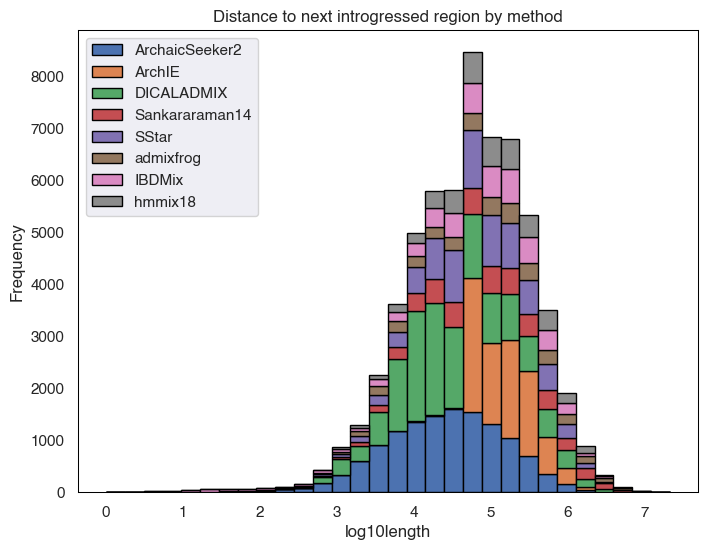

In [13]:
# we are especially interested in archie
#archie_individual_vs_other_methods=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/archie_individual_vs_other_methods.bg', sep='\t', low_memory=False)
archie_individual_vs_other_methods['length'] = archie_individual_vs_other_methods['End'] - archie_individual_vs_other_methods['Start']
# Use bedtools complement to get the non-introgressed regions for each method
dfs = {}
# temp dir to save bg from each method
TEMPDIR=f'{HOMEDIR}/introgression_methods/introgression_tools/test/'
for method in archie_individual_vs_other_methods['Algorithm'].unique():
    # specify method dir
    # only keep chrom, start, stop for that method
    df = archie_individual_vs_other_methods[archie_individual_vs_other_methods['Algorithm'] == method][['Chromosome', 'Start', 'End']]
    # save to file
    df.to_csv(f'{TEMPDIR}/temp.bg', sep='\t', index=False, header=False)
    # add chr prefix
    !sed -e 's/^/chr/' {TEMPDIR}/temp.bg > {TEMPDIR}/temp_chr_prefix.bg
    # sort
    !sort -k1,1 -k2,2n {TEMPDIR}/temp_chr_prefix.bg > {TEMPDIR}/sorted_temp_chr_prefix.bg
    # run bedtools complement
    os.system(f'{BEDTOOLSDIR}/bedtools complement -L -i {TEMPDIR}/sorted_temp_chr_prefix.bg -g {HOMEDIR}/introgression_methods/data/sorted_hg19.fa.fai > {TEMPDIR}/complement.bg')
    # subtract gaps
    os.system(f'{BEDTOOLSDIR}/bedtools subtract -a {TEMPDIR}/complement.bg -b {HOMEDIR}/introgression_methods/data/hg19_gaps.txt > {TEMPDIR}/complement_gaps_removed.bg')
    # read in file
    df = pd.read_csv(f'{TEMPDIR}/complement_gaps_removed.bg', sep='\t', names=['chrom', 'start', 'end'])
    # add length data
    df['length'] = df['end'] - df['start']
    df['log10length'] = np.log10(df['end'] - df['start'])
    # add to dict
    dfs[method]=df
    # remove temp files
    os.system(f'rm {TEMPDIR}/complement_gaps_removed.bg {TEMPDIR}/complement.bg \
                {TEMPDIR}/sorted_temp_chr_prefix.bg {TEMPDIR}/temp_chr_prefix.bg \
                {TEMPDIR}/temp.bg')

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist([df['log10length'] for df in dfs.values()], 
         bins=30, stacked=True, 
         label=dfs.keys(), edgecolor='black')

# Formatting
plt.xlabel('log10length')
plt.ylabel('Frequency')
plt.title('Distance to next introgressed region by method')
plt.legend()

# remove background
plt.gca().set_facecolor("none") 
plt.gcf().patch.set_facecolor("none")

# add borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_color("black")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/distance_to_next_region.svg',bbox_inches='tight')

plt.show()


## Jaccards and Clustering (whole introgression map + thresholded to match the ArchIE's genome-wide amount)

### Autosomes first

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2098: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled


Calculating normalized jaccard WITHOUT paired shuffled match


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2225: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


save


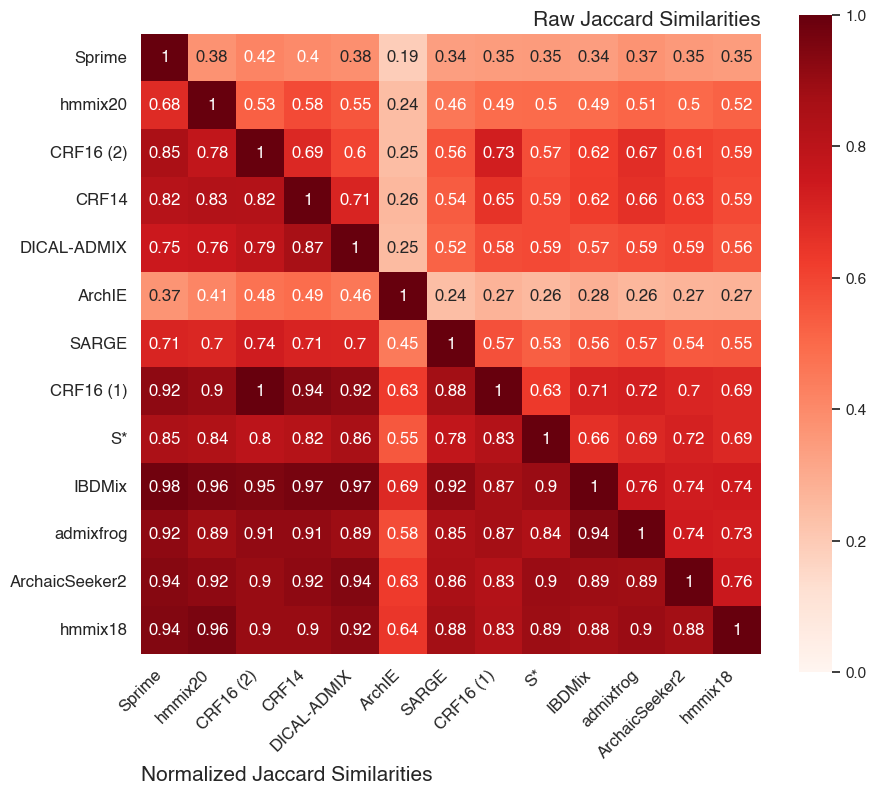

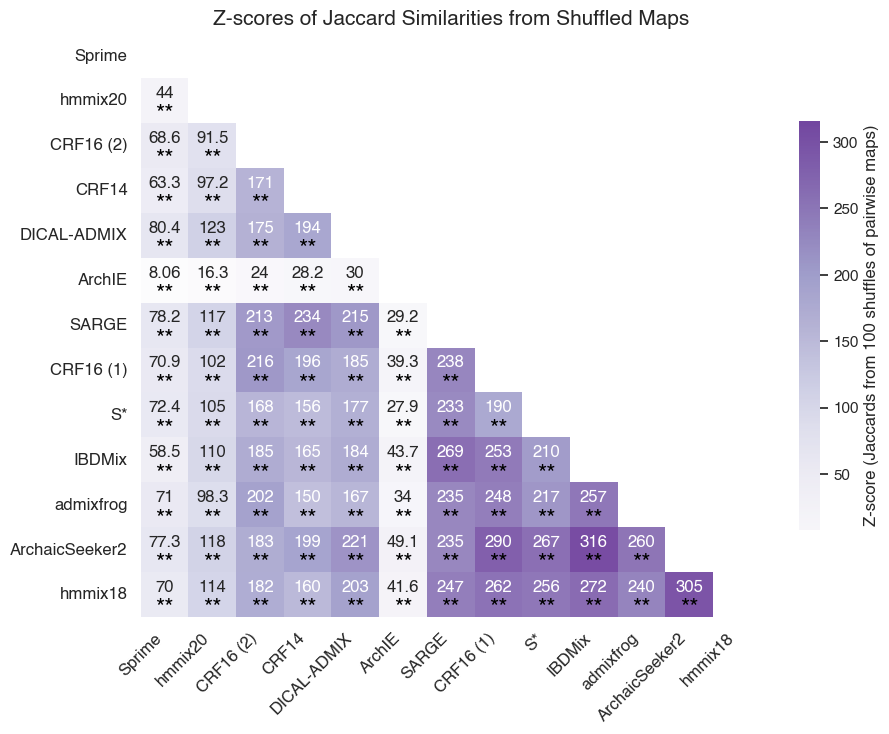

In [6]:
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_no_argweaver_updated.bed', sep='\t', low_memory=False)
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_full_map_jaccard_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        
 
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap[boolean_overlap['chrom']!='X'],
                   # get this from the clustering order
                   categories_list=['Sprime',
                                    'hmmix20',
                                    'CRF16 (2)',
                                    'CRF14',
                                    'DICAL-ADMIX',
                                    'ArchIE',
                                    'SARGE',
                                    'CRF16 (1)',
                                    'S*',
                                    'IBDMix',
                                    'admixfrog',
                                    'ArchaicSeeker2',
                                    'hmmix18'],

                   value_column='length', 
                   type='combined',
                   leaf_order=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 
                   font_size=12,
                   rename_dict=rename_dict,
                   shuffles_tsv=distributions,
                   plot_size=(10,9),
                   save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/jaccard_full_map.svg')

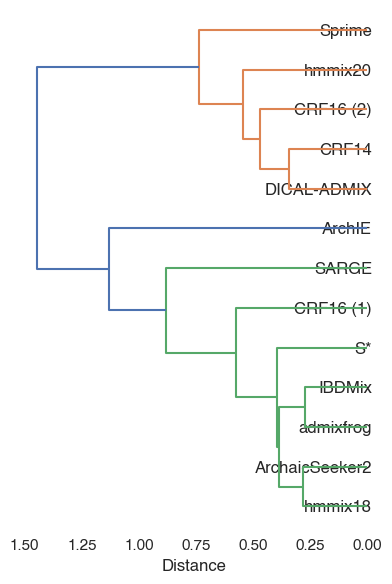

In [4]:
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(4, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/clustering_jaccard_full_map.svg',bbox_inches='tight')
plt.show()

### X Chromosome only

See /wynton/home/capra/ychen39/introgression_methods/introgression_tools/bin/job_scripts/shuffled_X_chrom_jaccard/shuffled_X_chrom_jaccard.sh

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:1574: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


save


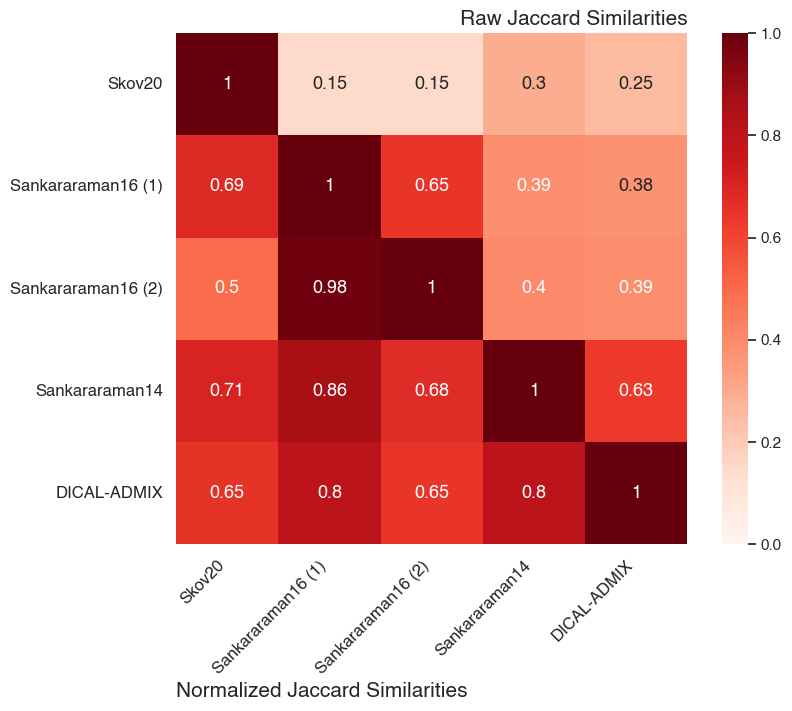

In [ ]:
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
boolean_overlap = boolean_overlap[boolean_overlap['chrom']=='X'].rename(columns=rename_dict_dir)
# drop columns with False values only
boolean_overlap = boolean_overlap.loc[:, (boolean_overlap != False).any(axis=0)]
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_X_chrom_jaccard_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        
 
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap[boolean_overlap['chrom']=='X'],
    categories_list=['hmmix20',
                    'CRF16 (2)',
                    'CRF14',
                    'CRF16 (1)',
                    'hmmix23 (X)',
                    'DICAL-ADMIX'],

    value_column='length', 
    type='combined',
    leaf_order=True, 
    font_size=12,
    rename_dict=rename_dict,
    shuffles_tsv=distributions,
    plot_size=(7,7),
    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/jaccard_X_chrom_map.svg')

/scratch/ychen39/ipykernel_3928196/80556584.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.


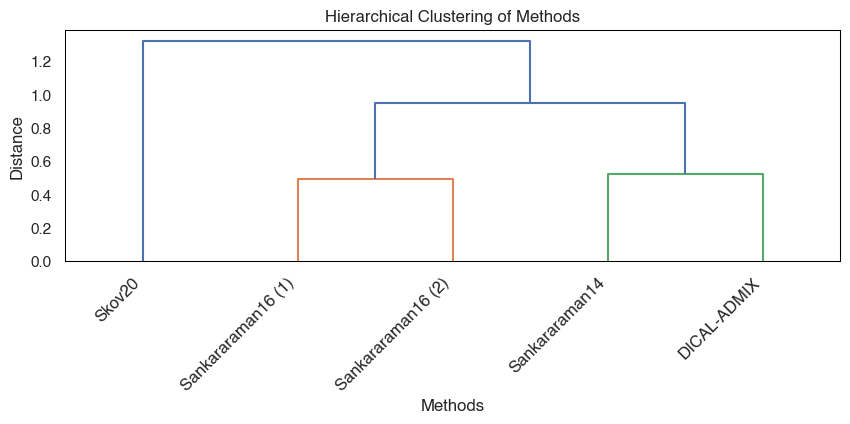

In [50]:
distance_matrix = 1 - heatmap_data
# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

leaf_order = leaves_list(Z)

plt.figure(figsize=(10, 3))
dendrogram(Z, labels=heatmap_data.columns, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering of Methods')
plt.xlabel('Methods')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')

# remove background
plt.gca().set_facecolor("none") 
plt.gcf().patch.set_facecolor("none")

# add borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_color("black")

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/clustering_jaccard_X.svg',bbox_inches='tight')
plt.show()

### Variants only

#### Autosomes only

In [32]:
boolean_overlap_variants = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_variants_with_shuffles.bg', sep='\t', low_memory=False)
boolean_overlap_variants

,chrom,start,end,sprime,vernot_2016,sankararaman_2014,sankararaman_2016_1,sankararaman_2016_2,skov_2020,skov_2018,sprime_shuffled,vernot_2016_shuffled,sankararaman_2014_shuffled,sankararaman_2016_1_shuffled,sankararaman_2016_2_shuffled,skov_2020_shuffled,skov_2018_shuffled,length
0,1,822774,822775,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
1,1,834359,834360,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
2,1,835131,835132,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
3,1,836790,836791,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
4,1,837108,837109,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2526871,6,63149112,63149113,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1
2526872,7,25997739,25997740,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1
2526873,6,13644872,13644873,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1
2526874,15,9552708,9552709,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2061: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2098: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2098: RuntimeWarning: divide by zero encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled


Calculating normalized jaccard WITHOUT paired shuffled match


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2215: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  # Reorder the Jaccard distance matrices according to the leaf order


save


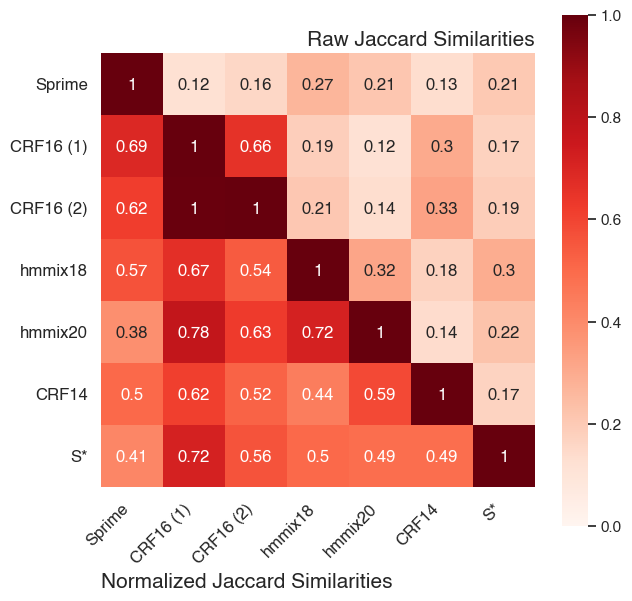

                      Sprime          CRF16 (1)          CRF16 (2)  \
Sprime                   0.0  1214343608.787553  1569346303.263895   
CRF16 (1)  1214343608.787553      10000000000.0  6567551966.271749   
CRF16 (2)  1569346303.263895  6567551966.271749      10000000000.0   
hmmix18    2686188384.577843  1871892574.057886  2086730875.628699   
hmmix20          9388.234903  1180180375.258491  1366331304.148964   
CRF14            7633.053675  3018059440.161902   3277552412.19561   
S*              11131.969937  1741444295.570944  1883790998.191092   

                     hmmix18            hmmix20              CRF14  \
Sprime     2686188384.577843        9388.234903        7633.053675   
CRF16 (1)  1871892574.057886  1180180375.258491  3018059440.161902   
CRF16 (2)  2086730875.628699  1366331304.148964   3277552412.19561   
hmmix18        10000000000.0  3170466127.715068  1752366883.964622   
hmmix20    3170466127.715068                0.0        8064.666339   
CRF14      17523668

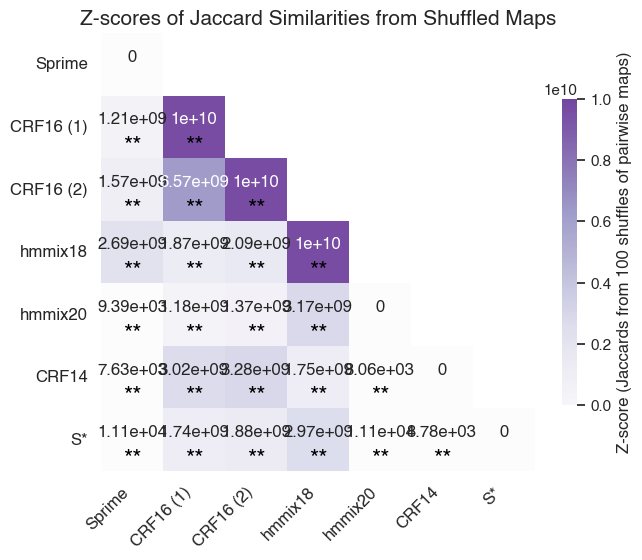

In [18]:
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_variants_with_shuffles.bg', sep='\t', low_memory=False)
boolean_overlap = boolean_overlap[boolean_overlap['chrom']!='X'].rename(columns=rename_dict_dir)
# drop columns with False values only
boolean_overlap = boolean_overlap.loc[:, (boolean_overlap != False).any(axis=0)]
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_variants_jaccard_autosomes_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        
 
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap[boolean_overlap['chrom']!='X'],
    categories_list=['CRF14', 
                     'Sprime', 
                     'S*', 
                     'CRF16 (1)', 
                     'CRF16 (2)',
                     'hmmix18', 'hmmix20'],

    value_column='length', 
    type='combined',
    leaf_order=True, 
    font_size=12,
    rename_dict=rename_dict,
    shuffles_tsv=distributions,
    plot_size=(7,7),
    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/jaccard_autosomes_variants.svg')

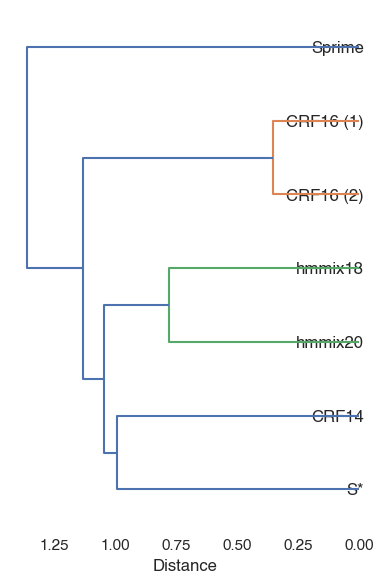

In [19]:
# dendrogram
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(4, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/clustering_jaccard_variants_autosomes.svg',bbox_inches='tight')
plt.show()

#### X only

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2061: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2098: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2215: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  # Reorder the Jaccard distance matrices according to the leaf order


Calculating normalized jaccard WITHOUT paired shuffled match
save


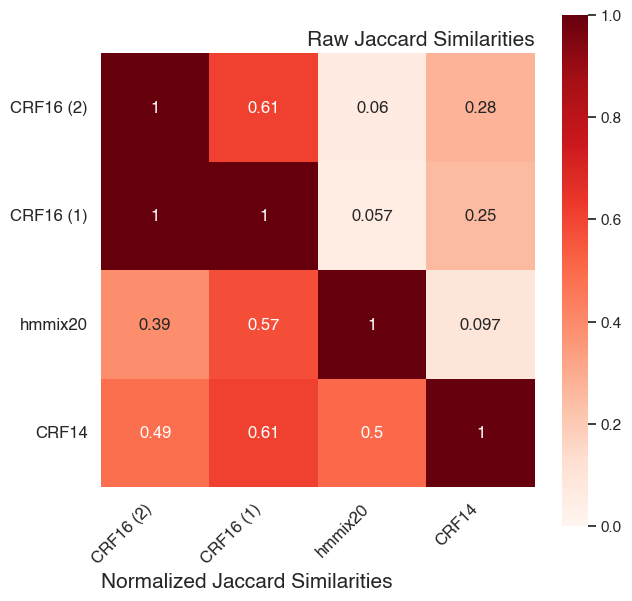

             CRF16 (2)    CRF16 (1)     hmmix20        CRF14
CRF16 (2)          0.0  3623.508396  476.574861  1645.243296
CRF16 (1)  3623.508396          0.0  656.137857  1599.838645
hmmix20     476.574861   656.137857         0.0   793.088201
CRF14      1645.243296  1599.838645  793.088201          0.0


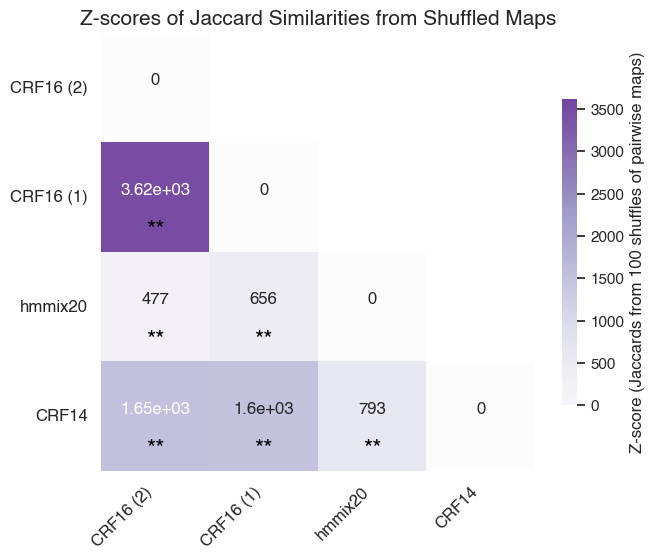

In [16]:
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_X_variants_with_shuffles.bg', sep='\t', low_memory=False)
boolean_overlap = boolean_overlap[boolean_overlap['chrom']=='X'].rename(columns=rename_dict_dir)
# drop columns with False values only
boolean_overlap = boolean_overlap.loc[:, (boolean_overlap != False).any(axis=0)]
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_variants_jaccard_X_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        
 
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap[boolean_overlap['chrom']=='X'],
    categories_list=['hmmix20',
                    'CRF16 (2)',
                    'CRF14',
                    'CRF16 (1)'],

    value_column='length', 
    type='combined',
    leaf_order=True, 
    font_size=12,
    rename_dict=rename_dict,
    shuffles_tsv=distributions,
    plot_size=(7,7),
    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/jaccard_variants_X_chrom_map.svg')

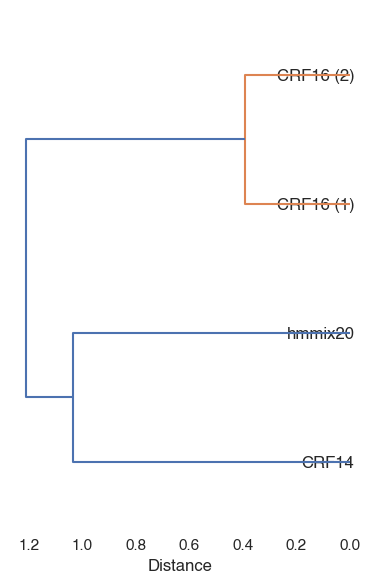

In [17]:
# dendrogram
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(4, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/clustering_jaccard_X.svg',bbox_inches='tight')
plt.show()

#### Thresholded -- Subset to highest scoring regions the size of ArchIE

##### Autosomes Only

In [11]:
# calculate threshold
# remove header from 
methods_dirs = ['chen_2020', 'yuan_2021', 'durvasula_2019', 'steinruecken_2018', 'skov_2020', 'schaefer_2021', 'browning_2018', 'vernot_2016', 'sankararaman_2014', 'sankararaman_2016_1', 'sankararaman_2016_2']
# Use bedtools complement to get the non-introgressed regions for each method
for method in methods_dirs:
    method_dir = f'/introgression_methods/cleaned/introgression_tools/{method}'
    with open(f'{HOMEDIR}/{method_dir}/bedgraphs/union_merged_highest_score.bg', 'r') as f:
        first_line = f.readline()
        if 'chrom' in first_line.lower():
            !sed -e '1d' -i {HOMEDIR}/{method_dir}/bedgraphs/union_merged_highest_score.bg

proportions = {}
for method in methods_dirs:
    method_dir = f'/introgression_methods/cleaned/introgression_tools/{method}'
    df = pd.read_csv(f'{HOMEDIR}/{method_dir}/bedgraphs/union_merged_highest_score.bg', sep='\t', low_memory=False, names=['chrom', 'Start', 'End', 'Score'])
    # compute length
    df['length'] = df['End'] - df['Start']
    # compute the minumum amount of introgression across people
    min_sum = df['length'].sum().min()
    # add the minimum amount to the dict
    proportions[method] = min_sum
# get the smallest value to use as length_threshold
length_threshold = min(proportions.values())
print(proportions, length_threshold)

{'chen_2020': 1291413343, 'yuan_2021': 1534838051, 'durvasula_2019': 793900000, 'steinruecken_2018': 1023339000, 'skov_2020': 889069710, 'schaefer_2021': 1068860156, 'browning_2018': 1243444992, 'vernot_2016': 1339505007, 'sankararaman_2014': 1117531142, 'sankararaman_2016_1': 1558018928, 'sankararaman_2016_2': 1141804104} 793900000


In [57]:
boolean_overlap_shared_length_highest_scores = tools.generate_overlap(input_files_string=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged_highest_score.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged_highest_score.bg',
    input_files_names_str='ibdmix20 archaicseeker archie sprime vernot_2016 sankararaman_2014 sankararaman_2016_1 sankararaman_2016_2 hmmix20 steinruecken_2018 sarge hmmix18 ibdmix24 admixfrog',
    output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_updated.bed',
    boolean=True, autosomes=True, length_threshold=590956654)

### Size-matched comparison

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2057: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2094: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled


save


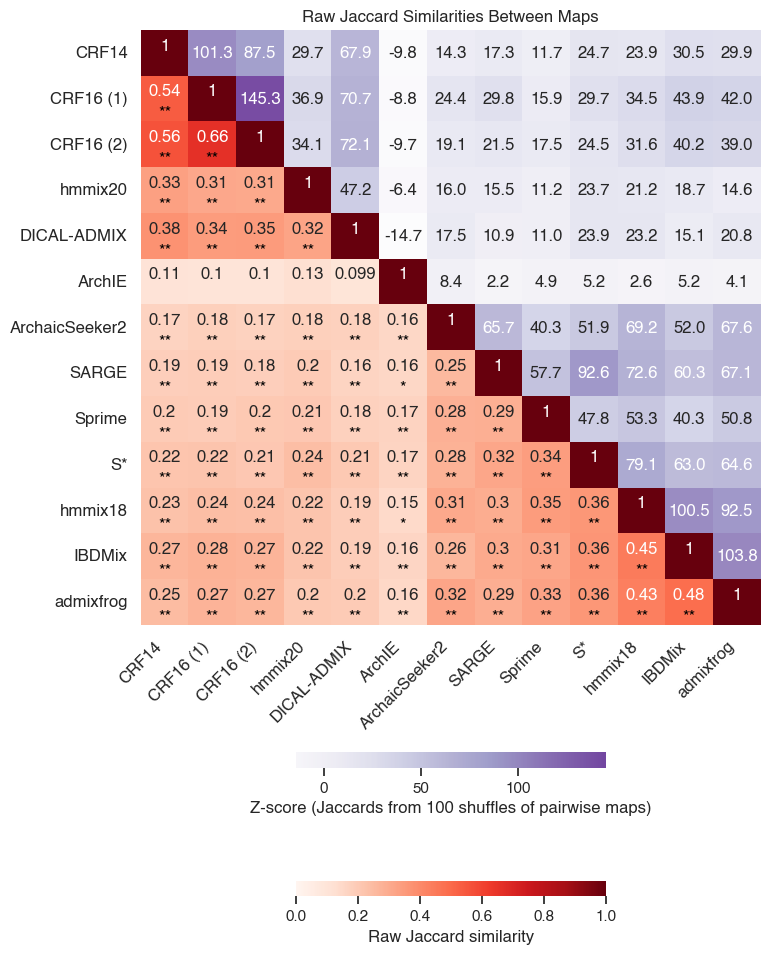

In [108]:
boolean_overlap_shared_length_highest_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_updated.bg', sep='\t')
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_size_matched_jaccard_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        

heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap_shared_length_highest_scores[boolean_overlap_shared_length_highest_scores['chrom']!='X'],
                   # get this from the clustering order
                   categories_list=['hmmix20', 'CRF14', 'DICAL-ADMIX', 'SARGE', 'CRF16 (1)',
                                    'CRF16 (2)', 'S*', 'ArchaicSeeker2', 'hmmix18', 
                                    'IBDMix', 'admixfrog', 'ArchIE', 'Sprime'],

                   value_column='length', 
                   type='raw',
                   leaf_order=True, 
                   font_size=12,
                   rename_dict=rename_dict,
                   shuffles_tsv=distributions,
                   save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/jaccard_size_subset.svg')

/scratch/ychen39/ipykernel_3029178/3206611954.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.


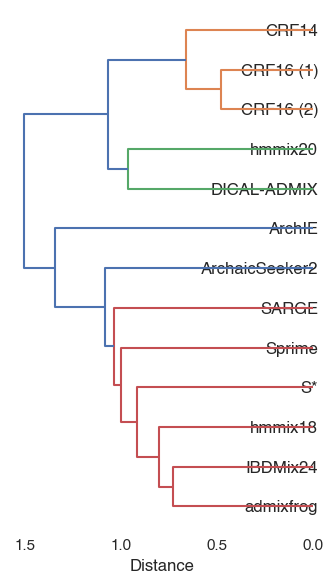

In [12]:
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(3.5, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/clustering_jaccard_size_subset.svg',bbox_inches='tight')

plt.show()

### size matched (non-shuffled)

In [21]:
boolean_overlap_shared_length_highest_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_updated_shuffles.bg', sep='\t')

In [9]:
# check how much base pairs are included in each method
for method in ['ibdmix20', 'archaicseeker', 'archie', 'sprime', 'vernot_2016', 'sankararaman_2014', 'sankararaman_2016_1', 'sankararaman_2016_2', 'hmmix20', 'steinruecken_2018', 'sarge', 'hmmix18', 'ibdmix24', 'admixfrog']:
    print(method, boolean_overlap_shared_length_highest_scores[boolean_overlap_shared_length_highest_scores[method]==True]['length'].sum())


ibdmix20 590916341
archaicseeker 590594143
archie 590950000
sprime 590956654
vernot_2016 590939544
sankararaman_2014 590747216
sankararaman_2016_1 590952501
sankararaman_2016_2 590897288
hmmix20 590769456
steinruecken_2018 590954500
sarge 590940822
hmmix18 590740499
ibdmix24 590877158
admixfrog 590895311


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2035: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


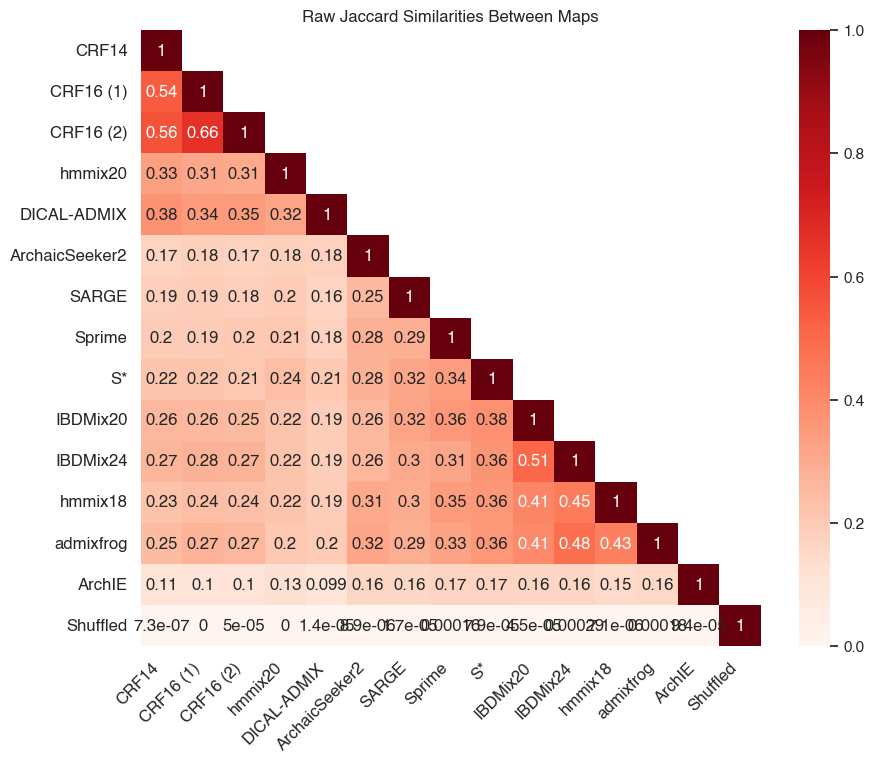

In [48]:
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap_shared_length_highest_scores[boolean_overlap_shared_length_highest_scores['chrom']!='X'],
                   # get this from the clustering order
                   categories_list=['hmmix20', 'sankararaman_2014', 'steinruecken_2018', 'sarge', 'sankararaman_2016_1',
                                    'sankararaman_2016_2', 'ibdmix20', 'vernot_2016', 'archaicseeker', 'hmmix18', 
                                    'ibdmix24', 'admixfrog', 'archie', 'sprime', 'ibdmix20_shuffled',
                                    'archaicseeker_shuffled', 'archie_shuffled', 'sprime_shuffled',
                                    'vernot_2016_shuffled', 'sankararaman_2014_shuffled',
                                    'sankararaman_2016_1_shuffled', 'sankararaman_2016_2_shuffled',
                                    'hmmix20_shuffled', 'steinruecken_2018_shuffled', 'sarge_shuffled',
                                    'hmmix18_shuffled', 'ibdmix24_shuffled', 'admixfrog_shuffled'],

                   value_column='length', 
                   type='raw',
                   leaf_order=True, 
                   font_size=12,
                   rename_dict=rename_dict,
                   paired_shuffled_match=True,)
                   #save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/jaccard_archie_size_subset.svg')


                   # manually changed the 'shuffled' text font size in inkscape

In [66]:
# get the lower triangle
lower_tri = np.tril(heatmap_data)
# fill upper triangle with np.nan
upper_indices = np.triu_indices(lower_tri.shape[0])
lower_tri[upper_indices] = np.nan
# # remove diagonal
np.fill_diagonal(lower_tri, np.nan)
# remove last row (shuffled)
lower_tri = lower_tri[:-1, :-1]
# convert values to one big list, drop nan
list = lower_tri.ravel().tolist()
#  drop nan
filtered_list = [item for item in list if not np.isnan(item)] 
# len(filtered_list) = 91, good
np.mean(filtered_list)

0.2654036240651209

/scratch/ychen39/ipykernel_3326417/3847075494.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.


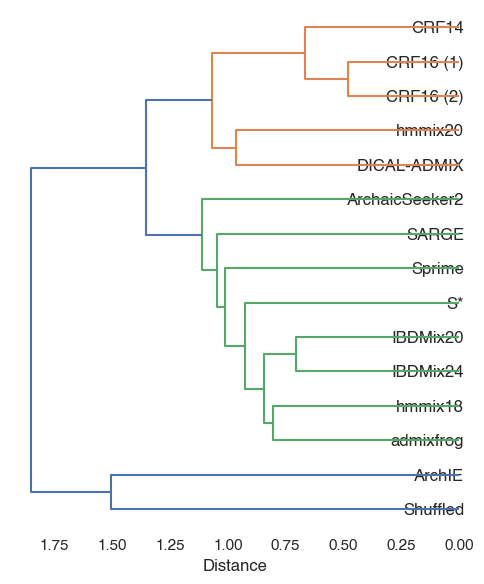

In [111]:
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(5, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/clustering_jaccard_archie_size_subset.svg',bbox_inches='tight')

plt.show()

### Investigate clusters

In [29]:
df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
df = df.rename(columns=rename_dict)

cluster1_list = ['CRF14', 'CRF16 (1)', 'CRF16 (2)', 'hmmix20', 'DICAL-ADMIX']
cluster2_list = ['ArchaicSeeker2', 'SARGE', 'Sprime', 'S*', 'IBDMix', 'hmmix18', 'admixfrog']

# add chr prefix to chrom column for great
df['chrom'] = df['chrom'].apply(lambda x: 'chr' + str(x) if not str(x).startswith('chr') else str(x))

cluster1 = df[df[cluster1_list].all(axis=1)]
cluster2 = df[df[cluster2_list].all(axis=1)]
unique_cluster1 = cluster1[~cluster1.index.isin(cluster2.index)]
unique_cluster2 = cluster2[~cluster2.index.isin(cluster1.index)]


In [ ]:
# write to bed files
!mkdir {HOMEDIR}/introgression_methods/cleaned/introgression_tools/cluster_analysis

unique_cluster1[['chrom', 'start', 'end']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/cluster_analysis/cluster1_unique.bed', sep='\t', index=False, header=False)
unique_cluster2[['chrom', 'start', 'end']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/cluster_analysis/cluster2_unique.bed', sep='\t', index=False, header=False)
unique_cluster1[['chrom', 'start', 'end']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/cluster_analysis/cluster1_full.bed', sep='\t', index=False, header=False)
unique_cluster2[['chrom', 'start', 'end']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/cluster_analysis/cluster2_full.bed', sep='\t', index=False, header=False)

mkdir: cannot create directory ‘/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/cluster_analysis’: File exists


In [ ]:
# empty dict to hold scores
cluster1_b_stat = {}
cluster2_b_stat = {}
unique_cluster1_b_stat = {}

# read in b statistic information_
b_stat = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/merged_bstats_hg19.bed', sep='\t', names=['chrom', 'start', 'end', 'b_stat'])
b_stat_bed = pybedtools.BedTool.from_dataframe(b_stat)
b_stat_bed = b_stat_bed.sort()

# convert to BedTool object for pybedtools
cluster1_bed = pybedtools.BedTool.from_dataframe(cluster1[['chrom', 'start', 'end']])
cluster2_bed = pybedtools.BedTool.from_dataframe(cluster2[['chrom', 'start', 'end']])
unique_cluster1_bed = pybedtools.BedTool.from_dataframe(unique_cluster1[['chrom', 'start', 'end']])
cluster1_bed = cluster1_bed.sort()
cluster2_bed = cluster2_bed.sort()
unique_cluster1_bed = unique_cluster1_bed.sort()

# for introgressed and non introgressed windows, compute average B statistic for each 5kb window
# remove intersections that are less than 5 kb
# cluster 1
cluster1_b_stat_intersect = cluster1_bed.intersect(b_stat_bed, wo=True) # ThickStart is the b stat score, thickEnd is the length of the intersection
cluster1_b_stat_intersect = cluster1_b_stat_intersect.to_dataframe()
cluster1_b_stat_intersect = cluster1_b_stat_intersect.drop_duplicates()
# cluster 2
cluster2_b_stat_intersect = cluster2_bed.intersect(b_stat_bed, wo=True)
cluster2_b_stat_intersect = cluster2_b_stat_intersect.to_dataframe()
cluster2_b_stat_intersect = cluster2_b_stat_intersect.drop_duplicates()
# regions unique to cluster 1
unique_cluster1_b_stat_intersect = unique_cluster1_bed.intersect(b_stat_bed, wo=True)
unique_cluster1_b_stat_intersect = unique_cluster1_b_stat_intersect.to_dataframe()
unique_cluster1_b_stat_intersect = unique_cluster1_b_stat_intersect.drop_duplicates()

# print average b stat for each cluster, averaged over the length (thickEnd)
print('Cluster 1 average B stat:', (cluster1_b_stat_intersect['thickStart']*cluster1_b_stat_intersect['thickEnd']).sum()/cluster1_b_stat_intersect['thickEnd'].sum())
print('Cluster 2 average B stat:', (cluster2_b_stat_intersect['thickStart']*cluster2_b_stat_intersect['thickEnd']).sum()/cluster2_b_stat_intersect['thickEnd'].sum())
print('Unique Cluster 1 average B stat:', (unique_cluster1_b_stat_intersect['thickStart']*unique_cluster1_b_stat_intersect['thickEnd']).sum()/unique_cluster1_b_stat_intersect['thickEnd'].sum())
print('Unique Cluster 2 average B stat:', (unique_cluster1_b_stat_intersect['thickStart']*unique_cluster1_b_stat_intersect['thickEnd']).sum()/unique_cluster1_b_stat_intersect['thickEnd'].sum())

Cluster 1 average B stat: 767.4007688787354
Cluster 2 average B stat: 768.1026110460654
Unique Cluster 1 average B stat: 767.7929735617652


In [8]:
# print lengths of each cluster
print('Cluster 1 total length (Mb):', cluster1.length.sum()/1000000)
print('Cluster 2 total length (Mb):', cluster2.length.sum()/1000000)

Cluster 1 total length (Mb): 556.591202
Cluster 2 total length (Mb): 331.465586


### X Only - Size matched

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2061: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2098: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2212: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


Calculating normalized jaccard WITHOUT paired shuffled match
save


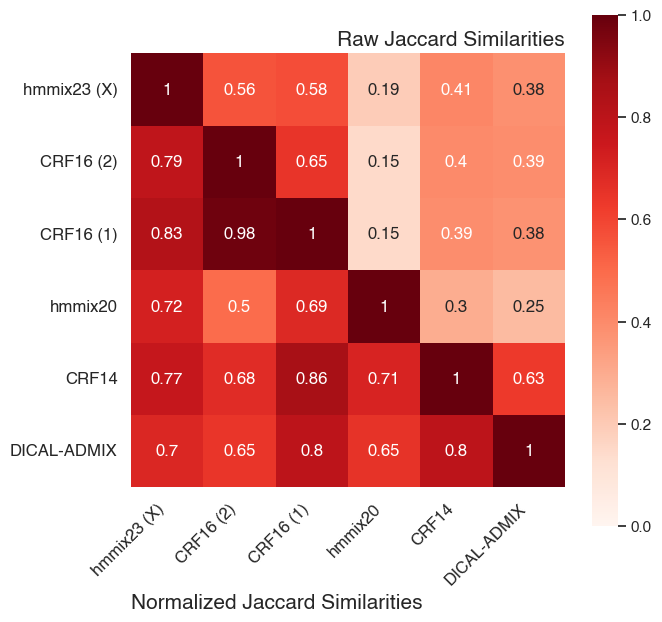

            hmmix23 (X)  CRF16 (2)  CRF16 (1)   hmmix20      CRF14 DICAL-ADMIX
hmmix23 (X)         NaN  11.218091  13.410192 -0.281326   7.596519    8.148147
CRF16 (2)     11.218091        NaN  16.315295 -1.029902   7.527529    8.211829
CRF16 (1)     13.410192  16.315295        NaN -1.504348   8.591995    8.545572
hmmix20       -0.281326  -1.029902  -1.504348       NaN   3.572521    2.052662
CRF14          7.596519   7.527529   8.591995  3.572521        NaN   22.039284
DICAL-ADMIX    8.148147   8.211829   8.545572  2.052662  22.039284         NaN


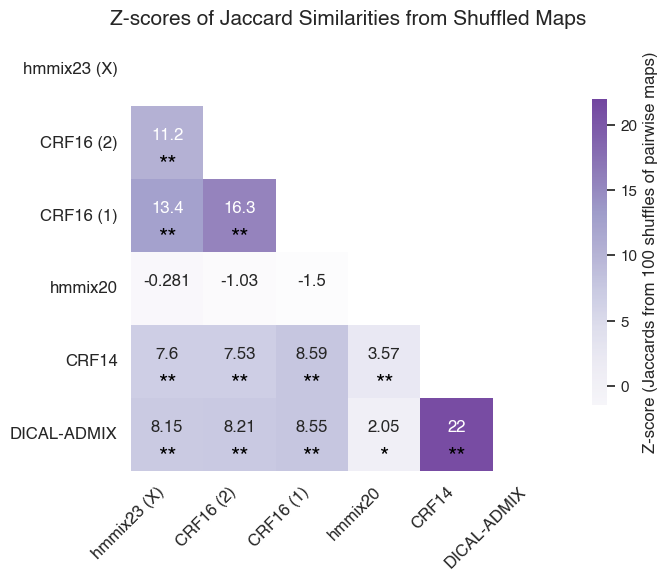

In [36]:
boolean_overlap = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap.bed', sep='\t', low_memory=False)
boolean_overlap = boolean_overlap[boolean_overlap['chrom']=='X'].rename(columns=rename_dict_dir)
# drop columns with False values only
boolean_overlap = boolean_overlap.loc[:, (boolean_overlap != False).any(axis=0)]
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparisons/shuffled_X_chrom_jaccard_size_matched_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        
 
heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap[boolean_overlap['chrom']=='X'],
    categories_list=['hmmix20',
                    'CRF16 (2)',
                    'CRF14',
                    'CRF16 (1)',
                    'hmmix23 (X)',
                    'DICAL-ADMIX'],

    value_column='length', 
    type='combined',
    leaf_order=True, 
    font_size=12,
    rename_dict=rename_dict,
    shuffles_tsv=distributions,
    plot_size=(7,7),
    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/jaccard_X_chrom_size_matched_map.svg')

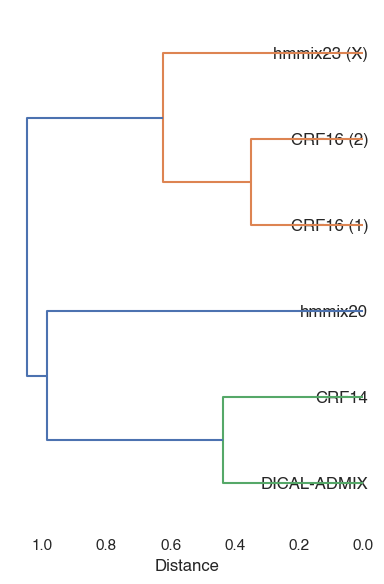

In [35]:
# dendrogram
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(4, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/clustering_jaccard_variants_X_size_matched.svg',bbox_inches='tight')
plt.show()

#### Thresholded EUR only -- Subset to highest scoring regions the size of ArchIE (DID NOT INCLUDE)

Only look at EUR regions for each method

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:1574: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


save


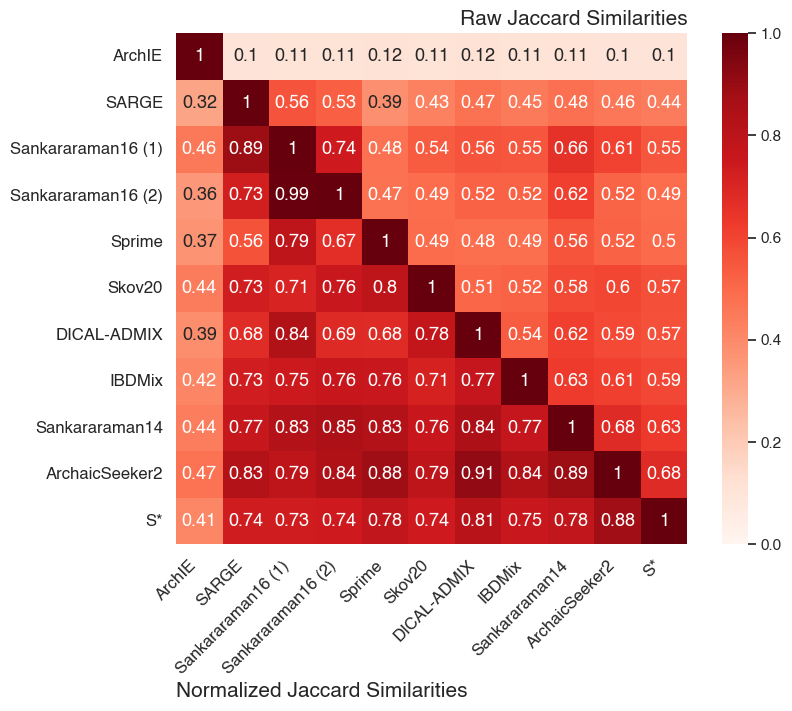

In [14]:
# also a version with EUR regions only
boolean_overlap_shared_length_highest_scores_EUR = tools.generate_overlap(input_files_string=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/merged_Icelandic.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/merged_CEU.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/merged_WestEurasia.bg',
                                           input_files_names_str='ibdmix archaicseeker archie sprime vernot_2016 sankararaman_2014 sankararaman_2016_1 sankararaman_2016_2 skov_2020 steinruecken_2018 sarge',
                                           output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/test.bed',
                                           boolean=True, autosomes=True)

boolean_overlap_shared_length_highest_scores_EUR = boolean_overlap_shared_length_highest_scores_EUR.rename(columns=rename_dict)

heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap_shared_length_highest_scores_EUR,
                   categories_list=['IBDMix', 'ArchaicSeeker2',
                                   'ArchIE', 'Sprime', 'S*', 'Sankararaman14', 'Sankararaman16 (1)',
                                   'Sankararaman16 (2)', 'Skov20', 'DICAL-ADMIX', 'SARGE'],
                   value_column='length', leaf_order=True,
                    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/EUR_autosomes.svg')

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:1574: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


save


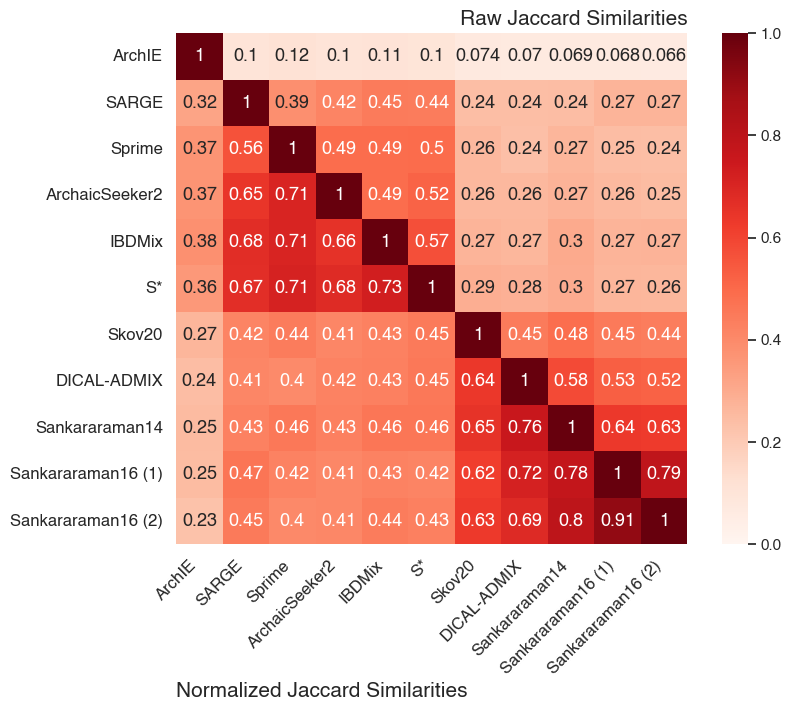

In [15]:
# also a version with EUR regions only
boolean_overlap_shared_length_highest_scores_EUR = tools.generate_overlap(input_files_string=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/merged_EUR.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/merged_Icelandic.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/merged_CEU.bg \
    {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/merged_WestEurasia.bg',
                                           input_files_names_str='ibdmix archaicseeker archie sprime vernot_2016 sankararaman_2014 sankararaman_2016_1 sankararaman_2016_2 skov_2020 steinruecken_2018 sarge',
                                           output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_shared_length_highest_scores_EUR.bed',
                                           boolean=True, autosomes=True, length_threshold=719560342)

boolean_overlap_shared_length_highest_scores_EUR = boolean_overlap_shared_length_highest_scores_EUR.rename(columns=rename_dict)

heatmap_data=tools.plot_jaccard(boolean_df=boolean_overlap_shared_length_highest_scores_EUR,
                   categories_list=['IBDMix', 'ArchaicSeeker2',
                                   'ArchIE', 'Sprime', 'S*', 'Sankararaman14', 'Sankararaman16 (1)',
                                   'Sankararaman16 (2)', 'Skov20', 'DICAL-ADMIX', 'SARGE'],
                   value_column='length', leaf_order=True,
                    save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/jaccard_archie_size_subset_EUR.svg')

/scratch/ychen39/ipykernel_3928196/3076255287.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.


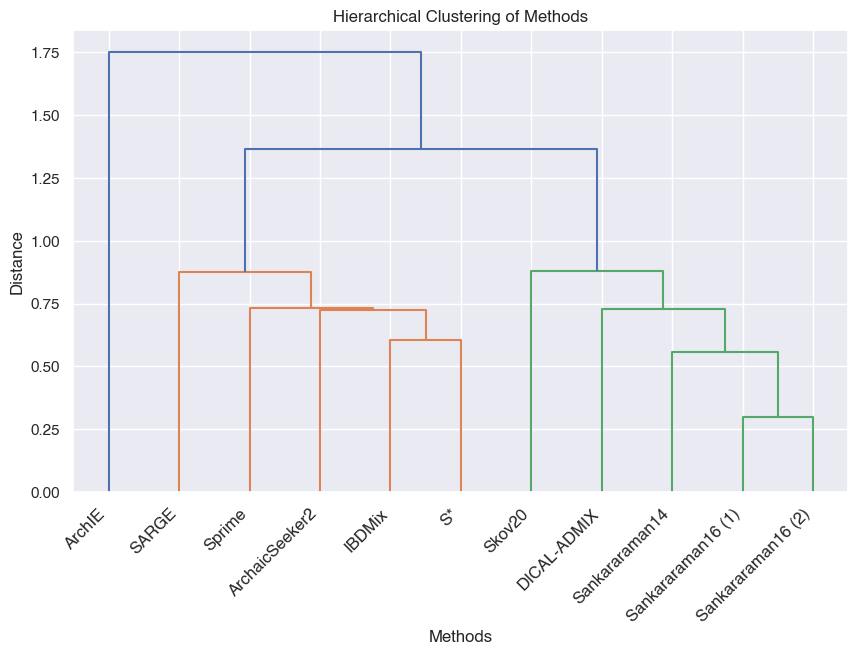

In [16]:
distance_matrix = 1 - heatmap_data
# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

leaf_order = leaves_list(Z)

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=heatmap_data.columns, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering of Methods')
plt.xlabel('Methods')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')
pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/clustering_jaccard_archie_size_subset_EUR.svg',bbox_inches='tight')
plt.show()

## Individual-Level Jaccard

### make combined file for supplement

In [6]:
# # make combined file for supplement
# ibdmix_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/individual_nean_chen2020_frag.bed', sep='\t', low_memory=False)
# archaicseeker2_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/individual_nean_yuan2021_frag.bed', sep='\t', low_memory=False)
# archaicseeker2_individual['ID'] = archaicseeker2_individual['ID'].str.split('_').str[0]
# archie_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/individual_nean_durvasula2019_frag.bed', sep='\t', low_memory=False)
# dicaladmix_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/individual_introgressed_steinruecken2018_frag.bed', sep='\t', low_memory=False)
# dicaladmix_individual['Chromosome'] = dicaladmix_individual['Chromosome'].str.replace('chr', '')
# sankararaman_2014_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/1kgids_individual_neanderthal_introgressed_fragments_pops.bed', sep='\t', low_memory=False)
# vernot_2016_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/neanderthal_introgressed_haplotypes_individual.bed', sep='\t', low_memory=False)
# admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# ibdmix_2024_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/individual_ibdmix_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# hmmix18_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/individual_nean_skov2018_frag.bed', sep='\t', low_memory=False)

# # make a dictionary to get from Illumina_ID to SGDP_ID
# SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
# SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
# SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

# SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
# SARGE_individual.rename(columns={'#chrom': 'Chromosome',
#                                 'start': 'Start',
#                                 'end': 'End',
#                                 'len': 'length',
#                                 'score': 'Score'}, inplace=True)

# # remove prefix and suffix
# SARGE_individual['ID'] = SARGE_individual['hap'].apply(lambda x: '_'.join(x.split('_')[1:]))
# SARGE_individual['ID'] = SARGE_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

# SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
# SARGE_individual.rename(columns={'#chrom': 'Chromosome',
#                                 'start': 'Start',
#                                 'end': 'End',
#                                 'len': 'length',
#                                 'score': 'Score'}, inplace=True)

# archaicseeker2_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/individual_nean_yuan2021_frag.bed', sep='\t', low_memory=False)
# archaicseeker2_individual['ID'] = archaicseeker2_individual['ID'].str.split('_').str[0]

# argweaverd_individual_papuan=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/papuan_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
# argweaverd_individual_khomani_san=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/khomani_san_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
# argweaverd_individual_mandenka=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/mandenka_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
# argweaverd_individual = pd.concat([argweaverd_individual_papuan, argweaverd_individual_khomani_san, argweaverd_individual_mandenka])

# sankararaman16_1_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
# sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].str.split('_').str[1].str.split('-').str[:2].str.join('-')
# sankararaman16_2_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
# sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].str.split('_').str[1].str.split('-').str[:2].str.join('-')

# # make a dictionary to get from Illumina_ID to SGDP_ID
# SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
# SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID.str.split('_').str[1]))

# argweaverd_individual['ID'] = argweaverd_individual['ID'].replace(SGDP_metadata_dict) # remap IDs
# SARGE_individual['ID'] = SARGE_individual['hap'].str.split('_').str[1].str.split('-').str[:2].str.join('-') # create ID column by removing the prefix and the 2 chromosomes id at the end

# admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# # remove prefix from IDs
# admixfrog_individual['ID'] = [ID.split('_')[1] if '-' in ID else ID for ID in admixfrog_individual['ID']]


dfs_dict = {'ArchaicSeeker2':archaicseeker2_individual, 
       'ArchIE':archie_individual,
        'DICALADMIX':dicaladmix_individual,
           'Sankararaman14':sankararaman_2014_individual,
           'SStar':vernot_2016_individual,
           'IBDMix':ibdmix_2024_individual,
           'hmmix18':hmmix18_individual,
           'SARGE':SARGE_individual, 
            'ARGweaver-D':argweaverd_individual,
            'CRF16_1':sankararaman16_1_individual,
            'CRF16_2':sankararaman16_2_individual,
            'admixfrog':admixfrog_individual}

# concat dfs together, adding a column for the method
# keep only ID	Chromosome	Start	End	Score ScoreName 

combined_df = pd.DataFrame()
for map, df in dfs_dict.items():
    df['Map'] = map
    combined_df = pd.concat([combined_df, df], ignore_index=True)


combined_df[['ID', 'Chromosome', 'Start', 'End', 'Score', 'Map']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/supplement_data/combined_individual_level.bg', sep='\t', index=False)

In [11]:
## ceu
dfs_dict = {'ArchaicSeeker2':archaicseeker2_individual, 
       'ArchIE':archie_individual,
        'DICALADMIX':dicaladmix_individual,
           'Sankararaman14':sankararaman_2014_individual,
           'SStar':vernot_2016_individual,
           'admixfrog':admixfrog_individual,
           'IBDMix':ibdmix_2024_individual,
           'hmmix18':hmmix18_individual}


heatmap_data=tools.individual_jaccard_comparison(dfs_dict = dfs_dict,
    temp_dir=f'{HOMEDIR}/introgression_methods/data/tmp/', 
    output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/tmp.tsv',
    # also save the ibdmix_archaicseeker2_archie_dicaladmix_sstar_sankararaman14_individual file so we can compute lengths distributions across these methods
    # mainly to compare against archie      
    save_shared_individuals_bed=f'{HOMEDIR}/introgression_methods/cleaned/supplement_data/84_ceu_individual.bg',
    return_heatmap=True,
    autosomes_only=True,
    x_only=False)

['ArchaicSeeker2', 'ArchIE', 'DICALADMIX', 'Sankararaman14', 'SStar', 'admixfrog', 'IBDMix', 'hmmix18'] : 84 individuals shared,  ['NA06984', 'NA06986', 'NA06989', 'NA06994', 'NA07000', 'NA07037', 'NA07048', 'NA07051', 'NA07056', 'NA07347', 'NA07357', 'NA10847', 'NA10851', 'NA11829', 'NA11830', 'NA11831', 'NA11843', 'NA11892', 'NA11893', 'NA11894', 'NA11919', 'NA11920', 'NA11930', 'NA11931', 'NA11932', 'NA11933', 'NA11992', 'NA11994', 'NA11995', 'NA12003', 'NA12004', 'NA12006', 'NA12043', 'NA12044', 'NA12045', 'NA12046', 'NA12058', 'NA12144', 'NA12154', 'NA12155', 'NA12249', 'NA12272', 'NA12273', 'NA12275', 'NA12282', 'NA12283', 'NA12286', 'NA12287', 'NA12340', 'NA12341', 'NA12342', 'NA12347', 'NA12348', 'NA12383', 'NA12399', 'NA12400', 'NA12413', 'NA12489', 'NA12546', 'NA12716', 'NA12717', 'NA12718', 'NA12748', 'NA12749', 'NA12750', 'NA12751', 'NA12761', 'NA12763', 'NA12775', 'NA12777', 'NA12778', 'NA12812', 'NA12814', 'NA12815', 'NA12827', 'NA12829', 'NA12830', 'NA12842', 'NA12843', 

In [15]:
# AFR
# read in all the data
SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
SARGE_individual.rename(columns={'#chrom': 'Chromosome',
                                'start': 'Start',
                                'end': 'End',
                                'len': 'length',
                                'score': 'Score'}, inplace=True)

# remove prefix and suffix
SARGE_individual['ID'] = SARGE_individual['hap'].apply(lambda x: '_'.join(x.split('_')[1:]))
SARGE_individual['ID'] = SARGE_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# remove prefix from IDs
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]) if '-' in x else x)

#argweaverd_individual_papuan=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/papuan_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_khomani_san=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/khomani_san_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_mandenka=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/mandenka_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual = pd.concat([argweaverd_individual_khomani_san, argweaverd_individual_mandenka])
argweaverd_individual['ID'] = argweaverd_individual['ID'].replace(SGDP_metadata_dict) # remap IDs

# one papuan individual
dfs_dict = {'SARGE':SARGE_individual, 
            'argweaverd':argweaverd_individual,
            'admixfrog':admixfrog_individual,
            }

# check shared IDS
heatmap_data=tools.individual_jaccard_comparison(dfs_dict = dfs_dict,
                              autosomes_only=True,
                              x_only=False,
                              temp_dir=f'{HOMEDIR}/introgression_methods/data/tmp/',
                              output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/tmp.tsv',
                              save_shared_individuals_bed=f'{HOMEDIR}/introgression_methods/cleaned/supplement_data/2_afr_individual.bg',
                              return_heatmap=True)

['SARGE', 'argweaverd', 'admixfrog'] : 2 individuals shared,  ['Khomani_San-1', 'Mandenka-2']


### 84 CEU individuals (ArchIE has them)

Look at /wynton/home/capra/ychen39/introgression_methods/introgression_tools/bin/job_scripts/individual_jaccard_84_ceu/individual_jaccard_84_ceu.sh

In [48]:
p_vals = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU84/Empirical_P_Values', sep='\t')
# subset rows with empirical p value for ArchIE:ArchaicSeeker2 < 0.05
p_vals[(p_vals['Pair']=='IBDMix:admixfrog')].Empirical_P_Values.std()

0.0012572815234260563

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2950: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


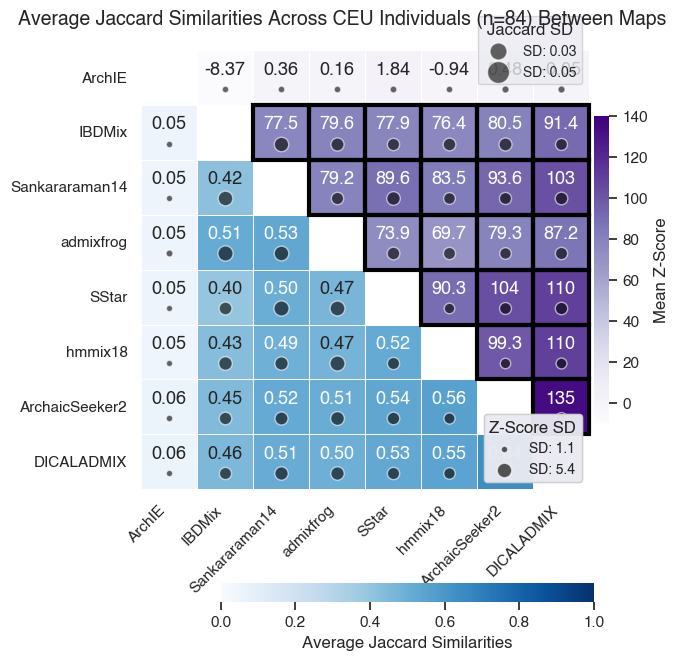

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3233: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')


DICALADMIX


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3300: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([rename_dict.get(label, label) for label in axs[0].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3301: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([rename_dict.get(label, label) for label in axs[1].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3302: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels([rename_dict.get(label, label) for label in axs[2].get_xticklabels()])
/wynton/home/cap

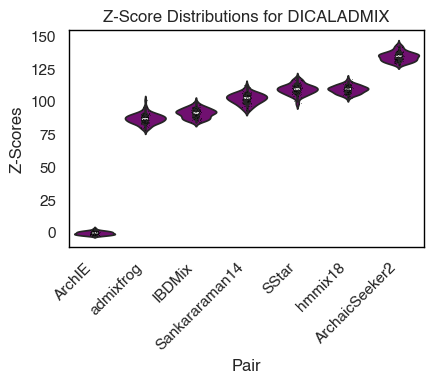

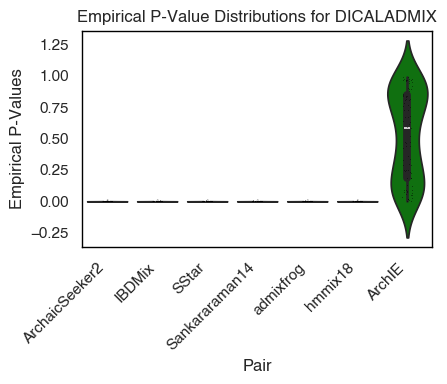

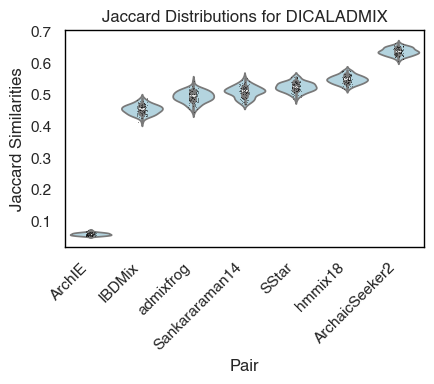

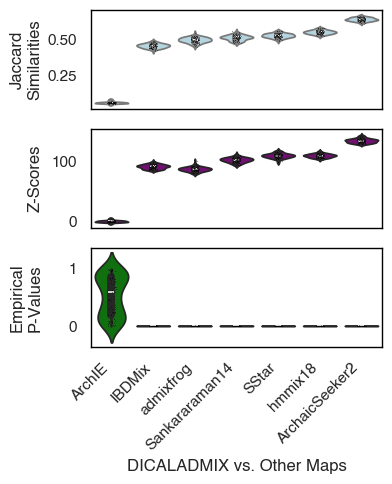

In [3]:
#Generate plots

heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU84/heatmap_data_observed.pkl', 'rb'))


tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU84/Z_Scores',
    empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU84/Empirical_P_Values',
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU84/Jaccards',
    color='Blues',
    sd_sizes=[0.03, 0.05],
    title = 'Average Jaccard Similarities Across CEU Individuals (n=84) Between Maps',
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/ceu_individual/ceu_individual_test.svg',
    distributions_figsize_tuple=(4, 5),
    zscore_range_cmap = (-10, 140)
)

#### X only (did not put in paper)

In [35]:
# report number of IDs shared between methods
    # get list of different algorithms in comparison
num_algorithms = len(dfs_dict)
algorithms = list(dfs_dict.keys())

# make combined dataframe
individual_concat = pd.concat([df.assign(Algorithm=k) for k,df in dfs_dict.items()])
# keep autosomes only
individual_concat = individual_concat[individual_concat['Chromosome'] == 'X']
    
# Group by ID and count unique values in 'Value'
id_value_counts = individual_concat.groupby('ID')['Algorithm'].nunique()
# Filter IDs that are counted in all individual level dataframes
shared_individuals = id_value_counts[id_value_counts == num_algorithms].index.tolist()    
print(algorithms, ":", len(shared_individuals), 'individuals shared, ', shared_individuals)

['DICALADMIX', 'Sankararaman14'] : 265 individuals shared,  ['HG00403', 'HG00404', 'HG00406', 'HG00407', 'HG00418', 'HG00419', 'HG00421', 'HG00422', 'HG00427', 'HG00428', 'HG00436', 'HG00437', 'HG00442', 'HG00443', 'HG00446', 'HG00448', 'HG00449', 'HG00451', 'HG00452', 'HG00457', 'HG00458', 'HG00463', 'HG00464', 'HG00472', 'HG00473', 'HG00476', 'HG00478', 'HG00479', 'HG00500', 'HG00501', 'HG00512', 'HG00513', 'HG00525', 'HG00530', 'HG00531', 'HG00533', 'HG00534', 'HG00536', 'HG00537', 'HG00542', 'HG00543', 'HG00556', 'HG00557', 'HG00559', 'HG00560', 'HG00565', 'HG00566', 'HG00577', 'HG00578', 'HG00580', 'HG00581', 'HG00583', 'HG00584', 'HG00589', 'HG00590', 'HG00592', 'HG00593', 'HG00596', 'HG00607', 'HG00608', 'HG00610', 'HG00611', 'HG00614', 'HG00619', 'HG00625', 'HG00626', 'HG00628', 'HG00629', 'HG00634', 'HG00635', 'HG00650', 'HG00651', 'HG00653', 'HG00654', 'HG00656', 'HG00657', 'HG00662', 'HG00663', 'HG00671', 'HG00672', 'HG00683', 'HG00684', 'HG00689', 'HG00690', 'HG00692', 'HG0

In [ ]:
dfs_dict = {'DICALADMIX':dicaladmix_individual,
           'Sankararaman14':sankararaman_2014_individual}


heatmap_data=tools.individual_jaccard_comparison(dfs_dict = dfs_dict,
    temp_dir=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/', 
    output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/ibdmix_archaicseeker2_archie_dicaladmix_sstar_sankararaman14_jaccard_x_only.tsv',   
    return_heatmap=True,
    autosomes_only=False,
    x_only=True,
    paired_shuffled_match=True,
    genome_file = f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes_no_prefix.bed')

['DICALADMIX', 'Sankararaman14'] : 265 individuals shared,  ['HG00403', 'HG00404', 'HG00406', 'HG00407', 'HG00418', 'HG00419', 'HG00421', 'HG00422', 'HG00427', 'HG00428', 'HG00436', 'HG00437', 'HG00442', 'HG00443', 'HG00446', 'HG00448', 'HG00449', 'HG00451', 'HG00452', 'HG00457', 'HG00458', 'HG00463', 'HG00464', 'HG00472', 'HG00473', 'HG00476', 'HG00478', 'HG00479', 'HG00500', 'HG00501', 'HG00512', 'HG00513', 'HG00525', 'HG00530', 'HG00531', 'HG00533', 'HG00534', 'HG00536', 'HG00537', 'HG00542', 'HG00543', 'HG00556', 'HG00557', 'HG00559', 'HG00560', 'HG00565', 'HG00566', 'HG00577', 'HG00578', 'HG00580', 'HG00581', 'HG00583', 'HG00584', 'HG00589', 'HG00590', 'HG00592', 'HG00593', 'HG00596', 'HG00607', 'HG00608', 'HG00610', 'HG00611', 'HG00614', 'HG00619', 'HG00625', 'HG00626', 'HG00628', 'HG00629', 'HG00634', 'HG00635', 'HG00650', 'HG00651', 'HG00653', 'HG00654', 'HG00656', 'HG00657', 'HG00662', 'HG00663', 'HG00671', 'HG00672', 'HG00683', 'HG00684', 'HG00689', 'HG00690', 'HG00692', 'HG0

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2120: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  # Compute distance matrix (from the average Jaccard similarities)


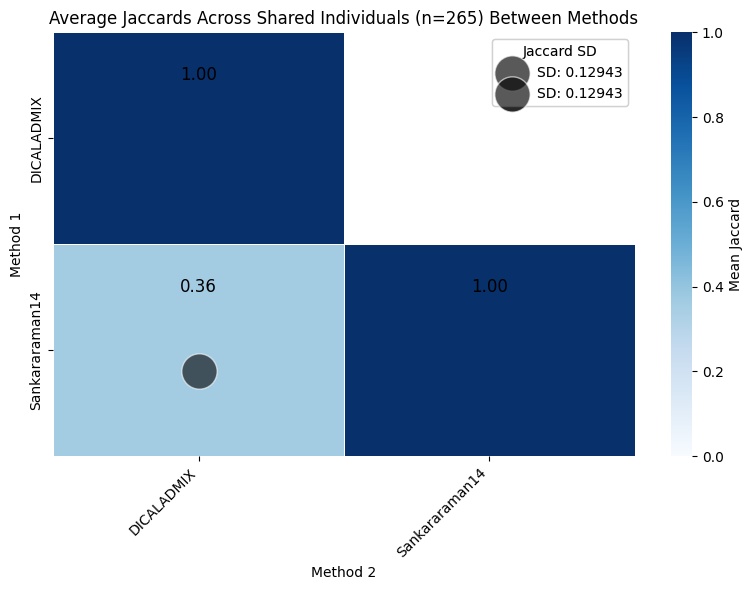

In [ ]:
tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/ibdmix_archaicseeker2_archie_dicaladmix_sstar_sankararaman14_jaccard_x_only.tsv',
    title='Average Jaccards Across Shared Individuals (n=265) Between Methods',
    color='Blues',
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/figures/ibdmix_archaicseeker2_archie_dicaladmix_sstar_sankararaman14_jaccard_x_only.svg'
)

### 271 CEU and CHBS individuals

see /wynton/home/capra/ychen39/introgression_methods/introgression_tools/bin/job_scripts/CEU_CHBS_individual_jaccard/CEU_CHBS_individual_jaccard.sh.

In [60]:
len(heatmap_data)

271

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2944: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


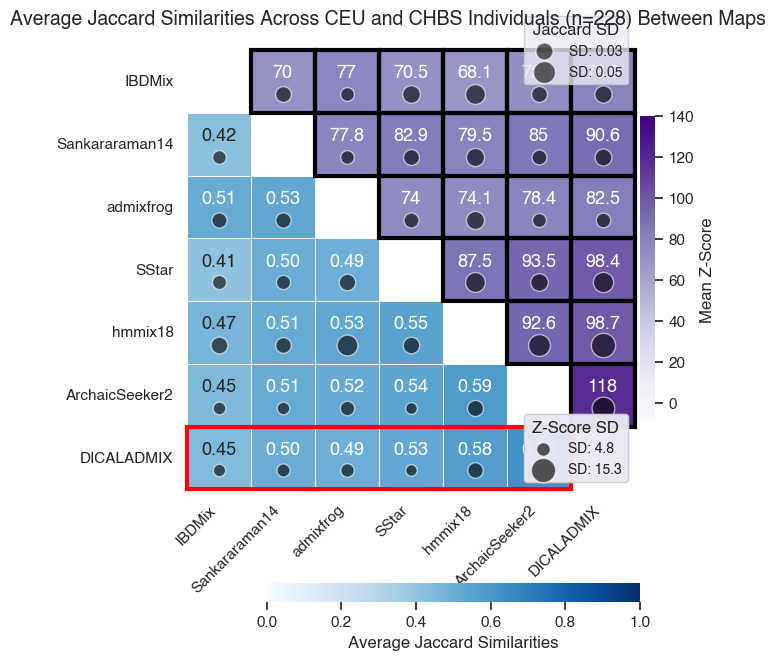

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  spine.set_color("black")
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3265: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  spine.set_linewidth(1)


DICALADMIX


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # rename the x-axis labels using rename_dict
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([rename_dict.get(label, label) for label in axs[0].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3314: UserWarning: set_ticklabels() should only be used with

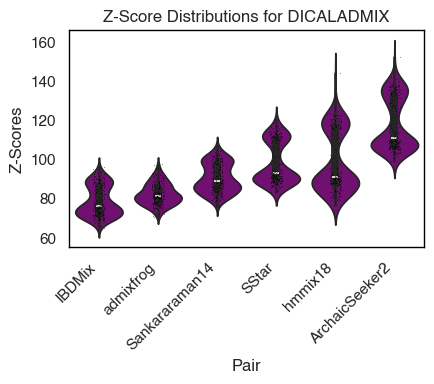

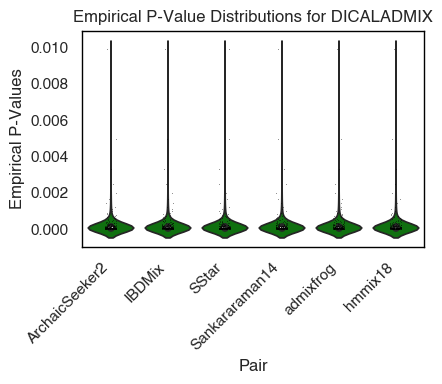

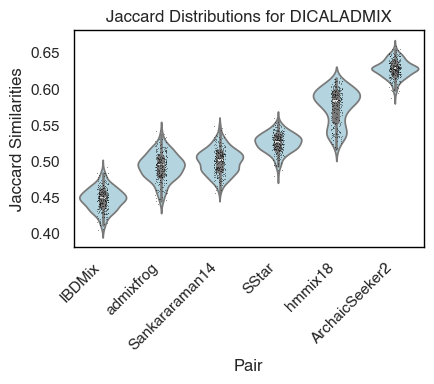

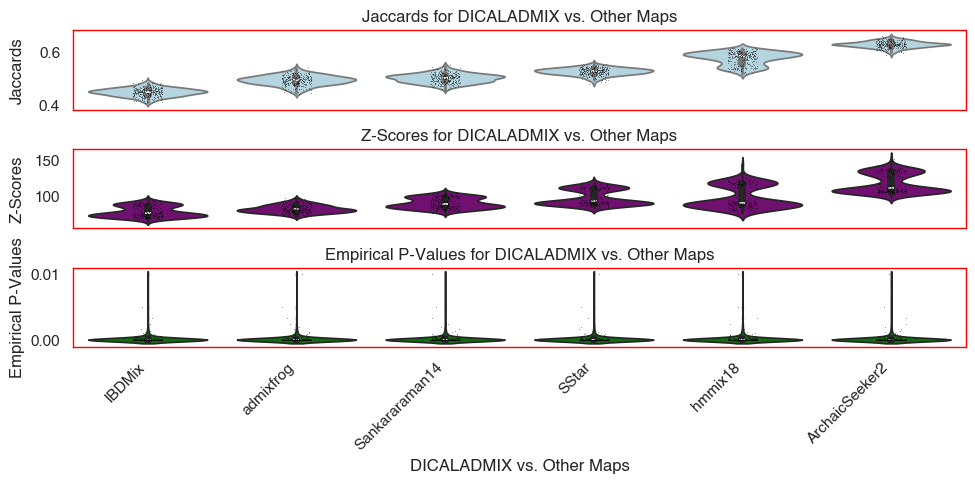

In [83]:
import pickle as pkl
heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/heatmap_data_observed.pkl', 'rb'))


tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Z_Scores',
    empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Empirical_P_Values',
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Jaccards',
    color='Blues',
    sd_sizes=[0.03, 0.05],
    title = 'Average Jaccard Similarities Across CEU and CHBS Individuals (n=228) Between Maps',
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/CEU_CHBS/CEU_CHBS_individual.svg',
    zscore_range_cmap = (-10, 140)
)


### Other groupings: 1 SGDP individual, 228 SGDP individuals, African SGDP individuals (admixed and not-admixed)

### 1 SGDP Papuan individual

In [30]:
# read in all the data
# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
SARGE_individual.rename(columns={'#chrom': 'Chromosome',
                                'start': 'Start',
                                'end': 'End',
                                'len': 'length',
                                'score': 'Score'}, inplace=True)

# remove prefix and suffix
SARGE_individual['ID'] = SARGE_individual['hap'].apply(lambda x: '_'.join(x.split('_')[1:]))
SARGE_individual['ID'] = SARGE_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# remove prefix and suffix
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

archaicseeker2_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/individual_nean_yuan2021_frag.bed', sep='\t', low_memory=False)
archaicseeker2_individual['ID'] = archaicseeker2_individual['ID'].str.split('_').str[0]

argweaverd_individual_papuan=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/papuan_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_khomani_san=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/khomani_san_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_mandenka=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/mandenka_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual = pd.concat([argweaverd_individual_papuan, argweaverd_individual_khomani_san, argweaverd_individual_mandenka])
argweaverd_individual['ID'] = argweaverd_individual['ID'].replace(SGDP_metadata_dict) # remap IDs

sankararaman16_1_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))
sankararaman16_2_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))


In [13]:
hmmix18_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/individual_nean_skov2018_frag.bed', sep='\t', low_memory=False)
'Papuan-1' in hmmix18_individual['ID'].unique()

False

In [18]:
# check if papuan is in hmmix18_individual IDs, even if just part of the ID

'Papuan' in hmmix18_individual['ID'].unique()

False

In [90]:
# all sgdp: 1 papuan individual shared
df_dict = {'SARGE':SARGE_individual, 
            'ARGWeaver-D':argweaverd_individual,
            'ArchaicSeeker2':archaicseeker2_individual,
            'Sankararaman16_1':sankararaman16_1_individual,
            'Sankararaman16_2':sankararaman16_2_individual,
            'admixfrog':admixfrog_individual,
            }

# compute jaccards
heatmap_data=tools.individual_jaccard_comparison(dfs_dict = df_dict,
                              temp_dir=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/', 
                              output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/1_papuan.tsv',
                              return_heatmap=True,
                              autosomes_only=True,
                              paired_shuffled_match=True,
                              genome_file = f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes_no_prefix.bed',
                              x_only=False)

['SARGE', 'ARGWeaver-D', 'ArchaicSeeker2', 'Sankararaman16_1', 'Sankararaman16_2', 'admixfrog'] : 1 individuals shared,  ['Papuan-1']
Computed shuffled for Papuan-1


In [9]:
df

,Pair,ID,Jaccards,Z_Scores,Empirical_P_Values,Name1,Name2
0,SARGE:SARGE,Papuan-1,1.000000,0.000000,1.000000,SARGE,SARGE
1,ARGweaver-D:SARGE,Papuan-1,0.280805,74.078046,0.009901,ARGweaver-D,SARGE
2,ArchaicSeeker2:SARGE,Papuan-1,0.342284,70.869482,0.009901,ArchaicSeeker2,SARGE
3,CRF16_1:SARGE,Papuan-1,0.373630,67.599202,0.009901,CRF16_1,SARGE
4,CRF16_2:SARGE,Papuan-1,0.303719,47.725958,0.009901,CRF16_2,SARGE
5,admixfrog:SARGE,Papuan-1,0.316854,51.327826,0.009901,admixfrog,SARGE
6,SARGE:ARGweaver-D,Papuan-1,0.280805,74.078046,0.009901,SARGE,ARGweaver-D
7,ARGweaver-D:ARGweaver-D,Papuan-1,1.000000,0.000000,1.000000,ARGweaver-D,ARGweaver-D
8,ArchaicSeeker2:ARGweaver-D,Papuan-1,0.403813,55.108861,0.009901,ArchaicSeeker2,ARGweaver-D
9,CRF16_1:ARGweaver-D,Papuan-1,0.339538,50.359942,0.009901,CRF16_1,ARGweaver-D


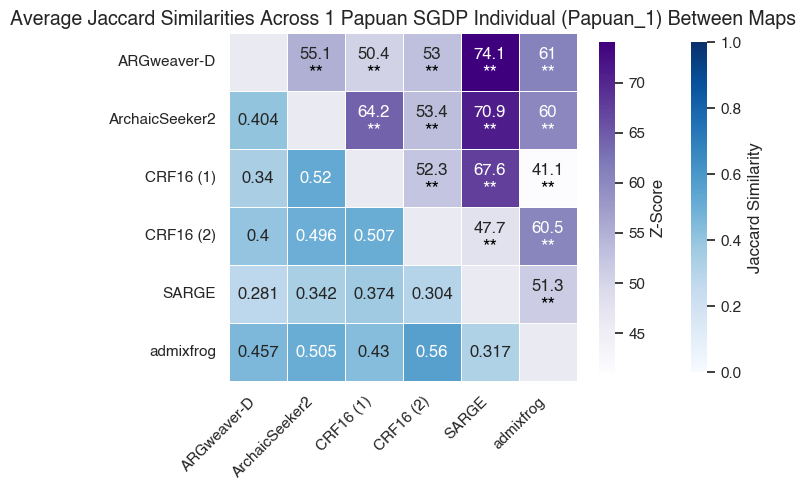

In [24]:
heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/1_Papuan/heatmap_data_observed.pkl', 'rb'))

heatmap_data=heatmap_data,
tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/1_Papuan/Jaccards'
z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/1_Papuan/Z_Scores'
empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/1_Papuan/Empirical_P_Values'
color='Blues'
title = 'Average Jaccard Similarities Across 1 Papuan SGDP Individual (Papuan_1) Between Maps'
save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/1_Papuan.svg'


df = heatmap_data[0]
jaccard_df = pd.read_csv(tsv, sep='\t', low_memory=False)
z_df = pd.read_csv(z_scores, sep='\t', low_memory=False)
pval_df = pd.read_csv(empirical_p_values, sep='\t', low_memory=False)

# split pair column into two columns, rename, and rejoin
z_df['Map1'], z_df['Map2'] = zip(*z_df['Pair'].map(lambda x: x.split(':')))
pval_df['Map1'], pval_df['Map2'] = zip(*pval_df['Pair'].map(lambda x: x.split(':')))
jaccard_df['Map1'], jaccard_df['Map2'] = zip(*jaccard_df['Pair'].map(lambda x: x.split(':')))
# rename using rename_dict
z_df['Map1'] = z_df['Map1'].map(lambda x: rename_dict.get(x, x)).fillna(z_df['Map1'])
z_df['Map2'] = z_df['Map2'].apply(lambda x: rename_dict.get(x, x)).fillna(z_df['Map2'])
jaccard_df['Map1'] = jaccard_df['Map1'].apply(lambda x: rename_dict.get(x, x)).fillna(jaccard_df['Map1'])
pval_df['Map1'] = pval_df['Map1'].apply(lambda x: rename_dict.get(x, x)).fillna(pval_df['Map1'])
pval_df['Map2'] = pval_df['Map2'].apply(lambda x: rename_dict.get(x, x)).fillna(pval_df['Map2'])
jaccard_df['Map2'] = jaccard_df['Map2'].apply(lambda x: rename_dict.get(x, x)).fillna(jaccard_df['Map2'])
# rejoin
z_df['Pair'] = z_df['Map1'] + ':' + z_df['Map2']
pval_df['Pair'] = pval_df['Map1'] + ':' + pval_df['Map2']
jaccard_df['Pair'] = jaccard_df['Map1'] + ':' + jaccard_df['Map2']
# drop helper columns
z_df = z_df.drop(columns=['Map1', 'Map2'])
pval_df = pval_df.drop(columns=['Map1', 'Map2'])
jaccard_df = jaccard_df.drop(columns=['Map1', 'Map2'])

# merge dataframes
df = (
    jaccard_df
    .merge(z_df, on=['Pair', 'ID'], how='left')
    .merge(pval_df, on=['Pair', 'ID'], how='left')
)

# split pair
df['Name1'], df['Name2'] = zip(*df['Pair'].map(lambda x: x.split(':')))

# get method order (no clustering for single case)
ordered_samples = sorted(set(df['Name1']).union(df['Name2']))

# Build matrices
jaccard_data = df.pivot(index='Name1', columns='Name2', values='Jaccards').loc[ordered_samples, ordered_samples]
zscore_data  = df.pivot(index='Name1', columns='Name2', values='Z_Scores').loc[ordered_samples, ordered_samples]
pval_data    = df.pivot(index='Name1', columns='Name2', values='Empirical_P_Values').loc[ordered_samples, ordered_samples]

# make symmetric
jaccard_data = jaccard_data.where(~jaccard_data.isna(), jaccard_data.T)
zscore_data  = zscore_data.where(~zscore_data.isna(), zscore_data.T)
pval_data    = pval_data.where(~pval_data.isna(), pval_data.T)

# masks
jaccard_lower = jaccard_data.mask(np.triu(np.ones(jaccard_data.shape), k=0).astype(bool))
zscore_upper  = zscore_data.mask(np.tril(np.ones(zscore_data.shape), k=0).astype(bool))

# Plot
plt.figure(figsize=(7, 7))
ax = plt.gca()

# lower triangle: Jaccard
sns.heatmap(
    jaccard_lower,
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".3g",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Jaccard Similarity", "shrink": 0.5},
    ax=ax
)

# upper triangle: Z-score
sns.heatmap(
    zscore_upper,
    cmap="Purples",
    annot=True,
    fmt=".3g",
    linewidths=0.5,
    annot_kws={"va":"bottom"},
    cbar_kws={"label": "Z-Score", "shrink": 0.5},
    ax=ax
)

# p-value significance, add asterisks (same color as the kannot)
for i in range(pval_data.shape[0]):
    for j in range(pval_data.shape[1]):
        if i < j:  # upper triangle
            color = 'white' if zscore_data.iat[i, j] > 60 else 'black'
            pval = pval_data.iat[i, j]
            if pd.notna(pval):
                if pval < 0.01:
                    ax.text(j + 0.5, i + 0.7, '**', color=color, ha='center', va='center', fontsize=14)
                elif pval < 0.05:
                    ax.text(j + 0.5, i + 0.7, '*', color=color, ha='center', va='center', fontsize=14)

plt.title(title, fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.savefig(save_plot_path, dpi=300)
plt.show()

/tmp/ipykernel_3874757/3504315171.py:7: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.


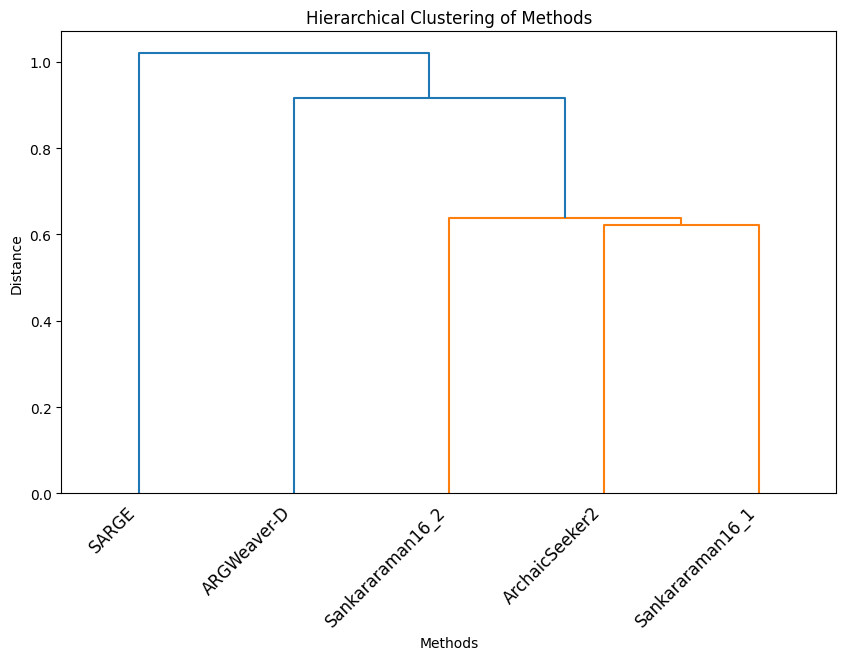

In [ ]:
df= pd.concat(heatmap_data).groupby(level=0).mean()

df_reordered = df.reindex(columns=df.columns, index=df.columns)

distance_matrix = 1 - df_reordered
# Perform hierarchical clustering using complete linkage
Z = linkage(distance_matrix, method='complete')

leaf_order = leaves_list(Z)

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df_reordered.columns, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering of Methods')
plt.xlabel('Methods')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')
#pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/clustering.png', dpi=300, bbox_inches='tight')
plt.show()

### 224 SGDP Individuals

In [217]:
# read in all the data
# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
SARGE_individual.rename(columns={'#chrom': 'Chromosome',
                                'start': 'Start',
                                'end': 'End',
                                'len': 'length',
                                'score': 'Score'}, inplace=True)

# remove prefix and suffix
SARGE_individual['ID'] = SARGE_individual['hap'].apply(lambda x: '_'.join(x.split('_')[1:]))
SARGE_individual['ID'] = SARGE_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# remove prefix and suffix
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

sankararaman16_1_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))
sankararaman16_2_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2946: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


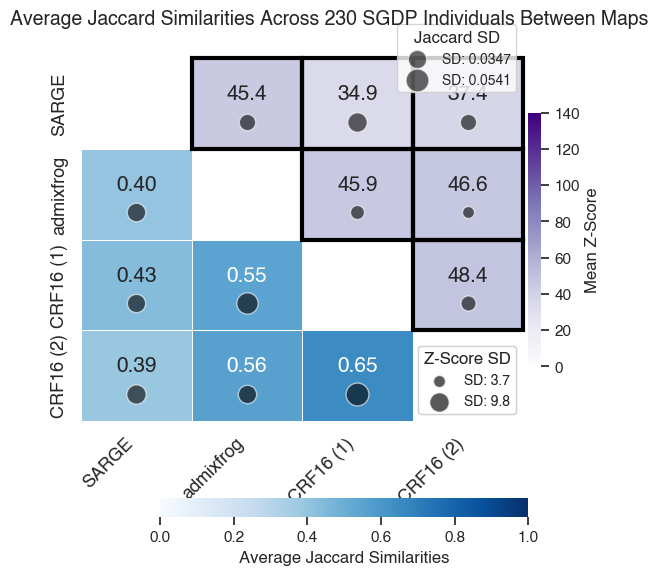

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3267: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')


CRF16 (2)


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([rename_dict.get(label, label) for label in axs[0].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([rename_dict.get(label, label) for label in axs[1].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3297: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels([rename_dict.get(label, label) for label in axs[2].get_xticklabels()])
/wynton/home/cap

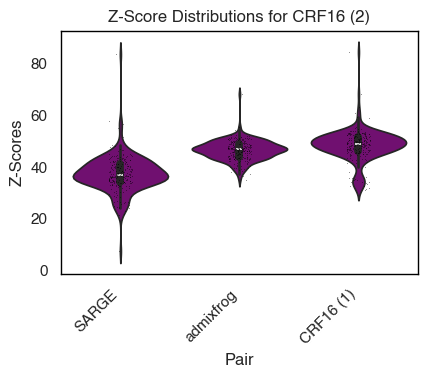

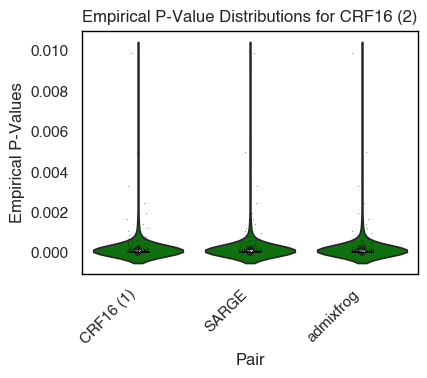

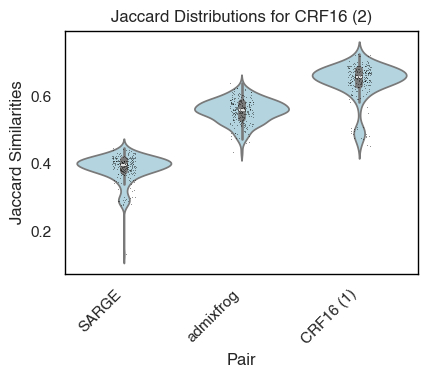

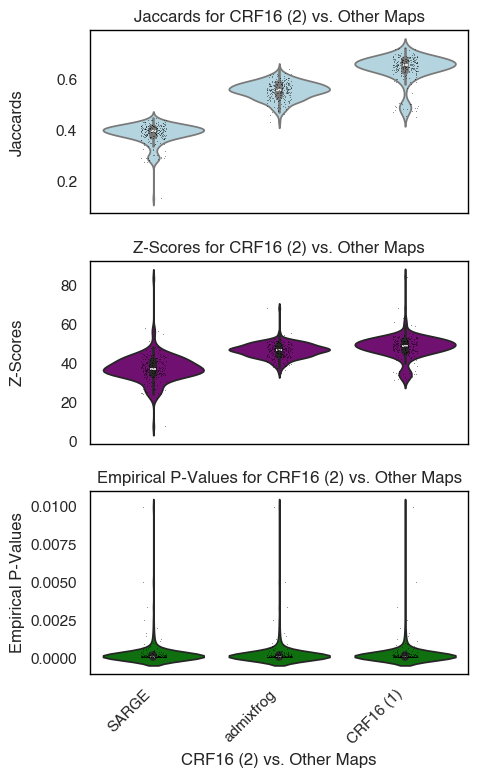

In [226]:
import pickle as pkl
heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/heatmap_data_observed.pkl', 'rb'))


tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Jaccards',
    z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Z_Scores',
    empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Empirical_P_Values',
    color='Blues',
    title = 'Average Jaccard Similarities Across 230 SGDP Individuals Between Maps',
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/230_SGDP/230_SGDP.svg',
    font_size=15,
    figsize_tuple=(6, 6),
    zscore_range_cmap=(0, 140),

)

### 15 Papuan individuals - Violin plot

In [29]:
# # read in all the data
# SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
# SARGE_individual.rename(columns={'#chrom': 'Chromosome',
#                                 'start': 'Start',
#                                 'end': 'End',
#                                 'len': 'length',
#                                 'score': 'Score'}, inplace=True)

# archaicseeker2_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/individual_nean_yuan2021_frag.bed', sep='\t', low_memory=False)
# archaicseeker2_individual['ID'] = archaicseeker2_individual['ID'].str.split('_').str[0]

# sankararaman16_1_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
# sankararaman16_1_individual['ID'] = sankararaman16_1_individual['ID'].str.split('_').str[1].str.split('-').str[:2].str.join('-')
# sankararaman16_2_individual=pd.read_csv(f"{HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/sgdp_individual_neanderthal_introgressed_fragments_pops.bed", sep='\t', low_memory=False)
# sankararaman16_2_individual['ID'] = sankararaman16_2_individual['ID'].str.split('_').str[1].str.split('-').str[:2].str.join('-')

# # make a dictionary to get from Illumina_ID to SGDP_ID
# SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
# SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID.str.split('_').str[1]))

# SARGE_individual['ID'] = SARGE_individual['hap'].str.split('_').str[1].str.split('-').str[:2].str.join('-') # create ID column by removing the prefix and the 2 chromosomes id at the end

# admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# # remove prefix from IDs
# admixfrog_individual['ID'] = [ID.split('_')[1] if '-' in ID else ID for ID in admixfrog_individual['ID']]

# one papuan individual
dfs_dict = {'SARGE':SARGE_individual, 
            'ArchaicSeeker2':archaicseeker2_individual,
            'CRF16_1':sankararaman16_1_individual,
            'CRF16_2':sankararaman16_2_individual,
            'admixfrog':admixfrog_individual,
            }

# check shared IDS
heatmap_data=tools.individual_jaccard_comparison(dfs_dict = dfs_dict,
                              autosomes_only=True,
                              x_only=False,
                              temp_dir=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/tmp', 
                              output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/sarge_sankararaman16_jaccard.tsv',
                              return_heatmap=True)

['SARGE', 'ArchaicSeeker2', 'CRF16_1', 'CRF16_2', 'admixfrog'] : 14 individuals shared,  ['Papuan-1', 'Papuan-10', 'Papuan-11', 'Papuan-13', 'Papuan-14', 'Papuan-15', 'Papuan-2', 'Papuan-3', 'Papuan-4', 'Papuan-5', 'Papuan-6', 'Papuan-7', 'Papuan-8', 'Papuan-9']


In [30]:
admixfrog_individual

,Chromosome,Start,End,ID,Score,superpopulation,Ancestry,ScoreName,IntrogressionSource,Method,GenomesSource
0,1,208857936,209333043,Australian-3,0.192113,Oceania,Oceania,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
1,1,85957145,86938072,Australian-3,0.216852,Oceania,Oceania,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
2,1,225862536,226133689,Australian-3,0.211957,Oceania,Oceania,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
3,1,45762502,46898359,Australian-3,0.200729,Oceania,Oceania,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
4,1,222283081,222716842,Australian-3,0.218816,Oceania,Oceania,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
...,...,...,...,...,...,...,...,...,...,...,...
868107,22,30790832,30954401,NA21144,0.212179,SAS,SAS,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
868108,22,20776728,20938717,NA21144,0.195521,SAS,SAS,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
868109,22,23286784,23394447,NA21144,0.134617,SAS,SAS,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP
868110,22,27670182,27681586,NA21144,0.207055,SAS,SAS,"nscore, numerical score giving certainty of se...",Neanderthal,"Admixfrog, Peter 2020",1KG and SGDP


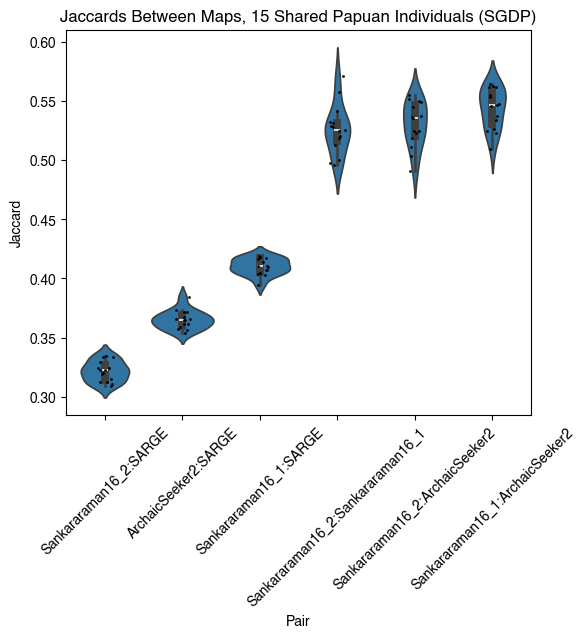

In [2]:
# load precomputed jaccard data
sarge_archaicseeker2_sankararaman16_jaccard=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/sarge_archaicseeker2_sankararaman16_jaccard.tsv', sep='\t', low_memory=False)

# calculate average values for each category
avg_values = sarge_archaicseeker2_sankararaman16_jaccard.groupby('Pair')['Jaccard'].mean().sort_values()

# order categories by average values
ordered_categories = avg_values.index

plt.figure(figsize=(6, 5))
sns.violinplot(data=sarge_archaicseeker2_sankararaman16_jaccard, x='Pair', y='Jaccard', order=ordered_categories)
# Overlay a strip plot with jitter
sns.stripplot(data=sarge_archaicseeker2_sankararaman16_jaccard, x='Pair', y='Jaccard', jitter=True, color='black', size=2, order=ordered_categories)

plt.xticks(rotation=45)
plt.title('Jaccards Between Maps, 15 Shared Papuan Individuals (SGDP)')

pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/15_shared_papuan.svg', bbox_inches='tight')
plt.show()

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2944: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


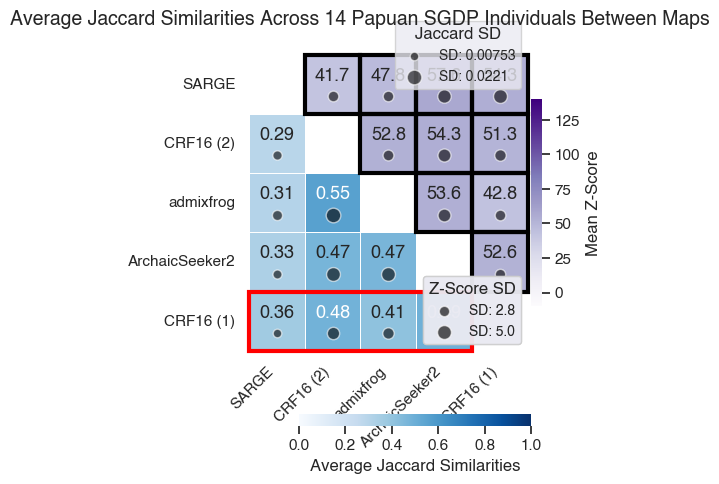

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  spine.set_color("black")
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3265: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  spine.set_linewidth(1)


CRF16 (1)


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # rename the x-axis labels using rename_dict
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([rename_dict.get(label, label) for label in axs[0].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3314: UserWarning: set_ticklabels() should only be used with

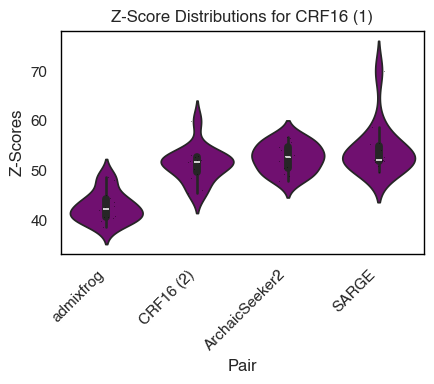

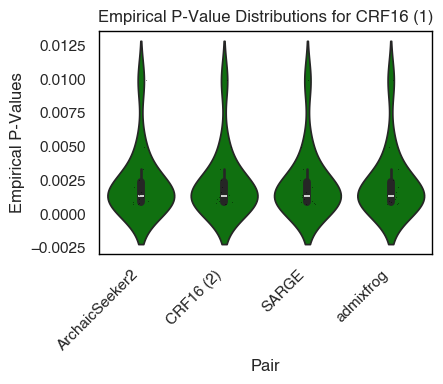

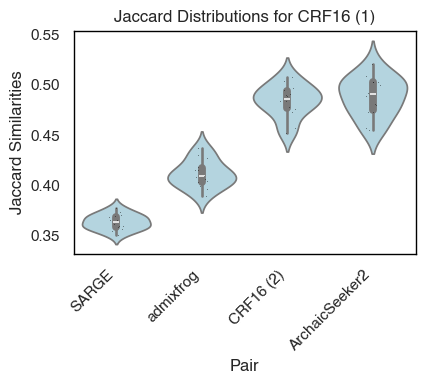

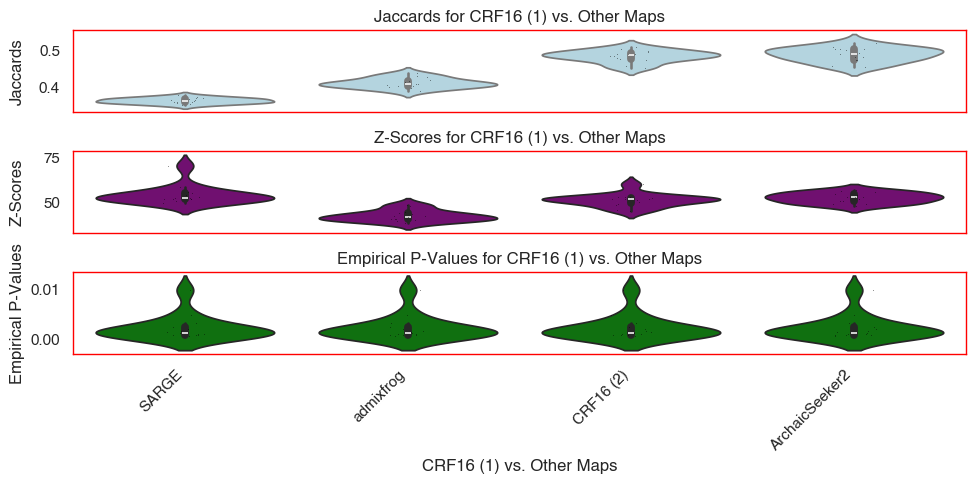

In [82]:
heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/heatmap_data_observed.pkl', 'rb'))

tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Jaccards',
    z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Z_Scores',
    empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Empirical_P_Values',
    color='Blues',
    title = 'Average Jaccard Similarities Across 14 Papuan SGDP Individuals Between Maps',
    figsize_tuple=(5,5),
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/14_Papuan/14_Papuan.svg',
    zscore_range_cmap = (-10, 140)
)

In [53]:
z_df = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Z_Scores', sep='\t', low_memory=False)

z_df['Pair'] = z_df['Pair'].apply(lambda x: ':'.join(sorted([tools.rename_dict.get(name, name) for name in x.split(':')])))
z_subset_df = z_df[z_df['Pair'].str.contains('CRF16 (1)', na=False, regex=False)]
z_subset_df

,Pair,ID,Z_Scores
2,CRF16 (1):SARGE,Papuan-1,63.495706
7,ArchaicSeeker2:CRF16 (1),Papuan-1,59.913179
10,CRF16 (1):SARGE,Papuan-1,63.495706
11,ArchaicSeeker2:CRF16 (1),Papuan-1,59.913179
12,CRF16 (1):CRF16 (1),Papuan-1,0.000000
...,...,...,...
337,CRF16 (1):CRF16 (1),Papuan-9,0.000000
338,CRF16 (1):CRF16 (2),Papuan-9,48.314729
339,CRF16 (1):admixfrog,Papuan-9,39.791666
342,CRF16 (1):CRF16 (2),Papuan-9,48.314729


### African individuals between ARGweaver-D, SARGE, admixfrog

In [4]:
# read in all the data
SARGE_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/sarge_schaefer2021/sarge_admixed_haps_hs37d5.bed', sep='\t', low_memory=False)
SARGE_individual.rename(columns={'#chrom': 'Chromosome',
                                'start': 'Start',
                                'end': 'End',
                                'len': 'length',
                                'score': 'Score'}, inplace=True)

# remove prefix and suffix
SARGE_individual['ID'] = SARGE_individual['hap'].apply(lambda x: '_'.join(x.split('_')[1:]))
SARGE_individual['ID'] = SARGE_individual['ID'].apply(lambda x: '-'.join(x.split('-')[:2]))

# make a dictionary to get from Illumina_ID to SGDP_ID
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
SGDP_metadata_dict = dict(zip(SGDP_metadata.Illumina_ID, SGDP_metadata.SGDP_ID))

admixfrog_individual=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/individual_iasi_2024_introgressed_frag.bg', sep='\t', low_memory=False)
# remove prefix from IDs
admixfrog_individual['ID'] = admixfrog_individual['ID'].apply(lambda x: '_'.join(x.split('_')[1:]) if '-' in x else x)

#argweaverd_individual_papuan=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/papuan_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_khomani_san=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/khomani_san_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual_mandenka=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/mandenka_individual_nean_hubisz2020_frag.bed', sep='\t', low_memory=False)
argweaverd_individual = pd.concat([argweaverd_individual_khomani_san, argweaverd_individual_mandenka])
argweaverd_individual['ID'] = argweaverd_individual['ID'].replace(SGDP_metadata_dict) # remap IDs

# one papuan individual
dfs_dict = {'SARGE':SARGE_individual, 
            'argweaverd':argweaverd_individual,
            'admixfrog':admixfrog_individual,
            }

# check shared IDS
heatmap_data=tools.individual_jaccard_comparison(dfs_dict = dfs_dict,
                              autosomes_only=True,
                              x_only=False,
                              temp_dir=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/tmp', 
                              output_jaccards_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/test.tsv',
                              return_heatmap=True)

['SARGE', 'argweaverd', 'admixfrog'] : 2 individuals shared,  ['Khomani_San-1', 'Mandenka-2']


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2943: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


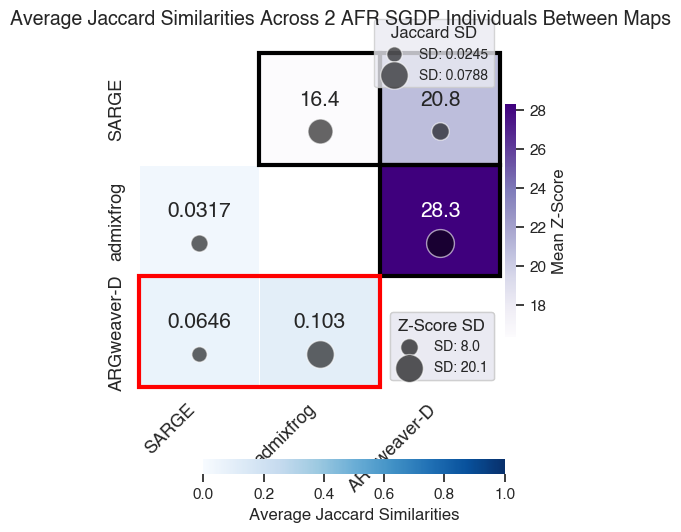

['SARGE:SARGE' 'admixfrog:SARGE' 'ARGweaver-D:SARGE' 'SARGE:admixfrog'
 'admixfrog:admixfrog' 'ARGweaver-D:admixfrog' 'SARGE:ARGweaver-D'
 'admixfrog:ARGweaver-D' 'ARGweaver-D:ARGweaver-D']


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3204: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3240: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rename_dict.get(label, label) for label in ax.get_xticklabels()], rotation=45, ha='right')


ARGweaver-D


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3268: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([rename_dict.get(label, label) for label in axs[0].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3269: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([rename_dict.get(label, label) for label in axs[1].get_xticklabels()])
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:3270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels([rename_dict.get(label, label) for label in axs[2].get_xticklabels()])
/wynton/home/cap

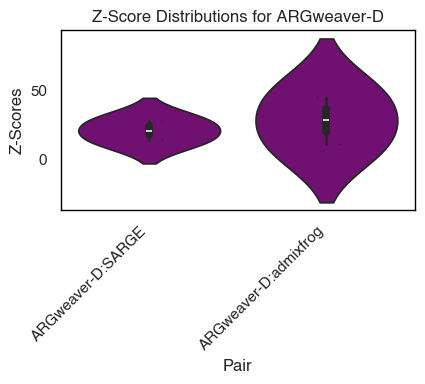

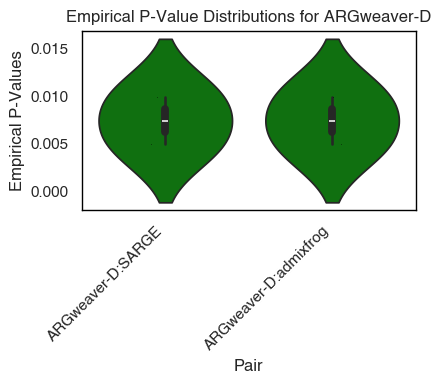

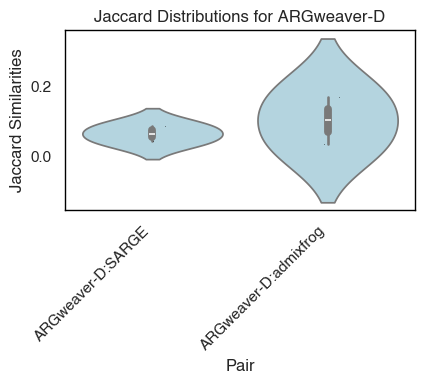

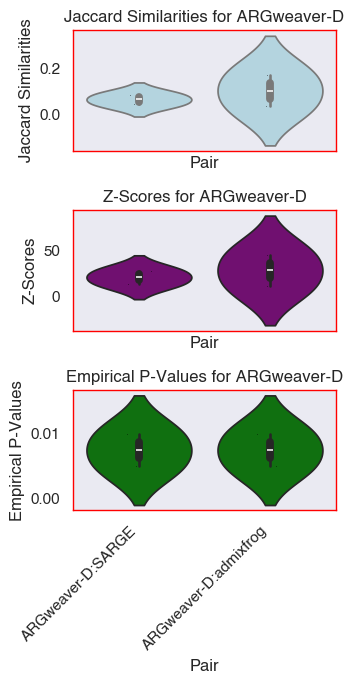

In [5]:
heatmap_data = pkl.load(open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/heatmap_data_observed.pkl', 'rb'))

tools.individual_jaccard_comparison_dot_heatmap(
    heatmap_data=heatmap_data,
    tsv=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Jaccards',
    z_scores=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Z_Scores',
    empirical_p_values=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Empirical_P_Values',
    color='Blues',
    font_size=15,
    figsize_tuple=(5, 5.5),
    title = 'Average Jaccard Similarities Across 2 AFR SGDP Individuals Between Maps',
    save_plot_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/individual_comparison/AFR_jaccard/AFR.svg',
)

In [9]:
# calculate average raw jaccard values across individuals for each method pair
jaccards = [0.23, 0.17, 0.18, 0.015, 0.013, 0.014]

print('Mean:', np.mean(jaccards))

print('Standard Deviation:', np.std(jaccards))

Mean: 0.10366666666666668
Standard Deviation: 0.09156903892085408


### African individuals (including admixed individuals)

In [26]:
# create overlap file
tools.combine_pop_files([f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/merged_Africa.bg', 
                   f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/merged_Africa2.bg'],
                   output_dir=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/',
                   output_file='african_introgressed.bed')

african_boolean_overlap = tools.generate_overlap(input_files_string=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/afr_with_admix.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/merged_Africa.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/afr_with_admix_sorted.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/african_introgressed.bg',
                                           input_files_names_str='IBDMix ARGweaver-D admixfrog SARGE',
                                           output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/african_overlap.bed',
                                           boolean=True, autosomes=True)
african_boolean_overlap

save_df=african_boolean_overlap.drop(['length'], axis=1)

save_df.to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/african_boolean_overlap.bg', sep='\t',
                                        index=False)

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

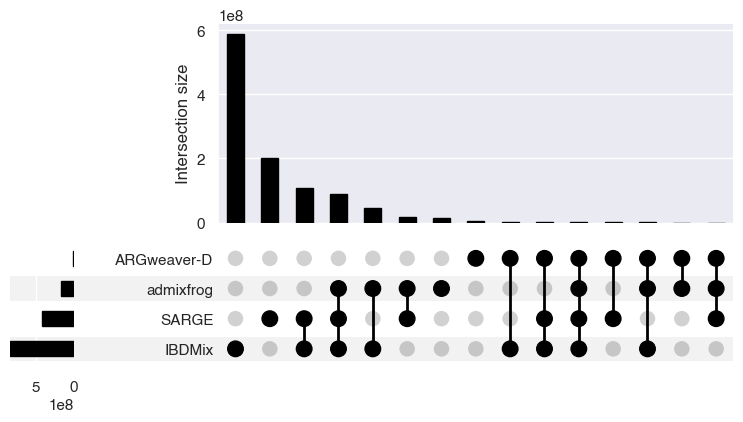

In [184]:
african_boolean_overlap_upset=african_boolean_overlap.drop(['chrom', 'start', 'end'], axis=1)
plot(from_indicators(['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'], data=african_boolean_overlap_upset), sum_over="length", subset_size="sum", sort_by="cardinality")

In [189]:
# heatmap_data=tools.plot_jaccard(boolean_df=african_boolean_overlap[african_boolean_overlap['chrom']!='X'],
#              categories_list=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
#              value_column='length',
#              type='combined',
#              color='Reds',
#              leaf_order=True,
#              combined_title = 'Jaccards for African Introgressed Base-Pairs',
#              save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/AFR_sarge_ibdmix_admixfrog_argweaverd_admixed.svg')


tools.compute_jaccard_combined_with_shuffles(
    file_paths=['/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/li_2024/afr_with_admix.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/merged_Africa.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/iasi_2024/afr_with_admix_sorted.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/schaefer_2021/african_introgressed.bg'],
    algorithms=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
    shuffle_genome_file=f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes.bed',
    scratch_dir='/wynton/scratch/ychen39/tmp/',
    output_dir='/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/shuffle_comparison/AFR_with_admixed/',
    num_shuffles=100,
    autosomes=True
)

/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2059: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2096: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2210: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


Calculating normalized jaccard WITHOUT paired shuffled match
save


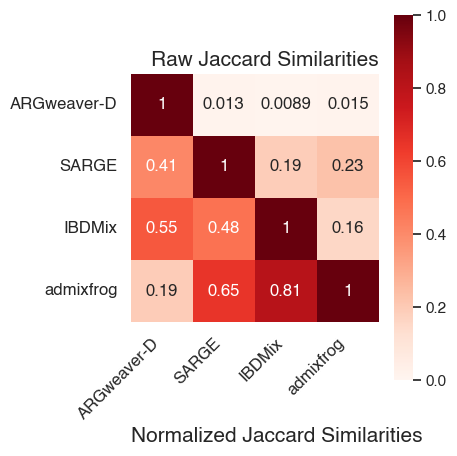

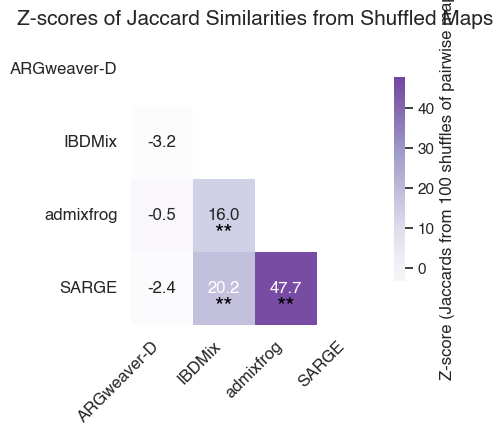

In [27]:
# plot the heatmap
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparison/AFR_with_admixed/shuffled_jaccard_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        

heatmap_data=tools.plot_jaccard(boolean_df=african_boolean_overlap,
                   # get this from the clustering order
                   categories_list=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
                    plot_size=(4,5),
                   value_column='length', 
                   type='combined',
                   leaf_order=True, 
                   font_size=12,
                   save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/AFR_with_admixed_jaccard_with_shuffles.svg',
                   rename_dict=rename_dict,
                   shuffles_tsv=distributions)

### African individuals - no admixed

In [3]:
# create overlap file again without AFR admixed individuals from IBDMix

african_boolean_overlap_no_admix = tools.generate_overlap(input_files_string=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/afr_no_admix.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/merged_Africa.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/afr_with_admix_sorted.bg \
                                                                {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/african_introgressed.bg',
                                           input_files_names_str='IBDMix ARGweaver-D admixfrog SARGE',
                                           output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/african_boolean_overlap_no_admix.bed',
                                           boolean=True, autosomes=True)

save_df=african_boolean_overlap_no_admix.drop(['length'], axis=1)

save_df.to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/african_boolean_overlap_no_admix.bg', sep='\t',
                                        index=False)

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

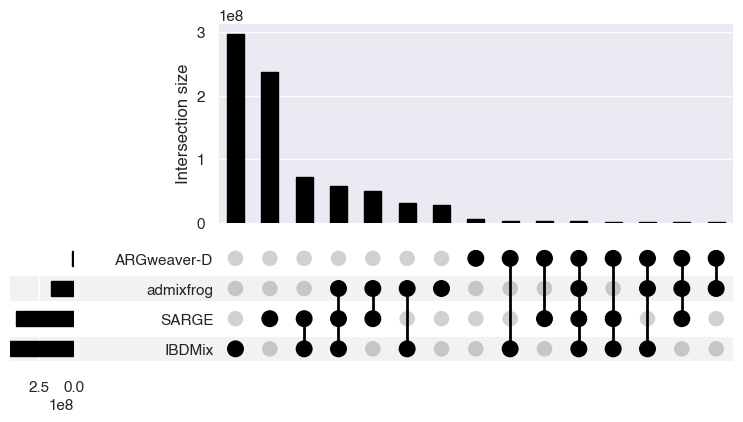

In [4]:
african_boolean_overlap_no_admix=african_boolean_overlap_no_admix.drop(['chrom', 'start', 'end'], axis=1)
plot(from_indicators(['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'], data=african_boolean_overlap_no_admix), sum_over="length", subset_size="sum", sort_by="cardinality")


Calculating normalized jaccard WITHOUT paired shuffled match
save


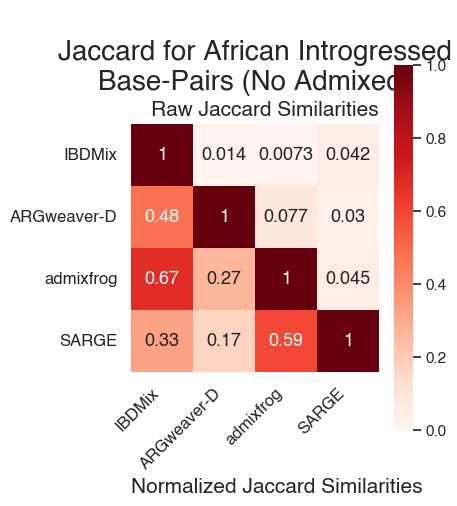

,IBDMix,ARGweaver-D,admixfrog,SARGE
IBDMix,1.0,0.013881,0.007325,0.041568
ARGweaver-D,0.476339,1.0,0.077448,0.03026
admixfrog,0.671933,0.266314,1.0,0.04476
SARGE,0.325011,0.168303,0.591003,1.0


In [29]:
tools.plot_jaccard(boolean_df=african_boolean_overlap_no_admix,
             categories_list=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
             value_column='length',
             type='combined',
             plot_size=(4,5),
             combined_title = 'Jaccard for African Introgressed Base-Pairs (No Admixed)',
             save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/AFR_sarge_ibdmix_admixfrog_argweaverd.svg')

In [7]:
tools.compute_jaccard_combined_with_shuffles(
    file_paths=['/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/li_2024/afr_no_admix.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/merged_Africa.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/iasi_2024/afr_with_admix_sorted.bg',
                '/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/schaefer_2021/african_introgressed.bg'],
    algorithms=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
    shuffle_genome_file=f'{HOMEDIR}/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes.bed',
    scratch_dir='/wynton/scratch/ychen39/afr_no_admix/',
    output_dir='/wynton/home/capra/ychen39/introgression_methods/cleaned/introgression_tools/shuffle_comparison/AFR_no_admixed/',
    num_shuffles=100,
    autosomes=True
)



/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2059: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2096: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (observed_value - mean_shuffled) / std_shuffled
/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2210: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


Calculating normalized jaccard WITHOUT paired shuffled match
save


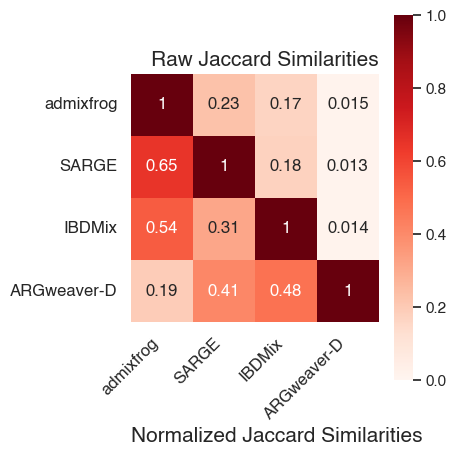

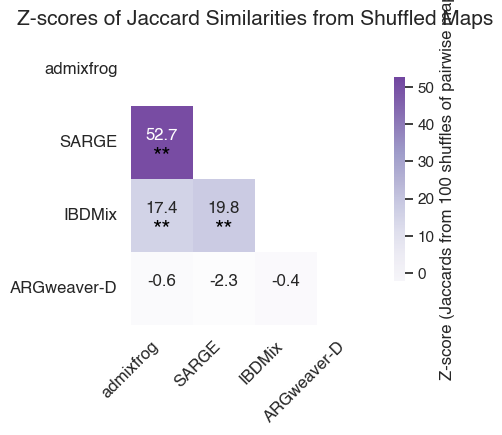

In [8]:
# plot the heatmap
distributions = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/shuffle_comparison/AFR_no_admixed/shuffled_jaccard_raw.tsv', sep='\t')
# rename columns, splitting by : for each column
for col in distributions.columns:
    if ':' in col:
        new_col_1 = col.split(':')[0]
        new_col_2 = col.split(':')[1]
        distributions = distributions.rename(columns={col: f'{rename_dict_dir.get(new_col_1, new_col_1)}:{rename_dict_dir.get(new_col_2, new_col_2)}'})
        

heatmap_data=tools.plot_jaccard(boolean_df=african_boolean_overlap_no_admix,
                   # get this from the clustering order
                   categories_list=['IBDMix', 'ARGweaver-D', 'admixfrog', 'SARGE'],
                   save_fig_path=f'{HOMEDIR}/introgression_methods/figures/introgression_tools/supplement/AFR_no_admixed_ibdmix_argweaverd_admixfrog_sarge.svg',
                   value_column='length', 
                   type='combined',
                   leaf_order=True,
                   font_size=12,
                   plot_size=(4,5),
                   rename_dict=rename_dict,
                   shuffles_tsv=distributions)

### African Jaccards vs others

In [5]:
import scipy.stats

# Jaccards, Z-scores, and empirical p-values with shared x axis for populations
# plot jaccards for AFR vs other populations in different subpanels, violin plots with different pairs of methods on X grouped by population
afr_z_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Z_Scores', sep='\t')
ceu_chbs_z_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Z_Scores', sep='\t')
papuan_z_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Z_Scores', sep='\t')
sgdp_224_z_scores = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Z_Scores', sep='\t')

afr_z_jaccards = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Jaccards', sep='\t')
ceu_chbs_z_jaccards = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Jaccards', sep='\t')
papuan_z_jaccards = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Jaccards', sep='\t')
sgdp_224_z_jaccards = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Jaccards', sep='\t')

afr_p_val = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/AFR_jaccard/Empirical_P_Values', sep='\t')
ceu_chbs_p_val = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/CEU_CHBS/Empirical_P_Values', sep='\t')
papuan_p_val = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/14_Papuan/Empirical_P_Values', sep='\t')
sgdp_224_p_val = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/individual_comparison/224_SGDP/Empirical_P_Values', sep='\t')

# merge all dataframes by ID and pair, new columns for z scores, jaccards, and p-values
jaccards = pd.concat([afr_z_jaccards, ceu_chbs_z_jaccards, papuan_z_jaccards, sgdp_224_z_jaccards], ignore_index=True)
z_scores = pd.concat([afr_z_scores, ceu_chbs_z_scores, papuan_z_scores, sgdp_224_z_scores], ignore_index=True)
p_values = pd.concat([afr_p_val, ceu_chbs_p_val, papuan_p_val, sgdp_224_p_val], ignore_index=True)

combined = jaccards.merge(z_scores, on=['ID', 'Pair'], suffixes=('_jaccard', '_z_score')).merge(p_values, on=['ID', 'Pair'])

# remap sgdp IDs to a population
SGDP_metadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/SGDP_metadata.279public.21signedLetter.44Fan.samples.txt', sep='\t', low_memory=False, encoding='unicode_escape')
SGDP_metadata['SGDP_ID'] = SGDP_metadata['SGDP_ID'].apply(lambda x: '_'.join(x.split('_')[1:]))
# remap 1KG IDs to a population
kgmetadata=pd.read_csv(f'{HOMEDIR}/introgression_methods/data/igsr_samples.tsv', sep='\t', low_memory=False)
kgmetadata_dict = dict(zip(kgmetadata['Sample name'], kgmetadata['Superpopulation code']))
SGDP_metadata_dict = dict(zip(SGDP_metadata.SGDP_ID, SGDP_metadata.Region))
# combine both dictionaries
SGDP_metadata_dict.update(kgmetadata_dict)
# replace
combined['Population'] = combined['ID'].replace(SGDP_metadata_dict)

# plot, group populations together
# split the Pair column into two columns, rename methods using tools.rename_dict, then sort the two method names alphabetically and join them back together
combined['Population'] = combined['Population'].apply(tools.map_status)
combined['Pair1'] = combined['Pair'].apply(lambda x: tools.rename_dict.get(x.split(':')[0], x.split(':')[0]))
combined['Pair2'] = combined['Pair'].apply(lambda x: tools.rename_dict.get(x.split(':')[1], x.split(':')[1]))
# remove duplicates in pair 1 and 2
combined = combined[combined['Pair1'] != combined['Pair2']]
combined['Pair'] = combined.apply(lambda row: ':'.join(sorted([row['Pair1'], row['Pair2']])), axis=1)
# remove duplicates where Pair1:Pair2 and Pair2:Pair1 are the same
combined = combined.drop_duplicates(subset=['Pair', 'Population', 'ID'])

# compute mann whitney u test between population Jaccards for each AFR vs. other population pair
# skip AFR vs. itsself
for pair in combined['Pair'].unique():
    pair_data = combined[combined['Pair'] == pair]
    populations = pair_data['Population'].unique()
    for i in range(len(populations)):
        pop1 = 'AFR'
        pop2 = populations[i]
        pop1_data = pair_data[pair_data['Population'] == pop1]['Jaccards']
        pop2_data = pair_data[pair_data['Population'] == pop2]['Jaccards']
        if pop2 == 'AFR':
            continue
        else:
            u_stat, p_value = scipy.stats.mannwhitneyu(pop1_data, pop2_data)
            print(f'Pair: {pair}, Populations: {pop1} vs {pop2}, Mann-Whitney U p-value: {p_value}')

combined

Pair: SARGE:admixfrog, Populations: AFR vs Oceania, Mann-Whitney U p-value: 0.006153846153846154
Pair: SARGE:admixfrog, Populations: AFR vs EUR, Mann-Whitney U p-value: 0.000683526999316473
Pair: SARGE:admixfrog, Populations: AFR vs CentralAsia, Mann-Whitney U p-value: 0.005291005291005291
Pair: SARGE:admixfrog, Populations: AFR vs EAS, Mann-Whitney U p-value: 0.0017730496453900709
Pair: SARGE:admixfrog, Populations: AFR vs SAS, Mann-Whitney U p-value: 0.002564102564102564
Pair: SARGE:admixfrog, Populations: AFR vs AMR, Mann-Whitney U p-value: 0.007905138339920948
Pair: ArchaicSeeker2:DICALADMIX, Populations: AFR vs EAS, Mann-Whitney U p-value: nan
Pair: ArchaicSeeker2:DICALADMIX, Populations: AFR vs EUR, Mann-Whitney U p-value: nan
Pair: ArchaicSeeker2:SStar, Populations: AFR vs EAS, Mann-Whitney U p-value: nan
Pair: ArchaicSeeker2:SStar, Populations: AFR vs EUR, Mann-Whitney U p-value: nan
Pair: ArchaicSeeker2:Sankararaman14, Populations: AFR vs EAS, Mann-Whitney U p-value: nan
Pair:

/scratch/ychen39/ipykernel_1629032/2869131864.py:63: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_stat, p_value = scipy.stats.mannwhitneyu(pop1_data, pop2_data)


,Pair,ID,Jaccards,Z_Scores,Empirical_P_Values,Population,Pair1,Pair2
1,SARGE:admixfrog,Khomani_San-1,0.057658,30.356614,0.009901,AFR,admixfrog,SARGE
2,ARGweaver-D:SARGE,Khomani_San-1,0.085828,27.795070,0.009901,AFR,ARGweaver-D,SARGE
5,ARGweaver-D:admixfrog,Khomani_San-1,0.171104,45.717478,0.009901,AFR,ARGweaver-D,admixfrog
10,SARGE:admixfrog,Mandenka-2,0.005677,2.371018,0.044776,AFR,admixfrog,SARGE
11,ARGweaver-D:SARGE,Mandenka-2,0.043410,13.900846,0.004975,AFR,ARGweaver-D,SARGE
...,...,...,...,...,...,...,...,...
18657,CRF16 (2):SARGE,Zapotec-2,0.424507,38.405299,0.000043,AMR,CRF16 (2),SARGE
18658,SARGE:admixfrog,Zapotec-2,0.425244,46.271466,0.000043,AMR,admixfrog,SARGE
18661,CRF16 (1):CRF16 (2),Zapotec-2,0.679955,49.752969,0.000043,AMR,CRF16 (2),CRF16 (1)
18662,CRF16 (1):admixfrog,Zapotec-2,0.579457,48.038253,0.000043,AMR,admixfrog,CRF16 (1)


In [17]:
import scipy.stats
# compute mann whitney u test between population Jaccards
populations = combined['Population'].unique()
for i in range(len(populations)):
    pop1 = 'AFR'
    pop2 = populations[i]
    if pop2 == 'AFR':
        continue
    else:
        pop1_data = combined[combined['Population'] == pop1]['Jaccards']
        pop2_data = combined[combined['Population'] == pop2]['Jaccards']
        u_stat, p_value = scipy.stats.mannwhitneyu(pop1_data, pop2_data)
        # multiple testing correction using bonferroni
        p_value_corrected = p_value / 6
        if p_value_corrected > 0.001:
            print(f'Jaccard: Populations: {pop1} vs {pop2}, Mann-Whitney U p-value: {p_value_corrected}')

# repeat for z scores
for i in range(len(populations)):
    pop1 = 'AFR'
    pop2 = populations[i]
    if pop2 == 'AFR':
        continue
    else:
        pop1_data = combined[combined['Population'] == pop1]['Z_Scores']
        pop2_data = combined[combined['Population'] == pop2]['Z_Scores']
        u_stat, p_value = scipy.stats.mannwhitneyu(pop1_data, pop2_data)
        # multiple testing correction using bonferroni
        p_value_corrected = p_value / 6
        if p_value_corrected > 0.001:
            print(f'Z-scores: Populations: {pop1} vs {pop2}, Mann-Whitney U p-value: {p_value_corrected}')

/scratch/ychen39/ipykernel_2926473/2869726670.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend().remove()
/scratch/ychen39/ipykernel_2926473/2869726670.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend().remove()
/scratch/ychen39/ipykernel_2926473/2869726670.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/scratch/ychen39/ipykernel_2926473/2869726670.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


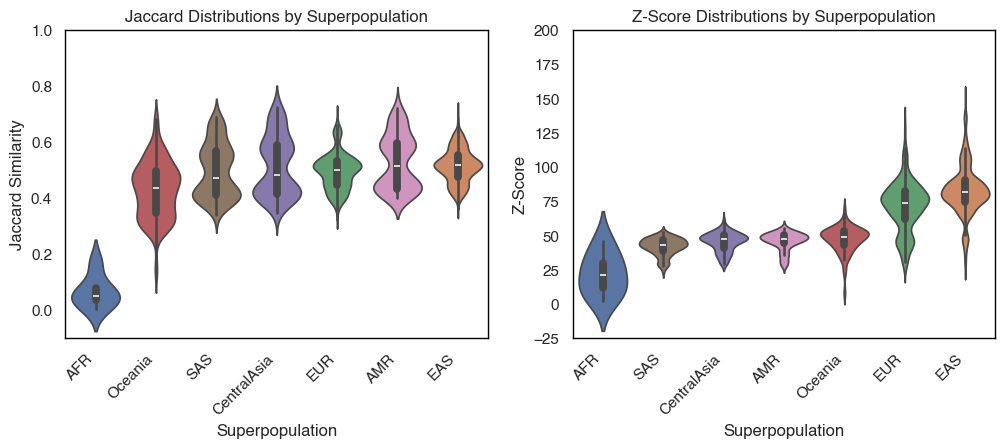

In [6]:
# combined plot with three subplots sharing x axis
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# first subplot: jaccards
# prevent tail extending less than 0
sns.violinplot(data=combined, x='Population', y='Jaccards', hue='Population', ax=axs[0],
               order=combined.groupby('Population')['Jaccards'].median().sort_values().index)
#sns.stripplot(data=combined, x='Population', y='Jaccards', hue='Population', color='black', size=1, alpha=0.5, ax=axs[0])
axs[0].set_title('Jaccard Distributions by Superpopulation')
axs[0].set_ylabel('Jaccard Similarity')
axs[0].legend().remove()
# second subplot: z scores
# sort by median z scores
sns.violinplot(data=combined, x='Population', y='Z_Scores', hue='Population', 
               ax=axs[1], order=combined.groupby('Population')['Z_Scores'].median().sort_values().index)
#sns.stripplot(data=combined, x='Population', y='Z_Scores', hue='Population', color='black', size=1, alpha=0.5, ax=axs[1])
axs[1].set_title('Z-Score Distributions by Superpopulation')
axs[1].set_ylabel('Z-Score')
axs[1].legend().remove()
# third subplot: p-values
# sns.violinplot(data=combined, x='Population', y='Empirical_P_Values', hue='Population', ax=axs[2])
#sns.stripplot(data=combined, x='Population', y='Empirical_P_Values', hue='Population', color='black', size=1, alpha=0.5, ax=axs[2])
# axs[2].set_title('Empirical P-Value Distributions by Superpopulation')
# axs[2].set_ylabel('Empirical P-Value')
# axs[2].legend().remove()
# remove background and add border
for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")
    ax.set_facecolor("none") # set transparent background

for ax in axs:
    ax.set_xlabel('Superpopulation')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# set ylim
axs[0].set_ylim(-0.1, 1)
axs[1].set_ylim(-25, 200)



plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/jaccard_zscore_distributions_by_population.svg', dpi=300, bbox_inches='tight')

## Deserts

#### Count number of fully supported regions

In [ ]:
# load in deserts
all_deserts = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/all_deserts.bed', sep='\t')

# replace 0s with NA, drop rows with NA
overlap_all_methods = all_deserts.replace(0, np.nan)
overlap_all_methods = all_deserts.dropna()
# separate bed only
overlap_all_methods_bed = overlap_all_methods[['chrom', 'start', 'end']]
# add 'chr' prefix
overlap_all_methods_bed['chrom']='chr'+overlap_all_methods_bed['chrom']

#overlap_all_methods_bed.to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts_all_methods_overlap.bed', sep='\t', index=False, header=False)

,chrom,start,end
227,chr3,78049151,79049150
229,chr3,80049150,84049151
321,chr7,106640445,107640445
323,chr7,110640056,113640055
325,chr7,116640054,123200000
346,chr8,54912560,55912560
348,chr8,56912559,57912559
350,chr8,58912559,64912557


#### Number of desert regions supported by 3 or 4 regions

In [ ]:
# load in deserts
all_deserts = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/all_deserts.bed', sep='\t')
# count methods supporting for each region
all_deserts['total'] = all_deserts['sankararaman_2016_1'] + all_deserts['skov_2020'] + all_deserts['chen_2020'] + all_deserts['vernot_2016'] + all_deserts['yuan_2021']

In [ ]:
# num regions supported by 4 methods
print(len(all_deserts[(all_deserts['total']==4)]))
# show the regions
all_deserts[(all_deserts['total']==4)]

13


,chrom,start,end,sankararaman_2016_1,skov_2020,chen_2020,vernot_2016,yuan_2021,total
26,1,105542622,109542622,1,1,1,1,0,4
28,1,110542622,114542622,1,1,1,1,0,4
226,3,77000000,78049151,1,0,1,1,1,4
228,3,79049150,80049150,1,0,1,1,1,4
230,3,84049151,89300000,1,0,1,1,1,4
320,7,106300000,106640445,1,0,1,1,1,4
322,7,107640445,110640056,1,0,1,1,1,4
324,7,113640055,116640054,1,0,1,1,1,4
326,7,123200000,124640054,1,1,0,1,1,4
345,8,54000000,54912560,1,0,1,1,1,4


In [ ]:
# num regions supported by 3 methods
print(len(all_deserts[(all_deserts['total']==3)]))
# show the regions
all_deserts[(all_deserts['total']==3)]

#chr7:113,725,827–114,330,480 - FOXP2
#chr3:75,955,827-77,699,115 - robo2

23


,chrom,start,end,sankararaman_2016_1,skov_2020,chen_2020,vernot_2016,yuan_2021,total
23,1,102465556,104542622,1,1,0,1,0,3
25,1,105400000,105542622,1,0,1,1,0,3
27,1,109542622,110542622,1,0,1,1,0,3
29,1,114542622,114900000,1,0,1,1,0,3
55,10,99759757,102759757,1,1,0,0,1,3
57,10,104759757,105759758,1,1,0,0,1,3
59,10,106759758,107759758,1,1,0,0,1,3
108,16,11093857,12093857,1,1,0,0,1,3
110,16,15093857,16093857,1,1,0,0,1,3
132,17,39156252,42077368,1,1,0,0,1,3


In [ ]:
# save regions supported by at least 3 methods
all_deserts['total'] = all_deserts['sankararaman_2016_1'] + all_deserts['skov_2020'] + all_deserts['chen_2020'] + all_deserts['vernot_2016'] + all_deserts['yuan_2021']
# subset regions supported by at least 3 methods
deserts_3_more_support = all_deserts[(all_deserts['total']>=3)]
deserts_3_more_support['chrom']='chr' + deserts_3_more_support['chrom']
# save to csv
deserts_3_more_support[['chrom', 'start', 'end']].to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts_3_or_more_methods_overlap.bed', sep='\t', index=False, header=False)

#### Plot introgression proportion in deserts

In [81]:
%%capture chen_2020
# compute coverage of each introgression method in the chen_2020 deserts
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged.bg | awk -v col="browning_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged.bg | awk -v col="li_2024" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged.bg | awk -v col="durvasula_2019" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/union_merged.bg | awk -v col="hubisz_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged.bg | awk -v col="sankararaman_2014" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_1" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_2" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged.bg | awk -v col="schaefer_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged.bg | awk -v col="skov_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged.bg | awk -v col="skov_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged.bg | awk -v col="steinruecken_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged.bg | awk -v col="vernot_2016" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged.bg | awk -v col="yuan_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/chen_2020/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged.bg | awk -v col="iasi_2024" '{{print $$0 "\t" col}}'

In [82]:
# Write the captured output to a file
with open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/chen_2020_introgression_in_deserts', 'w') as f:
    f.write(chen_2020.stdout)

In [67]:
%%capture vernot_2016
# compute coverage of each introgression method in the vernot_2016 deserts
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged.bg | awk -v col="browning_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged.bg | awk -v col="li_2024" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged.bg | awk -v col="durvasula_2019" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/union_merged.bg | awk -v col="hubisz_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged.bg | awk -v col="sankararaman_2014" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_1" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_2" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged.bg | awk -v col="schaefer_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged.bg | awk -v col="skov_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged.bg | awk -v col="skov_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged.bg | awk -v col="steinruecken_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged.bg | awk -v col="vernot_2016" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged.bg | awk -v col="yuan_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged.bg | awk -v col="iasi_2024" '{{print $$0 "\t" col}}'

In [68]:
# Write the captured output to a file
with open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/vernot_2016_introgression_in_deserts', 'w') as f:
    f.write(vernot_2016.stdout)

In [69]:
%%capture skov_2020
# compute coverage of each introgression method in the skov_2020 deserts
# %%capture magic command to capture the output of the cell

# remove X chromosome


!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged.bg | awk -v col="browning_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged.bg | awk -v col="li_2024" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged.bg | awk -v col="durvasula_2019" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/union_merged.bg | awk -v col="hubisz_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged.bg | awk -v col="sankararaman_2014" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_1" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_2" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged.bg | awk -v col="schaefer_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged.bg | awk -v col="skov_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged.bg | awk -v col="skov_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged.bg | awk -v col="steinruecken_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged.bg | awk -v col="vernot_2016" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged.bg | awk -v col="yuan_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged.bg | awk -v col="iasi_2024" '{{print $$0 "\t" col}}'

In [70]:
# Write the captured output to a file
with open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/skov_2020_introgression_in_deserts', 'w') as f:
    f.write(skov_2020.stdout)

In [71]:
%%capture sankararaman_2016
# compute coverage of each introgression method in the sankararaman_2016_1 deserts
# %%capture magic command to capture the output of the cell
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged.bg | awk -v col="browning_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged.bg | awk -v col="li_2024" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged.bg | awk -v col="durvasula_2019" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/union_merged.bg | awk -v col="hubisz_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged.bg | awk -v col="sankararaman_2014" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_1" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_2" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged.bg | awk -v col="schaefer_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged.bg | awk -v col="skov_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged.bg | awk -v col="skov_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged.bg | awk -v col="steinruecken_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged.bg | awk -v col="vernot_2016" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged.bg | awk -v col="yuan_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/original_deserts_sorted_no_X.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged.bg | awk -v col="iasi_2024" '{{print $$0 "\t" col}}'

In [72]:
# Write the captured output to a file
with open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/sankararaman_2016_introgression_in_deserts', 'w') as f:
    f.write(sankararaman_2016.stdout)

In [77]:
%%capture yuan_2021
# compute coverage of each introgression method in the yuan_2021 deserts
# %%capture magic command to capture the output of the cell
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering/bedgraphs/union_merged.bg | awk -v col="browning_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/li_2024/bedgraphs/union_merged.bg | awk -v col="li_2024" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/durvasula_2019/bedgraphs/union_merged.bg | awk -v col="durvasula_2019" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/hubisz_2020/bedgraphs/union_merged.bg | awk -v col="hubisz_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2014/bedgraphs/union_merged.bg | awk -v col="sankararaman_2014" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_1/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_1" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/sankararaman_2016_2/bedgraphs/union_merged.bg | awk -v col="sankararaman_2016_2" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/schaefer_2021/bedgraphs/union_merged.bg | awk -v col="schaefer_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2018/bedgraphs/union_merged.bg | awk -v col="skov_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/skov_2020/bedgraphs/union_merged.bg | awk -v col="skov_2020" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/steinruecken_2018/bedgraphs/union_merged.bg | awk -v col="steinruecken_2018" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/vernot_2016/bedgraphs/union_merged.bg | awk -v col="vernot_2016" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/bedgraphs/union_merged.bg | awk -v col="yuan_2021" '{{print $$0 "\t" col}}'
!$BEDTOOLSDIR/bedtools coverage -a {HOMEDIR}/introgression_methods/cleaned/introgression_tools/yuan_2021/original_deserts_sorted.bg -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/iasi_2024/bedgraphs/union_merged.bg | awk -v col="iasi_2024" '{{print $$0 "\t" col}}'

In [78]:
# Write the captured output to a file
with open(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/yuan_2021_introgression_in_deserts', 'w') as f:
    f.write(yuan_2021.stdout)

In [18]:
coverage_dict

{'ArchaicSeeker2': 57.06709907769208,
 'ArchIE': 29.548392155777098,
 'DICAL-ADMIX': 36.043673757944056,
 'hmmix20': 31.329199372295673,
 'SARGE': 39.741827365017095,
 'ARGweaver-D': 4.809670667100604,
 'Sprime': 22.012400024900742,
 'S*': 49.89603831585509,
 'CRF14': 38.55405095493459,
 'CRF16 (1)': 53.973605842218305,
 'CRF16 (2)': 39.352200593195484,
 'IBDMix': 61.32683913937953,
 'admixfrog': 51.79015999562062,
 'hmmix18': 58.87548472786685}

In [85]:
# Generate combined dataframe

sankararaman_2016_introgression_in_deserts=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/sankararaman_2016_introgression_in_deserts', sep='\t', low_memory=False,
                                       names=["chrom", "start", "end", "num_introgression_regions_overlapping_desert_regions", "num_bases_not_introgressed_but_deserts", "length_desert", "fraction_introgression_overlapping_deserts", 'introgression_dir'])

vernot_2016_introgression_in_deserts=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/vernot_2016_introgression_in_deserts', sep='\t', low_memory=False,
                                       names=["chrom", "start", "end", "num_introgression_regions_overlapping_desert_regions", "num_bases_not_introgressed_but_deserts", "length_desert", "fraction_introgression_overlapping_deserts", 'introgression_dir'])

skov_2020_introgression_in_deserts=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/skov_2020_introgression_in_deserts', sep='\t', low_memory=False,
                                       names=["chrom", "start", "end", "num_introgression_regions_overlapping_desert_regions", "num_bases_not_introgressed_but_deserts", "length_desert", "fraction_introgression_overlapping_deserts", 'introgression_dir'])

chen_2020_introgression_in_deserts=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/chen_2020_introgression_in_deserts', sep='\t', low_memory=False,
                                       names=["chrom", "start", "end", "num_introgression_regions_overlapping_desert_regions", "num_bases_not_introgressed_but_deserts", "length_desert", "fraction_introgression_overlapping_deserts", 'introgression_dir'])

yuan_2021_introgression_in_deserts=pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/deserts/yuan_2021_introgression_in_deserts', sep='\t', low_memory=False,
                                       names=["chrom", "start", "end", "num_introgression_regions_overlapping_desert_regions", "num_bases_not_introgressed_but_deserts", "length_desert", "fraction_introgression_overlapping_deserts", 'introgression_dir'])


# combined dataframe
combined_introgression_in_deserts = pd.concat([sankararaman_2016_introgression_in_deserts, vernot_2016_introgression_in_deserts, 
          skov_2020_introgression_in_deserts, chen_2020_introgression_in_deserts, yuan_2021_introgression_in_deserts], axis=0,
          keys=['CRF16', 'S*', 'hmmix20', 'IBDMix', 'ArchaicSeeker2']).reset_index()


combined_introgression_in_deserts['introgression_dir']= combined_introgression_in_deserts['introgression_dir'].map({'li_2024': 'IBDMix', 'hubisz_2020': 'ARGweaver-D', 'yuan_2021': 'ArchaicSeeker2', 'durvasula_2019': 'ArchIE',
                                   'browning_2018': 'Sprime', 'schaefer_2021': 'SARGE', 'vernot_2016':'S*', 'sankararaman_2014': 'CRF14',
                                 'sankararaman_2016_1':'CRF16 (1)', 'sankararaman_2016_2':'CRF16 (2)', 'skov_2020':'hmmix20', 'skov_2018':'hmmix18',
                                 'iasi_2024':'admixfrog', 'steinruecken_2018':'DICAL-ADMIX'})

combined_introgression_in_deserts

,level_0,level_1,chrom,start,end,num_introgression_regions_overlapping_desert_regions,num_bases_not_introgressed_but_deserts,length_desert,fraction_introgression_overlapping_deserts,introgression_dir
0,CRF16,0,1,62000000,76000000,1,4356,14000000,0.000311,Sprime
1,CRF16,1,1,87000000,98000000,1,50671,11000000,0.004607,Sprime
2,CRF16,2,1,99000000,115000000,3,431429,16000000,0.026964,Sprime
3,CRF16,3,10,46000000,63000000,5,907749,17000000,0.053397,Sprime
4,CRF16,4,10,98000000,109000000,2,372293,11000000,0.033845,Sprime
...,...,...,...,...,...,...,...,...,...,...
4097,ArchaicSeeker2,16,9760086,19860086,1,35,1398619,10100000,0.138477,admixfrog
4098,ArchaicSeeker2,17,38200052,49900052,1,13,1219927,11700000,0.104267,admixfrog
4099,ArchaicSeeker2,3,76460069,90060069,1,7,504172,13600000,0.037072,admixfrog
4100,ArchaicSeeker2,7,105214808,125414808,1,12,277391,20200000,0.013732,admixfrog


In [ ]:
# count of deserts regions and lengths
methods = ['sankararaman_2016_1', 'skov_2020', 'chen_2020', 'vernot_2016', 'yuan_2021']

for method in methods:
    deserts = pd.read_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/original_deserts_sorted.bg', sep='\t', names=['chrom', 'start', 'end'])
    deserts['length'] = deserts['end'] - deserts['start']
    print(f'{method}:', len(deserts), 'deserts,', np.sum(deserts['length'])/1000000, 'Mb')

sankararaman_2016_1: 33 deserts, 483.0 Mb
skov_2020: 268 deserts, 539.292803 Mb
chen_2020: 4 deserts, 64.5 Mb
vernot_2016: 6 deserts, 84.4 Mb
yuan_2021: 6 deserts, 79.1 Mb


#### Also plot the normalized proportion of introgression in each desert

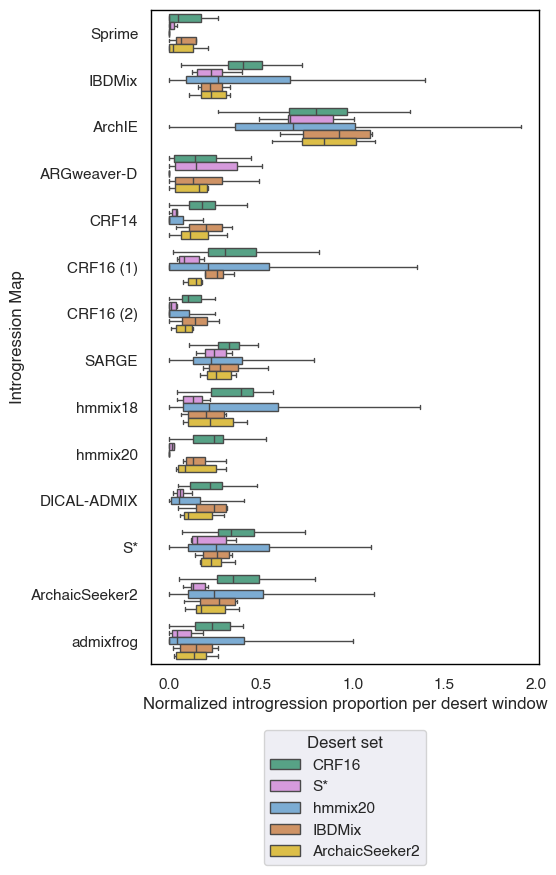

In [90]:
combined_introgression_in_deserts['fraction_introgression'] = combined_introgression_in_deserts['introgression_dir'].map(coverage_dict) / 100 # divide by 100 to convert to fraction

combined_introgression_in_deserts['fraction_introgression_overlapping_deserts_normalized_introgression'] = combined_introgression_in_deserts['fraction_introgression_overlapping_deserts'] / combined_introgression_in_deserts['fraction_introgression']

## combined
sns.set_style("white")
sns.set(font="Helvetica")
fig, ax = plt.subplots(figsize=(5,8.5))

sns.boxplot(
    data=combined_introgression_in_deserts,
    hue='level_0',
    palette=["#4AAE8A", "#DF8FE7", "#6daee2", "#e19153", "#f4cd30"],
    x='fraction_introgression_overlapping_deserts_normalized_introgression',
    y='introgression_dir',
    showfliers=False,
    orient='h',
    ax=ax
)

# put the legend out of the figure
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title='Desert set',
    bbox_to_anchor=(0.5, -0.1),
    loc='upper center',
    borderaxespad=0.,
    #ncol=len(handles)
)

# axis labels
ax.set_xlabel("Normalized introgression proportion per desert window")
ax.set_ylabel("Introgression Map")

# remove background in plot and legends
ax.set_facecolor("none")
fig.patch.set_facecolor("none")

# add borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

# removed strip plot because the outliers mess up the y axis

plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/norm_combined_desert_introgression.svg', bbox_inches='tight')

plt.show()

### Desert analysis - how much do depleted introgression regions agree across maps (reviewer comment)

for each introgression map, calculate % introgression in each window

pick a threshold of introgression (a desert is a window with <1% introgression, or try 0, but look at distribution of percent introgression per window

threshold and merge overlapping windows

then we get the set of deserts for each map

then get pairwise overlap of deserts (just like the maps)

In [4]:
# make 50 kb windows across the genome with 25 kb step size

hg19_5kb = pybedtools.BedTool().window_maker(b='/wynton/home/capra/ychen39/introgression_methods/data/human_hg19_gaps_removed_common_chr_autosomes_no_prefix.bed', 
                                             w=50000,
                                             s=25000)

In [46]:
# combine all methods into one dataframe
combined_50kb_windows_introgression = pd.DataFrame()
for method in methods_dirs:
#     !{BEDTOOLSDIR}/bedtools coverage -a {hg19_5kb.fn} -b {HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}/bedgraphs/union_merged.bg | awk -v col="{method}" '{{print $$0 "\t" col}}' > /wynton/scratch/ychen39/test/{method}_50kb_windows_introgression_coverage.bg
    df = pd.read_csv(f'/wynton/scratch/ychen39/test/{method}_50kb_windows_introgression_coverage.bg', 
            sep='\t', 
            names=['Chromosome', 'Start', 'End', 'map_regions_overlapping_windows', 'bp_overlap',
            'len_window', 'fraction_overlap', 'map'], low_memory=False)
    # subset 50 kb windows only
    windows = df[df['len_window']==50000]
    # threshold fraction overlap to be at less than or  equal to 0.1
    windows = windows[windows['fraction_overlap'] == 0]
    # merge bed regions
    windows_bed = pybedtools.BedTool.from_dataframe(windows[['Chromosome', 'Start', 'End']]).sort().merge()
    # convert back to dataframe
    windows = pd.read_csv(windows_bed.fn, sep='\t', names=['Chromosome', 'Start', 'End'])
    windows['method'] = method
    # append to combined dataframe
    combined_50kb_windows_introgression = pd.concat([combined_50kb_windows_introgression, windows], axis=0)



In [47]:
#combined_50kb_windows_introgression.to_csv(f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/combined_50kb_windows_deserts.bed', sep='\t', index=False)

# create bg file for each method
for method in methods_dirs:
    df = combined_50kb_windows_introgression[combined_50kb_windows_introgression['method']==method]
    df['score'] = 1
    df[['Chromosome', 'Start', 'End','score']].to_csv(f'/wynton/scratch/ychen39/test/{method}_combined_50kb_windows_deserts.bg', sep='\t', index=False, header=False)

In [48]:
# create boolean overlap file
boolean_overlap_deserts = tools.generate_overlap(input_files_string=f'/wynton/scratch/ychen39/test/browning_2018_updated_filtering_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/sankararaman_2014_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/skov_2020_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/durvasula_2019_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/sankararaman_2016_1_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/hubisz_2020_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/sankararaman_2016_2_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/steinruecken_2018_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/iasi_2024_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/schaefer_2021_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/vernot_2016_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/li_2024_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/skov_2018_combined_50kb_windows_deserts.bg \
/wynton/scratch/ychen39/test/yuan_2021_combined_50kb_windows_deserts.bg',
input_files_names_str='browning_2018_updated_filtering sankararaman_2014 skov_2020 durvasula_2019 sankararaman_2016_1 hubisz_2020 sankararaman_2016_2 steinruecken_2018 iasi_2024 schaefer_2021 vernot_2016 li_2024 skov_2018 yuan_2021',
output_file_path=f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/boolean_overlap_50kb_deserts.bed',
boolean=True, x_only=False)
# only information on fragment sizes, region level - no argweaver
boolean_overlap_deserts = boolean_overlap_deserts.rename(columns=rename_dict_dir)

boolean_overlap_deserts

,chrom,start,end,Sprime,CRF14,hmmix20,ArchIE,CRF16 (1),ARGweaver-D,CRF16 (2),DICAL-ADMIX,admixfrog,SARGE,S*,IBDMix,hmmix18,ArchaicSeeker2,length
0,1,10000.0,160000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,150000.0
1,1,317719.0,467719,True,True,True,True,True,True,True,True,True,True,True,True,True,True,150000.0
2,1,521368.0,696368,True,True,True,True,True,True,True,True,True,True,True,True,True,True,175000.0
3,1,696368.0,796368,True,True,True,True,True,True,True,True,True,True,True,True,True,False,100000.0
4,1,796368.0,846368,True,True,True,True,True,True,True,True,True,True,True,False,False,False,50000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48373,9,140766997.0,140891997,True,False,True,True,True,True,True,False,True,True,False,False,False,False,125000.0
48374,9,140891997.0,140941997,True,False,True,True,True,True,True,False,True,True,True,False,False,False,50000.0
48375,9,140941997.0,140991997,True,False,True,True,True,True,True,False,True,True,False,False,False,False,50000.0
48376,9,140991997.0,141016997,True,False,True,False,True,True,True,False,True,True,False,False,False,False,25000.0


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2061: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


Calculating normalized jaccard WITHOUT paired shuffled match


/wynton/home/capra/ychen39/introgression_methods/introgression_tools/introgression_tools/tools.py:2212: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


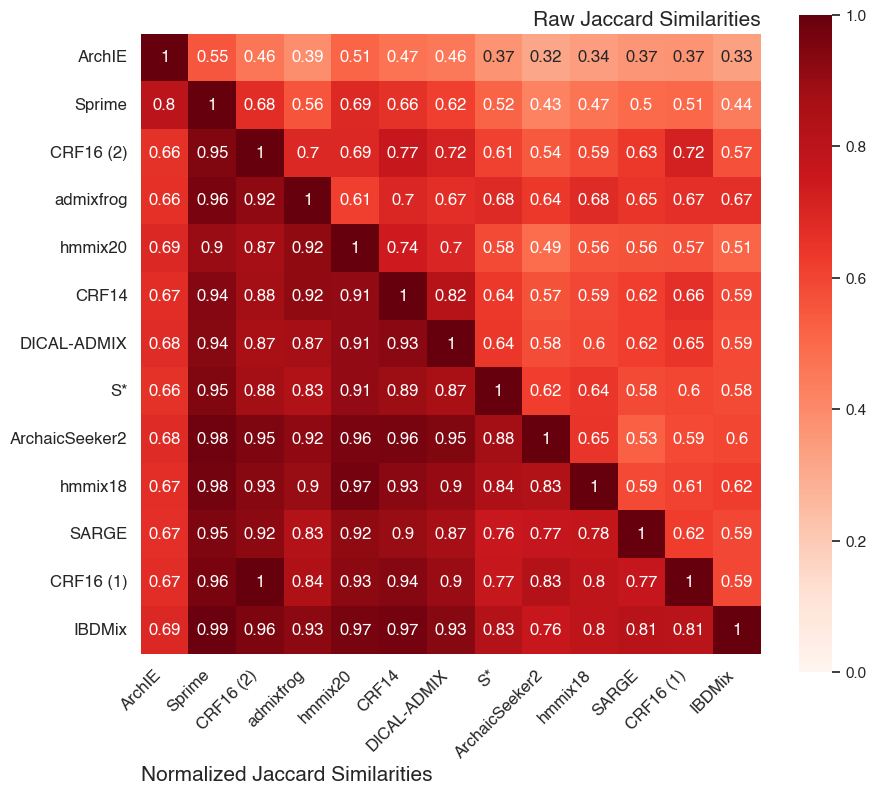

In [50]:
# jaccard
heatmap_data = tools.plot_jaccard(boolean_df=boolean_overlap_deserts,
                   # get this from the clustering order
                   categories_list=['Sprime',
                                    'hmmix20',
                                    'CRF16 (2)',
                                    'CRF14',
                                    'DICAL-ADMIX',
                                    'ArchIE',
                                    'SARGE',
                                    'CRF16 (1)',
                                    'S*',
                                    'IBDMix',
                                    'admixfrog',
                                    'ArchaicSeeker2',
                                    'hmmix18'],

                   value_column='length', 
                   type='combined',
                   leaf_order=True, 
                   font_size=12,
                   plot_size=(10,9))
plt.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/jaccard_heatmap_50kb_deserts.svg', bbox_inches='tight')

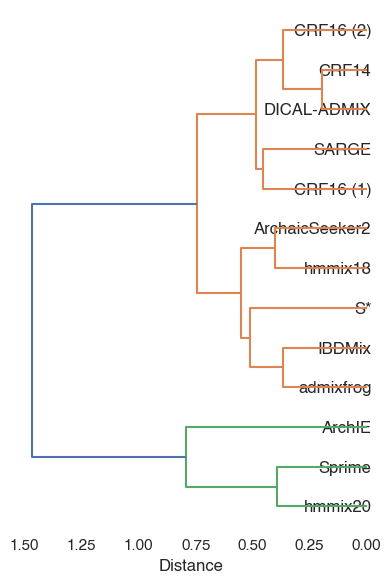

In [30]:
# dendrogram
distance_matrix = 1 - heatmap_data

# Perform hierarchical clustering using average linkage
Z = linkage(distance_matrix, method='complete') # Options: 'single', 'complete', 'average', 'ward', etc.

fig, ax = plt.subplots(figsize=(4, 6))

# plot with specified labels
dendrogram(
    Z,
    labels=heatmap_data.columns,
    orientation='right',
    leaf_rotation=90
)

plt.xlabel('Distance')

# move y axis to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# remove y ticks
ax.tick_params(axis='y', length=0)
# rotate y labels
plt.yticks(rotation=0, ha='right')

# mirror the plot
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# remove border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# keep x axis line
ax.spines['bottom'].set_visible(True)

plt.tight_layout()

# remove background and gridlines
plt.gca().patch.set_facecolor('white')
plt.grid(False)

# move y axis labels on top layer of the plot so it's not covered
for label in ax.get_yticklabels():
    label.set_zorder(30)

# Intersect each introgression map with B statistic scores from McVicker et al

To estimate the strength of background selection experienced by human genomic loci, B statistic values ranging on a scale from 1–1,000 were downloaded at http://www.phrap.org/software_dir/mcvicker_dir/bkgd.tar.gz. We quantized these values by rounding them down to the nearest multiple of 50 B statistic units, then lifted them over from hg18 coordinates to hg19 coordinates. Each SNP in the SGDP data was assigned the B statistic value of the closest site annotated by McVicker et al.28.

The phrap link does not work, but the data is provided in https://github.com/kelleyharris/hominin-enhancers/tree/master/bkgd.

Let's use this data (hg19_Bstats_bin50_chrom*.bed, uploaded to data/background_selection_mcvicker_harris/)

`scp -r hg19_Bstats_bin50_chrom*.bed ychen39@dt2.wynton.ucsf.edu:/wynton/home/capra/ychen39/introgression_methods/data/background_selection_mcvicker_harris`

In [25]:
%%bash 

HOMEDIR='/wynton/home/capra/ychen39/'

output=${HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/merged_bstats_hg19.bed

for file in ${HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/hg19*.bed; do
    # get chrom and add to the output file as the first column, then the rest of the data
    chrom_name=$(echo "$file" | sed -n 's/.*hg19_Bstats_bin50_chrom\(.*\)\.bed/\1/p')
    echo $chrom_name

    awk -v chrom="$chrom_name" '{print chrom, $0}' OFS="\t" "$file" >> "$output"
done

10
11
12
13
14
15
16
17
18
19
1
20
21
22
2
3
4
5
6
7
8
9


In [ ]:
# intersect each introgression map with bedtools.
# read in b statistic information_
b_stat = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/merged_bstats_hg19.bed', sep='\t', names=['chrom', 'start', 'end', 'b_stat'])
b_stat_bed = pybedtools.BedTool.from_dataframe(b_stat)
b_stat_bed = b_stat_bed.sort()

# empty dict to hold average scores
intro_b_stat_average = {}
non_intro_b_stat_average = {}
final_b_stat_raw = {}

# set methods directories
# Use bedtools complement to get the non-introgressed regions for each method
for method in methods_dirs:
    if 'sankararaman' in method:
        method_name = method.replace('_', '', 1)
    else:
        method_name = method.replace('_', '')
    # specify method dir
    method_dir = f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}'
    print(method_dir)
    
    # read in introgression map
    introgression_map = pd.read_csv(f'{method_dir}/bedgraphs/union_merged_highest_score.bg', sep='\s+', usecols=[0, 1, 2])
    non_introgressed_map = pd.read_csv(f'{method_dir}/complement.bg', sep='\s+', usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
    # remove chr prefix
    non_introgressed_map['chrom'] = non_introgressed_map['chrom'].str.replace('chr', '')
    
    # convert to BedTool object for pybedtools
    map_bed = pybedtools.BedTool.from_dataframe(introgression_map)
    non_intro_map_bed = pybedtools.BedTool.from_dataframe(non_introgressed_map)
    map_bed = map_bed.sort()
    non_intro_map_bed = non_intro_map_bed.sort()

    # intersect the two objects
    map_bstat_intersect = b_stat_bed.intersect(map_bed, wb=True)
    non_intro_map_bstat_intersect = b_stat_bed.intersect(non_intro_map_bed, wb=True)

    # drop extra columns (keep the scores and their positions that fall in map regions)
    intro_intersection = map_bstat_intersect.to_dataframe().drop(['score', 'strand', 'thickStart'], axis=1)
    non_intro_intersection = non_intro_map_bstat_intersect.to_dataframe().drop(['score', 'strand', 'thickStart'], axis=1)
    
    intro_intersection['length'] = intro_intersection['end'] - intro_intersection['start']
    non_intro_intersection['length'] = non_intro_intersection['end'] - non_intro_intersection['start']
    
    intro_score = np.sum(intro_intersection['length'] * intro_intersection['name']) / intro_intersection['length'].sum()
    non_intro_score = np.sum(non_intro_intersection['length'] * non_intro_intersection['name']) / non_intro_intersection['length'].sum()
    
    intro_b_stat_average[f'{method}'] = intro_score
    non_intro_b_stat_average[f'{method}'] = non_intro_score

/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/chen_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/yuan_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/durvasula_2019
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/steinruecken_2018
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/skov_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/schaefer_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/hubisz_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/browning_2018
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/vernot_2016
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankararaman_2014
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankarara

## Try with 500 bp windows

In [82]:
# Make bed file with 500 bp bins across the hg19 genome

# empty dict to hold scores
intro_b_stat = {}
non_intro_b_stat = {}
intro_b_stat_smaller_than_window = {}
non_intro_b_stat_smaller_than_window = {}

# parameters: window size
window = 500

# read in b statistic information_
b_stat = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/merged_bstats_hg19.bed', sep='\t', names=['chrom', 'start', 'end', 'b_stat'])
b_stat_bed = pybedtools.BedTool.from_dataframe(b_stat)
b_stat_bed = b_stat_bed.sort()

# set methods directories
# Use bedtools complement to get the non-introgressed regions for each method
for method in methods_dirs:
    if 'sankararaman' in method:
        method_name = method.replace('_', '', 1)
    else:
        method_name = method.replace('_', '')
    # specify method dir
    method_dir = f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}'
    print(method_dir)
    
    # read in introgression map
    introgression_map = pd.read_csv(f'{method_dir}/bedgraphs/union_merged_highest_score.bg', sep='\s+', usecols=[0, 1, 2])
    
    # convert to BedTool object for pybedtools
    map_bed = pybedtools.BedTool.from_dataframe(introgression_map)
    map_bed = map_bed.sort()

    # make genome-wide window file to assign windows to the introgression map
    hg19_5kb = pybedtools.BedTool().window_maker(b='/wynton/home/capra/ychen39/introgression_methods/data/human_hg19_gaps_removed_common_chr.bed', w=500)
    # remove chr prefix
    hg19_5kb_df = hg19_5kb.to_dataframe()
    hg19_5kb_df['chrom'] = hg19_5kb_df['chrom'].str.replace('^chr', '', regex=True)
    # convert back to bedtools
    hg19_5kb = pybedtools.BedTool.from_dataframe(hg19_5kb_df)

    # intersect B statistic scores, computing the average for each 500 window entry
    map_windows_intersect = hg19_5kb.intersect(map_bed, wao=True) #u: write original entry A (b stats if at least 1 base pair overlaps)

    # Get introgressed (at least 1 base pair of the window is introgressed) and non-introgressed (no windows fall in non-introgressed regions)
    map_windows_intersect_df = map_windows_intersect.to_dataframe(low_memory=False)
    introgressed = pybedtools.BedTool.from_dataframe(map_windows_intersect_df[map_windows_intersect_df['score'] > 0][['chrom', 'start', 'end']]) # convert to bedtools object
    non_introgressed = pybedtools.BedTool.from_dataframe(map_windows_intersect_df[map_windows_intersect_df['score'] == -1][['chrom', 'start', 'end']])

    # for introgressed and non introgressed windows, compute average B statistic for each 5kb window
    # remove intersections that are less than 5 kb
    # introgrssed
    intro_b_stat_intersect = introgressed.intersect(b_stat_bed, wo=True)
    intro_b_stat_intersect = intro_b_stat_intersect.to_dataframe()
    intro_b_stat_intersect = intro_b_stat_intersect.drop_duplicates()
    intro_b_stat[method] = intro_b_stat_intersect['thickStart'][intro_b_stat_intersect['thickEnd'] == 500]
    # for regions smaller than the window, add the sum of their scores*length to a separate dict
    # thickStart is the score, thickEnd is the size of the intersection
    intro_b_stat_smaller_than_window[method] = np.sum(intro_b_stat_intersect['thickStart']*intro_b_stat_intersect['thickEnd'][intro_b_stat_intersect['thickEnd'] <= 500])

    # nonintrogressed
    non_intro_b_stat_intersect = non_introgressed.intersect(b_stat_bed, wo=True)
    non_intro_b_stat_intersect = non_intro_b_stat_intersect.to_dataframe()
    non_intro_b_stat_intersect = non_intro_b_stat_intersect.drop_duplicates()
    non_intro_b_stat[method] = non_intro_b_stat_intersect['thickStart'][non_intro_b_stat_intersect['thickEnd'] == 500]
    non_intro_b_stat_smaller_than_window[method] = np.sum(non_intro_b_stat_intersect['thickStart']*non_intro_b_stat_intersect['thickEnd'][non_intro_b_stat_intersect['thickEnd'] <= 5000])
    

/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/yuan_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/durvasula_2019
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/steinruecken_2018
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/skov_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/schaefer_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/hubisz_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/vernot_2016
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankararaman_2014
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankararaman_2016_1
/wynton/home/capra/ychen39//introgression_methods/cleaned/i

In [85]:
# try a boxplot
# empty dict to hold scores
intro_b_stat = {}
non_intro_b_stat = {}
intro_b_stat_smaller_than_window = {}
non_intro_b_stat_smaller_than_window = {}

# parameters: window size
window = 500

# read in b statistic information_
b_stat = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/background_selection_mcvicker_harris/merged_bstats_hg19.bed', sep='\t', names=['chrom', 'start', 'end', 'b_stat'])
b_stat_bed = pybedtools.BedTool.from_dataframe(b_stat)
b_stat_bed = b_stat_bed.sort()

# set methods directories
methods_dirs = ['yuan_2021', 'durvasula_2019', 'steinruecken_2018', 'skov_2020', 'schaefer_2021', 
                'hubisz_2020', 'browning_2018_updated_filtering', 'vernot_2016', 'sankararaman_2014', 'sankararaman_2016_1', 'sankararaman_2016_2',
                'li_2024', 'iasi_2024', 'skov_2018'] # added after reviews
# Use bedtools complement to get the non-introgressed regions for each method
for method in methods_dirs:
    if 'sankararaman' in method:
        method_name = method.replace('_', '', 1)
    else:
        method_name = method.replace('_', '')
    # specify method dir
    method_dir = f'{HOMEDIR}/introgression_methods/cleaned/introgression_tools/{method}'
    print(method_dir)
    
    # read in introgression map
    introgression_map = pd.read_csv(f'{method_dir}/bedgraphs/union_merged_highest_score.bg', sep='\s+', usecols=[0, 1, 2])
    
    # convert to BedTool object for pybedtools
    map_bed = pybedtools.BedTool.from_dataframe(introgression_map)
    map_bed = map_bed.sort()

    # make genome-wide window file to assign windows to the introgression map
    hg19_5kb = pybedtools.BedTool().window_maker(b='/wynton/home/capra/ychen39/introgression_methods/data/human_hg19_gaps_removed_common_chr.bed', w=window)
    # remove chr prefix
    hg19_5kb_df = hg19_5kb.to_dataframe()
    hg19_5kb_df['chrom'] = hg19_5kb_df['chrom'].str.replace('^chr', '', regex=True)
    # convert back to bedtools
    hg19_5kb = pybedtools.BedTool.from_dataframe(hg19_5kb_df)

    # intersect B statistic scores, computing the average for each window entry
    map_windows_intersect = hg19_5kb.intersect(map_bed, wao=True) #u: write original entry A (b stats if at least 1 base pair overlaps)

    # Get introgressed (at least 1 base pair of the window is introgressed) and non-introgressed (no windows fall in non-introgressed regions)
    map_windows_intersect_df = map_windows_intersect.to_dataframe(low_memory=False)
    introgressed = pybedtools.BedTool.from_dataframe(map_windows_intersect_df[map_windows_intersect_df['score'] > 0][['chrom', 'start', 'end']]) # convert to bedtools object
    non_introgressed = pybedtools.BedTool.from_dataframe(map_windows_intersect_df[map_windows_intersect_df['score'] == -1][['chrom', 'start', 'end']])

    # for introgressed and non introgressed windows, compute average B statistic for each 5kb window
    # remove intersections that are less than 5 kb
    # introgrssed
    intro_b_stat_intersect = introgressed.intersect(b_stat_bed, wo=True)
    intro_b_stat_intersect = intro_b_stat_intersect.to_dataframe()
    intro_b_stat_intersect = intro_b_stat_intersect.drop_duplicates()
    intro_b_stat[method] = intro_b_stat_intersect['thickStart'][intro_b_stat_intersect['thickEnd'] == window]
    # for regions smaller than the window, add the sum of their scores*length to a separate dict
    # thickStart is the score, thickEnd is the size of the intersection
    intro_b_stat_smaller_than_window[method] = np.sum(intro_b_stat_intersect['thickStart']*intro_b_stat_intersect['thickEnd'][intro_b_stat_intersect['thickEnd'] <= window])

    # nonintrogressed
    non_intro_b_stat_intersect = non_introgressed.intersect(b_stat_bed, wo=True)
    non_intro_b_stat_intersect = non_intro_b_stat_intersect.to_dataframe()
    non_intro_b_stat_intersect = non_intro_b_stat_intersect.drop_duplicates()
    non_intro_b_stat[method] = non_intro_b_stat_intersect['thickStart'][non_intro_b_stat_intersect['thickEnd'] == window]
    non_intro_b_stat_smaller_than_window[method] = np.sum(non_intro_b_stat_intersect['thickStart']*non_intro_b_stat_intersect['thickEnd'][non_intro_b_stat_intersect['thickEnd'] <= window])

#PLOT: convert dict to datafrmae
non_intro_b_stat_df = pd.DataFrame(non_intro_b_stat)
intro_b_stat_df = pd.DataFrame(intro_b_stat)

# rename maps
df1_melted = non_intro_b_stat_df.melt(var_name='Feature', value_name='Value')
df1_melted['Source'] = 'Non-Introgressed'

df2_melted = intro_b_stat_df.melt(var_name='Feature', value_name='Value')
df2_melted['Source'] = 'Introgressed'

# Combine both into one DataFrame, remove NAs (NA means there weren't enough windows to match the other maps)
combined = pd.concat([df1_melted, df2_melted], ignore_index=True).dropna(axis=0)

# rename maps
combined['Feature'] = combined['Feature'].map(rename_dict_dir)

/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/yuan_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/durvasula_2019
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/steinruecken_2018
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/skov_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/schaefer_2021
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/hubisz_2020
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/browning_2018_updated_filtering
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/vernot_2016
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankararaman_2014
/wynton/home/capra/ychen39//introgression_methods/cleaned/introgression_tools/sankararaman_2016_1
/wynton/home/capra/ychen39//introgression_methods/cleaned/i

In [86]:
# Save to a pickle file
with open(f'{HOMEDIR}/introgression_methods/data/bstat_by_map_500bp.pkl', 'wb') as f:
    pickle.dump(combined, f)

In [92]:
with open(f'{HOMEDIR}/introgression_methods/data/bstat_by_map_500bp.pkl', 'rb') as f:
    combined = pickle.load(f)

In [68]:
combined

,Feature,Value,Source
0,IBDMix,850.0,Non-Introgressed
1,IBDMix,850.0,Non-Introgressed
2,IBDMix,850.0,Non-Introgressed
3,IBDMix,850.0,Non-Introgressed
4,IBDMix,850.0,Non-Introgressed
...,...,...,...
96274731,Sankararaman16 (2),900.0,Introgressed
96274732,Sankararaman16 (2),900.0,Introgressed
96274734,Sankararaman16 (2),900.0,Introgressed
96274735,Sankararaman16 (2),900.0,Introgressed


### Bootstrap values: see bootstrap_bstat_dist.py

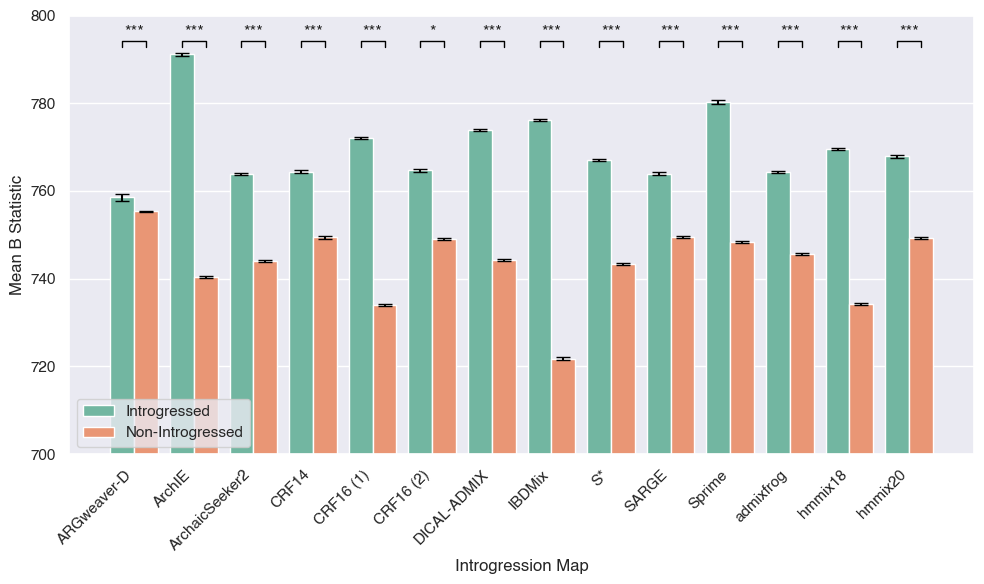

In [93]:
# read in output file
ci_df = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/bstat_by_map_500bp_bootstrapped.tsv', sep='\t', names=['Feature', 'Source', 'Mean', 'CI_lower', 'CI_upper'])

# plot results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ci_df,
    x="Feature",
    y="Mean",
    hue="Source",
    capsize=0.1,
    palette="Set2"
)

# add error bars
for i, row in ci_df.iterrows():
    x = list(ci_df["Feature"].unique()).index(row["Feature"])
    offset = -0.2 if row["Source"] == ci_df["Source"].unique()[0] else 0.2
    plt.errorbar(
        x + offset,
        row["Mean"],
        yerr=[[row["Mean"] - row["CI_lower"]], [row["CI_upper"] - row["Mean"]]],
        fmt='none',
        c='black',
        capsize=5
    )

# significance asterisk function
def get_asterisks(p):
    if p <= 0.001:
        return '***'
    elif p <= 0.01:
        return '**'
    elif p <= 0.05:
        return '*'
    else:
        return 'ns'

# rank-sum test per feature
features = combined['Feature'].unique()
y_max = ci_df['CI_upper'].max()
y_min = ci_df['CI_upper'].min()
y_range = y_max - y_min
y_offset = 0.02 * y_range  # vertical space for line and asterisk

# save p values
pval_results = pd.DataFrame(columns=["map", "statistic", "p_value"])

for i, feature in enumerate(features):
    group1 = combined[(combined['Feature'] == feature) & (combined['Source'] == 'Introgressed')]['Value']
    group2 = combined[(combined['Feature'] == feature) & (combined['Source'] == 'Non-Introgressed')]['Value']

    if len(group1) > 0 and len(group2) > 0:
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
        # add to df
        pval_results.loc[len(pval_results)] = [feature, stat, p]
        asterisk = get_asterisks(p)
        
        # bar positions
        x1 = i - 0.2
        x2 = i + 0.2
        y = y_max + y_offset 

        # Draw line betwene bars
        plt.plot([x1, x1, x2, x2], [y, y + y_offset, y + y_offset, y], color='black', linewidth=1)

        # add asterisk above line
        plt.text((x1 + x2) / 2, y + y_offset + 0.005 * y_range, asterisk,
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(700, 800)
plt.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Introgression Map")
plt.ylabel("Mean B Statistic")
plt.tight_layout()
pyplot.savefig(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/bstatscores/bstatscores_bootstrap.svg', bbox_inches='tight')
plt.show()



In [23]:
pval_results['p_value'] = pval_results['p_value'].apply(lambda x: f"{x:.2e}") # convert to scientific notation.
pval_results.to_csv(f'{HOMEDIR}/introgression_methods/figures/introgression_tools/bstatscores/pval_bstat.tsv', sep='\t')

In [102]:
ci_df_copy

Feature                          Mean                   \
Source            Introgressed Non-Introgressed Introgressed Non-Introgressed   
Feature                                                                         
ARGweaver-D        ARGweaver-D      ARGweaver-D   758.561182       755.343756   
ArchIE                  ArchIE           ArchIE   791.173445       740.334761   
ArchaicSeeker2  ArchaicSeeker2   ArchaicSeeker2   763.820723       744.100064   
CRF14                    CRF14            CRF14   764.416326       749.410133   
CRF16 (1)            CRF16 (1)        CRF16 (1)   772.068983       734.044718   
CRF16 (2)            CRF16 (2)        CRF16 (2)   764.694747       749.073810   
DICAL-ADMIX        DICAL-ADMIX      DICAL-ADMIX   773.831374       744.166446   
IBDMix                  IBDMix           IBDMix   776.119175       721.735912   
S*                          S*               S*   767.005612       743.436511   
SARGE                    SARGE            SARGE   763.957061       749.551524   
Sprime                  Sprime           Sprime   780.278035       748.344829   
admixfrog            admixfrog        admixfrog   764.375496       745.677869   
hmmix18                hmmix18          hmmix18   769.669826       734.252577   
hmmix20                hmmix20          hmmix20   767.932200       749.238738   

                   CI_lower                      CI_upper                   \
Source         Introgressed Non-Introgressed Introgressed Non-Introgressed   
Feature                                                                      
ARGweaver-D      757.744859       755.166930   759.299722       755.533633   
ArchIE           790.874586       740.107142   791.465610       740.561767   
ArchaicSeeker2   763.590807       743.793821   764.054218       744.373547   
CRF14            764.136095       749.143350   764.705935       749.659168   
CRF16 (1)        771.824232       733.750477   772.301072       734.353356   
CRF16 (2)        764.425810       748.840000   764.963385       749.319859   
DICAL-ADMIX      773.574982       743.939748   774.097358       744.417379   
IBDMix           775.880534       721.423192   776.336737       722.081293   
S*               766.776975       743.145898   767.245023       743.701247   
SARGE            763.675498       749.304022   764.224218       749.783840   
Sprime           779.922352       748.112390   780.631316       748.561382   
admixfrog        764.145908       745.397227   764.628124       745.955844   
hmmix18          769.452142       733.936410   769.877003       734.547515   
hmmix20          767.622394       749.009978   768.244974       749.472738   

                 difference                         ratio                   
Source         Introgressed Non-Introgressed Introgressed Non-Introgressed  
Feature                                                                     
ARGweaver-D       -3.217427        -3.217427     0.995759         0.995759  
ArchIE            50.838684        50.838684     1.068670         1.068670  
ArchaicSeeker2   -19.720659       -19.720659     1.026503         1.026503  
CRF14            -15.006193       -15.006193     0.980369         0.980369  
CRF16 (1)         38.024265        38.024265     1.051801         1.051801  
CRF16 (2)        -15.620937       -15.620937     0.979572         0.979572  
DICAL-ADMIX       29.664928        29.664928     1.039863         1.039863  
IBDMix            54.383263        54.383263     1.075351         1.075351  
S*                23.569101        23.569101     1.031703         1.031703  
SARGE            -14.405536       -14.405536     0.981144         0.981144  
Sprime            31.933206        31.933206     1.042672         1.042672  
admixfrog        -18.697627       -18.697627     0.975539         0.975539  
hmmix18          -35.417249       -35.417249     1.048236         1.048236  
hmmix20           18.693463        18.693463     1.024950         1.024950

In [105]:
# for each feature, compute ratio between introgressed and non-introgressed
# groupby Feature, then order by Introgressed / Non-Introgressed
# then compute ratio
ci_df = pd.read_csv(f'{HOMEDIR}/introgression_methods/data/bstat_by_map_500bp_bootstrapped.tsv', sep='\t', names=['Feature', 'Source', 'Mean', 'CI_lower', 'CI_upper'])


ci_df_copy = ci_df.groupby('Feature').apply(lambda x: x.set_index('Source')).unstack()

ci_df_copy['ratio'] = ci_df_copy[('Mean', 'Introgressed')] / ci_df_copy[('Mean', 'Non-Introgressed')]

# sort by ratio
ci_df_copy = ci_df_copy.sort_values(by='ratio', ascending=False)
ci_df_copy


Feature                          Mean                   \
Source            Introgressed Non-Introgressed Introgressed Non-Introgressed   
Feature                                                                         
IBDMix                  IBDMix           IBDMix   776.119175       721.735912   
ArchIE                  ArchIE           ArchIE   791.173445       740.334761   
CRF16 (1)            CRF16 (1)        CRF16 (1)   772.068983       734.044718   
hmmix18                hmmix18          hmmix18   769.669826       734.252577   
Sprime                  Sprime           Sprime   780.278035       748.344829   
DICAL-ADMIX        DICAL-ADMIX      DICAL-ADMIX   773.831374       744.166446   
S*                          S*               S*   767.005612       743.436511   
ArchaicSeeker2  ArchaicSeeker2   ArchaicSeeker2   763.820723       744.100064   
admixfrog            admixfrog        admixfrog   764.375496       745.677869   
hmmix20                hmmix20          hmmix20   767.932200       749.238738   
CRF16 (2)            CRF16 (2)        CRF16 (2)   764.694747       749.073810   
CRF14                    CRF14            CRF14   764.416326       749.410133   
SARGE                    SARGE            SARGE   763.957061       749.551524   
ARGweaver-D        ARGweaver-D      ARGweaver-D   758.561182       755.343756   

                   CI_lower                      CI_upper                   \
Source         Introgressed Non-Introgressed Introgressed Non-Introgressed   
Feature                                                                      
IBDMix           775.880534       721.423192   776.336737       722.081293   
ArchIE           790.874586       740.107142   791.465610       740.561767   
CRF16 (1)        771.824232       733.750477   772.301072       734.353356   
hmmix18          769.452142       733.936410   769.877003       734.547515   
Sprime           779.922352       748.112390   780.631316       748.561382   
DICAL-ADMIX      773.574982       743.939748   774.097358       744.417379   
S*               766.776975       743.145898   767.245023       743.701247   
ArchaicSeeker2   763.590807       743.793821   764.054218       744.373547   
admixfrog        764.145908       745.397227   764.628124       745.955844   
hmmix20          767.622394       749.009978   768.244974       749.472738   
CRF16 (2)        764.425810       748.840000   764.963385       749.319859   
CRF14            764.136095       749.143350   764.705935       749.659168   
SARGE            763.675498       749.304022   764.224218       749.783840   
ARGweaver-D      757.744859       755.166930   759.299722       755.533633   

                   ratio  
Source                    
Feature                   
IBDMix          1.075351  
ArchIE          1.068670  
CRF16 (1)       1.051801  
hmmix18         1.048236  
Sprime          1.042672  
DICAL-ADMIX     1.039863  
S*              1.031703  
ArchaicSeeker2  1.026503  
admixfrog       1.025075  
hmmix20         1.024950  
CRF16 (2)       1.020854  
CRF14           1.020024  
SARGE           1.019219  
ARGweaver-D     1.004260